In [1]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from scipy import stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from matplotlib.legend_handler import HandlerTuple
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
#import rasterio
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas


In [2]:
k = 15 # Pixels à retirer aux bords du domaine (éviter effet de bord)

In [3]:
# MAR topography (pas la même correction que Xavier applique, car non nécessaire ici)

GridPath='/home/amoryc/'
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM) # ds pour DataSet
#print(ds_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

In [4]:
#### Récupération des indices de la grille pour afficher des variables uniquement sur cette grille ####
dist = np.sqrt((ds_lat - merap_lat)**2 + (ds_lon - merap_lon)**2) # Calcul des distances entre les centres des grilles et coordonnées du Mera Peak
 
# index 1D du minimum
idx_1d = dist.argmin().item() # Recherche de la distance minimale avec argmin

# conversion en indices 2D (Y,X) 
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 12
Indice X : 55
Latitude trouvée : 27.69999885559082
Longitude trouvée : 86.89999389648438


In [5]:
ice_level = 0 # Seuil à partir duquel on considère qu'on observe de la glace
ds_ICE_mask = (ds_ICE >= ice_level)
ds_ICE_mask = ds_ICE_mask.rename({'y': 'Y', 'x': 'X'})

# Carte de la région du Népal

In [6]:
clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tous les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

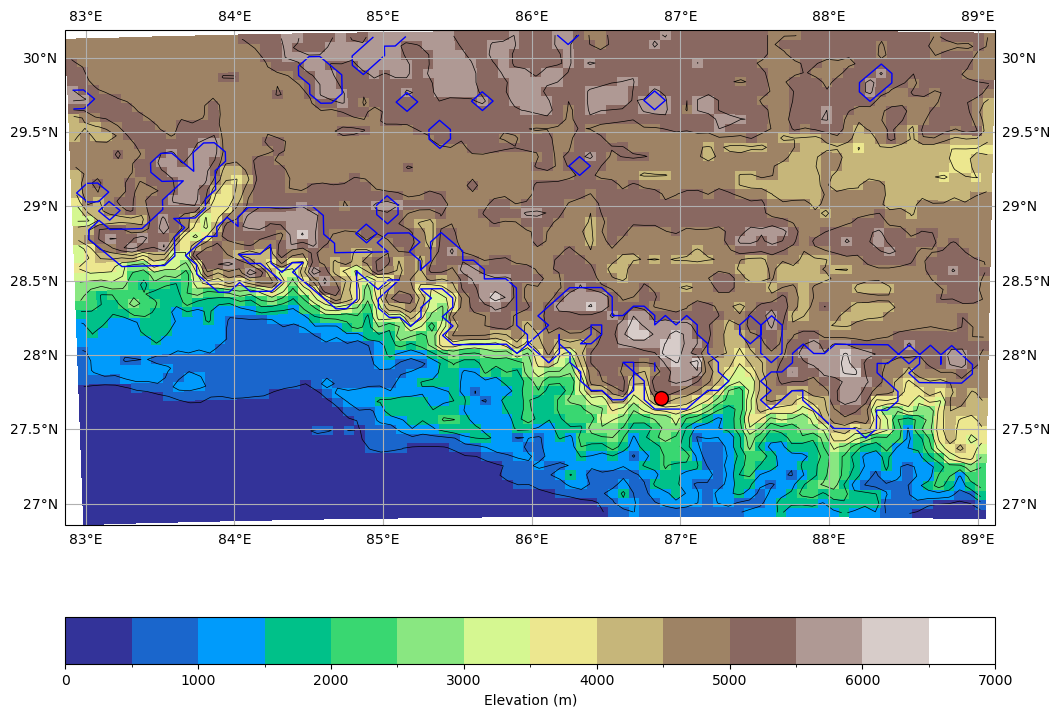

In [7]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Topographie ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                   cmap=cmap, norm=norm, # Affiche la couleur de la topographie
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Elevation (m)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
#plt.savefig("Nepal_domain.png")
plt.show()

# Carte de la région du Mera 

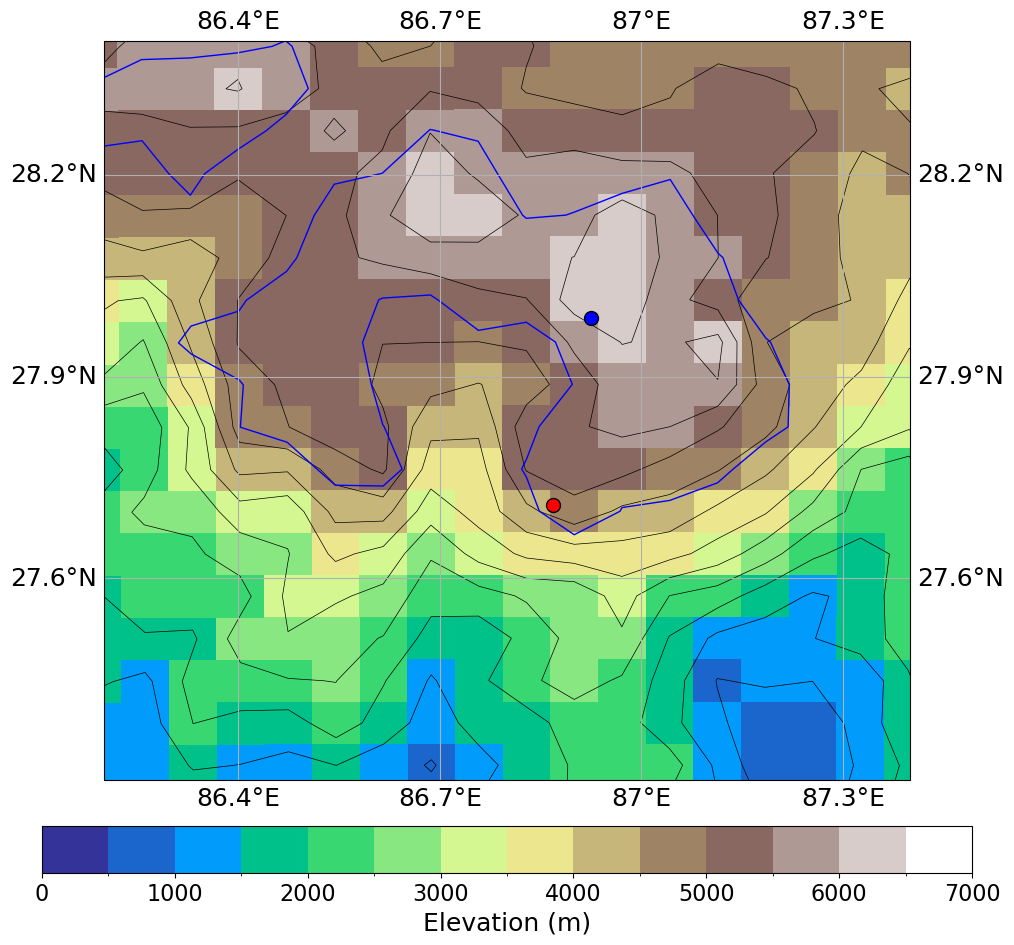

In [8]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[30], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Everest coord ####
ax.plot(everest_lon, everest_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='b',
        transform=ccrs.PlateCarree())

#### Topographie ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                   cmap=cmap, norm=norm, # Affiche la couleur de la topographie
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.4, 27.3, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

gl = ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
gl.xlabel_style = {'size': 18}  # taille longitude
gl.ylabel_style = {'size': 18}  # taille latitude
gl.xlocator = mticker.MaxNLocator(4)  # max 4 ticks
gl.ylocator = mticker.MaxNLocator(4)
cbar = plt.colorbar(im, orientation="horizontal", pad=0.05, label="Elevation (m)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
cbar.set_label("Elevation (m)", fontsize=18)  
cbar.ax.tick_params(labelsize=16)            
plt.savefig("khumbu_map_ice30.png")
plt.show()

# Ice Map

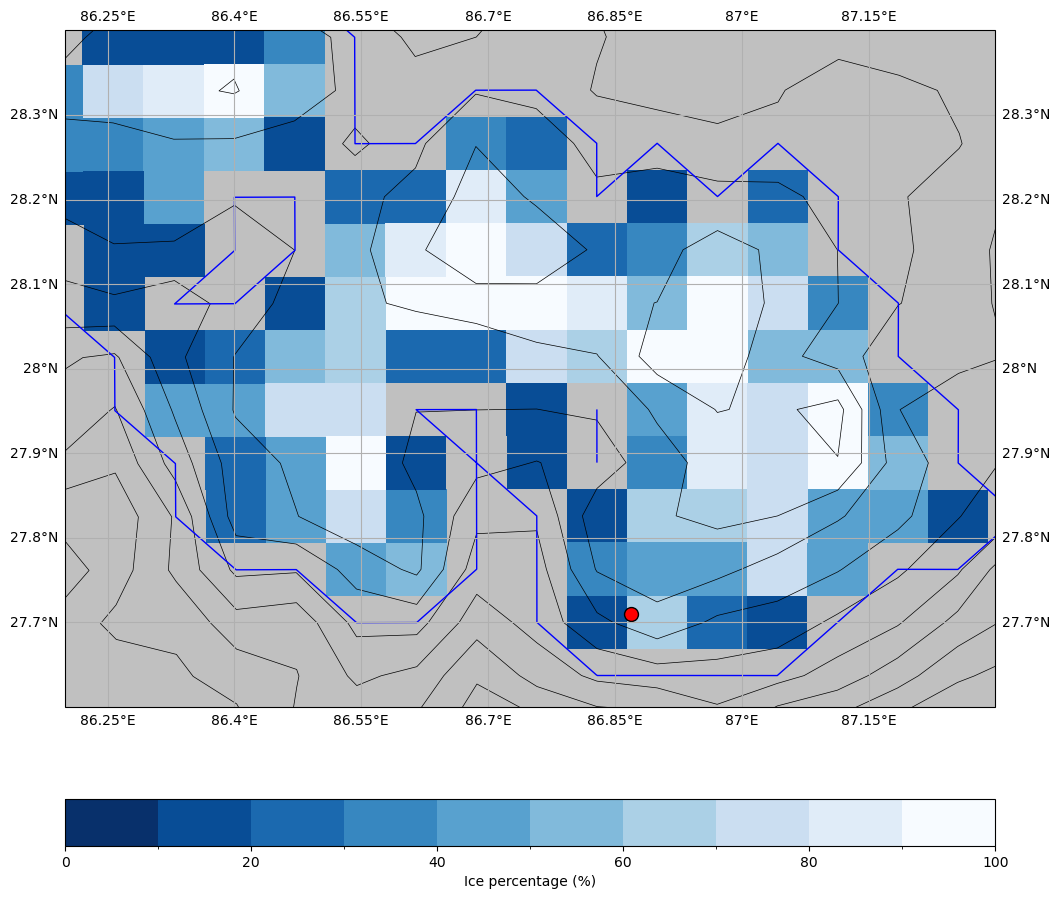

In [9]:
clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

ax.set_facecolor('silver')
ICE_zero = np.ma.masked_where(ds_ICE ==0, ds_ICE) # Créer un mask sur les valeurs de % de glace nul
#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ICE_zero,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([85, 88, 27.6, 29], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
#plt.savefig("Khumbu_icelevel.png")
plt.show()

### Identification des indices X et Y de la grille correspondant au glacier Mera 
#### C'est à dire le point de grille le plus proche des coordonnées réelles

# Loading and sorting OBS data glacioclim

In [10]:
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2

##### Définitions des variables accumulations et d'ablation pour le Mera(m) et Naulek(n) (Naulek n'a pas de balise en accu)
##### Mera Naulek #####
SMB_accu_m, SH_accu_m, reg_accu_m = [], [], []
SMB_ablation_m, SH_ablation_m, reg_ablation_m = [], [], []
SMB_ablation_n, SH_ablation_n, reg_ablation_n = [], [], []

date_obs, date_ref = [], [] # Stock les intervalles entre les mesures j et j-1 pour chaque année

##### Changri #####
SMB_chan, SH_chan, reg_chan = [], [], []
date_obs_chan, date_ref_chan = [], []

for j in range(nyy):
    
###### MERA/NAULEK OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne

    glacier_col = df.columns[df.apply(lambda col: col.astype(str).str.contains("branch", na=False)).any()][0]

    
    ####### Recherche de la période moyenne (pondéré) ########
    df_clear = df.dropna(subset=["Date_start", "Date_end"]).reset_index(drop=True) # Suppression des lignes sans dates completes

    # Construction des variables
    t_start = pd.to_datetime(df_clear["Date_start"], format="%d/%m/%Y", errors="coerce") # Conversion en datetime 
    t_end   = pd.to_datetime(df_clear["Date_end"], format="%d/%m/%Y", errors="coerce")
    duration = (t_end - t_start).dt.total_seconds() # Durée de chaque période Δt_i (transformé en seconde)
    t_mid = t_start + (t_end - t_start) / 2 # Milieu de chaque intervalle

    # Moyenne pondérée du centre temporel
    t_mid_sec = t_mid.astype("int64") / 1e9 # Conversion dates en secondes
    weighted_mid = np.sum(t_mid_sec * duration) / np.sum(duration) 
    weighted_mid = pd.to_datetime(weighted_mid, unit="s") # Reconversion en date
    weighted_duration = np.sum(duration * duration) / np.sum(duration) # Δt = sum(w_i * Δt_i) / sum(w_i). On fait la moyenne pondérée par elle même
    weighted_duration = pd.to_timedelta(weighted_duration, unit="s") # Reconversion en date

    date_ref.append((weighted_mid - weighted_duration / 2).replace(hour=12)) # Reconstruction de la période centrée sur le temps moyen t_ref = t_mid - Δt/2
    date_obs.append((weighted_mid + weighted_duration / 2).replace(hour=12))

    
    ######## Récupération MB ########
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    df_accu_m   = df_accu[df_accu[glacier_col] == "Mera branch"]
    df_ablation_m   = df_ablation[df_ablation[glacier_col] == "Mera branch"]
    df_ablation_n = df_ablation[df_ablation[glacier_col] == "Naulek branch"]
    
    ###### Accumulation ######
    x_accu_m = df_accu_m[MB]
    y_accu_m = df_accu_m["Altitude_end"]
    
    if len(x_accu_m) >= 2:
        res_accu_m = stats.linregress(x_accu_m, y_accu_m)

    SMB_accu_m.append(x_accu_m)
    SH_accu_m.append(y_accu_m)
    reg_accu_m.append(res_accu_m)

    ##### Ablation ######
    x_ablation_m = df_ablation_m[MB]
    y_ablation_m = df_ablation_m["Altitude_end"]

    x_ablation_n = df_ablation_n[MB]
    y_ablation_n = df_ablation_n["Altitude_end"]

    if len(x_ablation_m) >= 2:
        res_ablation_m = stats.linregress(x_ablation_m, y_ablation_m)

    if len(x_ablation_n) >= 2:
        res_ablation_n = stats.linregress(x_ablation_n, y_ablation_n)
        
    SMB_ablation_m.append(x_ablation_m)
    SH_ablation_m.append(y_ablation_m)
    reg_ablation_m.append(res_ablation_m)

    SMB_ablation_n.append(x_ablation_n)
    SH_ablation_n.append(y_ablation_n)
    reg_ablation_n.append(res_ablation_n)


    

    ###### CHANGRI NUP OBS_data loading and sorting ######    
    file_changri = '/home/turpinli/Changri_data/AnnualMB_West_Changri_Nup_'+yy[j]+'_'+yy[j+1]+'.xlsx'

    if os.path.exists(file_changri): # Selectionne que les fichiers où les années sont présentes
        dfc = pd.read_excel(file_changri, header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    
        ####### Recherche de la période moyenne (pondéré) ########
        dfc_clear = dfc.dropna(subset=["Date_start", "Date_end"]).reset_index(drop=True) # Suppression des lignes sans dates completes

        # Construction des variables
        t_start = pd.to_datetime(dfc_clear["Date_start"], format="%d/%m/%Y", errors="coerce") # Conversion en datetime 
        t_end   = pd.to_datetime(dfc_clear["Date_end"], format="%d/%m/%Y", errors="coerce")
        duration = (t_end - t_start).dt.total_seconds() # Durée de chaque période Δt_i (transformé en seconde)
        t_mid = t_start + (t_end - t_start) / 2 # Milieu de chaque intervalle

        # Moyenne pondérée du centre temporel
        t_mid_sec = t_mid.astype("int64") / 1e9 # Conversion dates en secondes
        weighted_mid = np.sum(t_mid_sec * duration) / np.sum(duration) 
        weighted_mid = pd.to_datetime(weighted_mid, unit="s") # Reconversion en date
        weighted_duration = np.sum(duration * duration) / np.sum(duration) # Δt = sum(w_i * Δt_i) / sum(w_i). On fait la moyenne pondérée par elle même
        weighted_duration = pd.to_timedelta(weighted_duration, unit="s") # Reconversion en date

        date_ref_c = (weighted_mid - weighted_duration / 2).replace(hour=12) # Reconstruction de la période centrée sur le temps moyen t_ref = t_mid - Δt/2
        date_obs_c = (weighted_mid + weighted_duration / 2).replace(hour=12)
    
        ######## Récupération MB ########
        MBc = dfc.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
        dfc[MBc] = pd.to_numeric(dfc[MBc], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
        dfc["Altitude_end"] = pd.to_numeric(dfc["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre
    
        dfc = dfc.dropna(subset=["Altitude_end",MBc]) # Supprime les NaN dans les colonnes
    
        x_chan = dfc[MBc] # Valeurs de SMB
        y_chan = dfc["Altitude_end"] # Valeurs d'altitude
    
        if len(x_chan) >= 2:
            res_chan= stats.linregress(x_chan, y_chan)

    else: # Si pour un yy on ne trouve pas d'année de changri nup, alors on assigne rien à ces listes
        x_chan, y_chan, res_chan = [], [], None
        date_ref_c, date_obs_c = None, None

    SMB_chan.append(x_chan)
    SH_chan.append(y_chan)
    reg_chan.append(res_chan)
    date_ref_chan.append(date_ref_c)
    date_obs_chan.append(date_obs_c)

#print(date_ref)
#print(date_obs)

# Mera Hypsometry

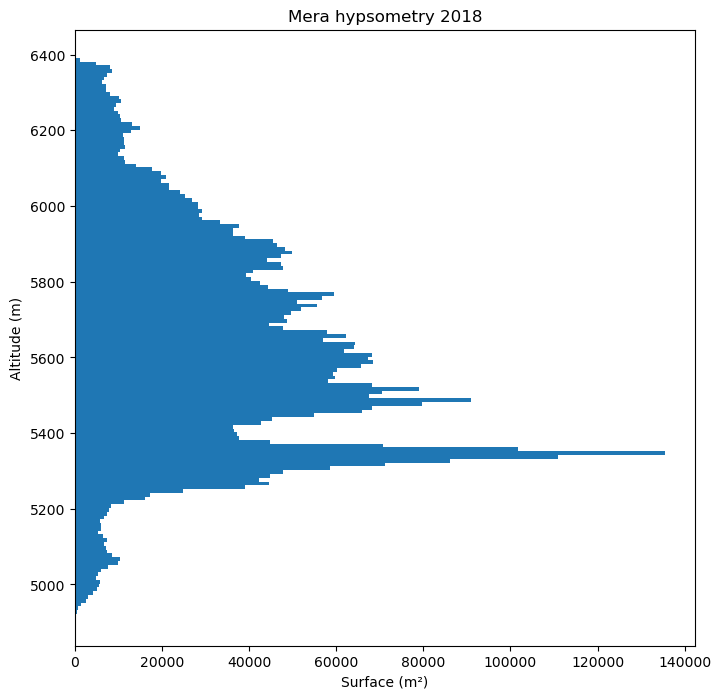

In [11]:
####### Hypsométrie Mera #######
file = '/home/turpinli/Mera_SMB/hypsometry_2012_2018_Naulek_Mera_separes.xlsx' # Lien vers les données hypsométrique
df = pd.read_excel(file, sheet_name="2018", header=2) # Ouverture du fichier en choisissant la feuille 2018 et en omettant les premières lignes 
#print(df.head())
#print(df.columns)

df = df[["Elev. [m]", " Area [m2]"," Area [m2].1"]] 
df.columns = ["Elevation", "Area Mera", "Area Naulek"] # Définition des deux colonnes utilisées
df["Area"] = (df["Area Mera"].astype(str).str.replace(",", ".").astype(float)+df["Area Naulek"].astype(str).str.replace(",", ".").astype(float)) # Convertit en string pour passer les , en . pour calcul python, et remet en float
df = df.dropna() 

#### Plot Hypso ####
plt.figure(figsize=(8,8))

plt.barh(df["Elevation"], df["Area"], height=10)

plt.xlabel("Surface (m²)")
plt.ylabel("Altitude (m)")
plt.title("Mera hypsometry 2018")

plt.show()

Mera mean alt : 5624.24273219547 m


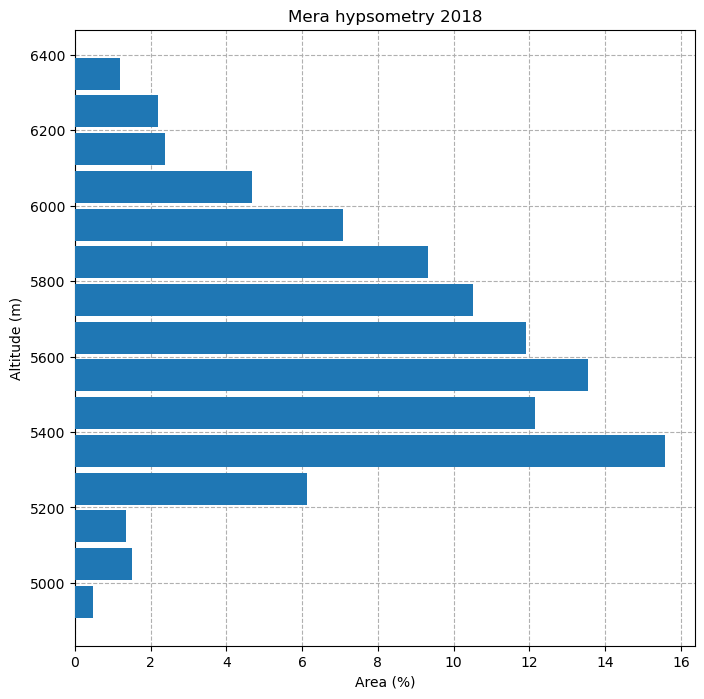

In [12]:
####### Hypsométrie Mera 100m band #######
file = '/home/turpinli/Mera_SMB/hypsometry_2012_2018_Naulek_Mera_separes.xlsx' # Lien vers les données hypsométrique
df = pd.read_excel(file, sheet_name="2018", header=2) # Ouverture du fichier en choisissant la feuille 2018 et en omettant les premières lignes 
#print(df.head())
#print(df.columns)

df = df[["Elev. [m]", " Area [m2]"," Area [m2].1"]] 
df.columns = ["Elevation", "Area Mera", "Area Naulek"] # Définition des deux colonnes utilisées
df["elev_bin"] = (df["Elevation"] // 100) * 100

df["Area"] = (df["Area Mera"].astype(str).str.replace(",", ".").astype(float)+df["Area Naulek"].astype(str).str.replace(",", ".").astype(float)) # Convertit en string pour passer les , en . pour calcul python, et remet en float
df_100m = df.groupby("elev_bin")["Area"].sum().reset_index()
df_100m["elev_center"] = df_100m["elev_bin"] + 50
df_100m["Area_%"] = df_100m["Area"] / df_100m["Area"].sum() * 100

# Altitude moyenne
Mera_alt_mean = (df_100m["elev_center"] * df_100m["Area_%"] / 100).sum()
print('Mera mean alt :', Mera_alt_mean, 'm')

#### Plot Hypso ####
plt.figure(figsize=(8,8))

plt.barh(df_100m["elev_center"], df_100m["Area_%"], height=85, zorder=3)

plt.xlabel("Area (%)")
plt.ylabel("Altitude (m)")
plt.title("Mera hypsometry 2018")

plt.grid(linestyle='--', zorder=0)
plt.show()

# Loading MAR data 

In [13]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

SMB_year = []

for j in range(nyy):
    ###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    ds_ICE_mask = ds_ICE_mask.assign_coords(Y=ds_SMBy.Y, X=ds_SMBy.X) # Force le ICE_mask a être sur la même grille que le SMB
    ds_SMBy = ds_SMBy.where(ds_ICE_mask) # On fait directement un tri sur les données. Seuls les points de grille avec de la glace >= ice_level seront reconnus
    SMB_year.append(ds_SMBy)

####### Style of map 3x3 or khumbu #####
clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"


Grid alt = 4831.3545 m


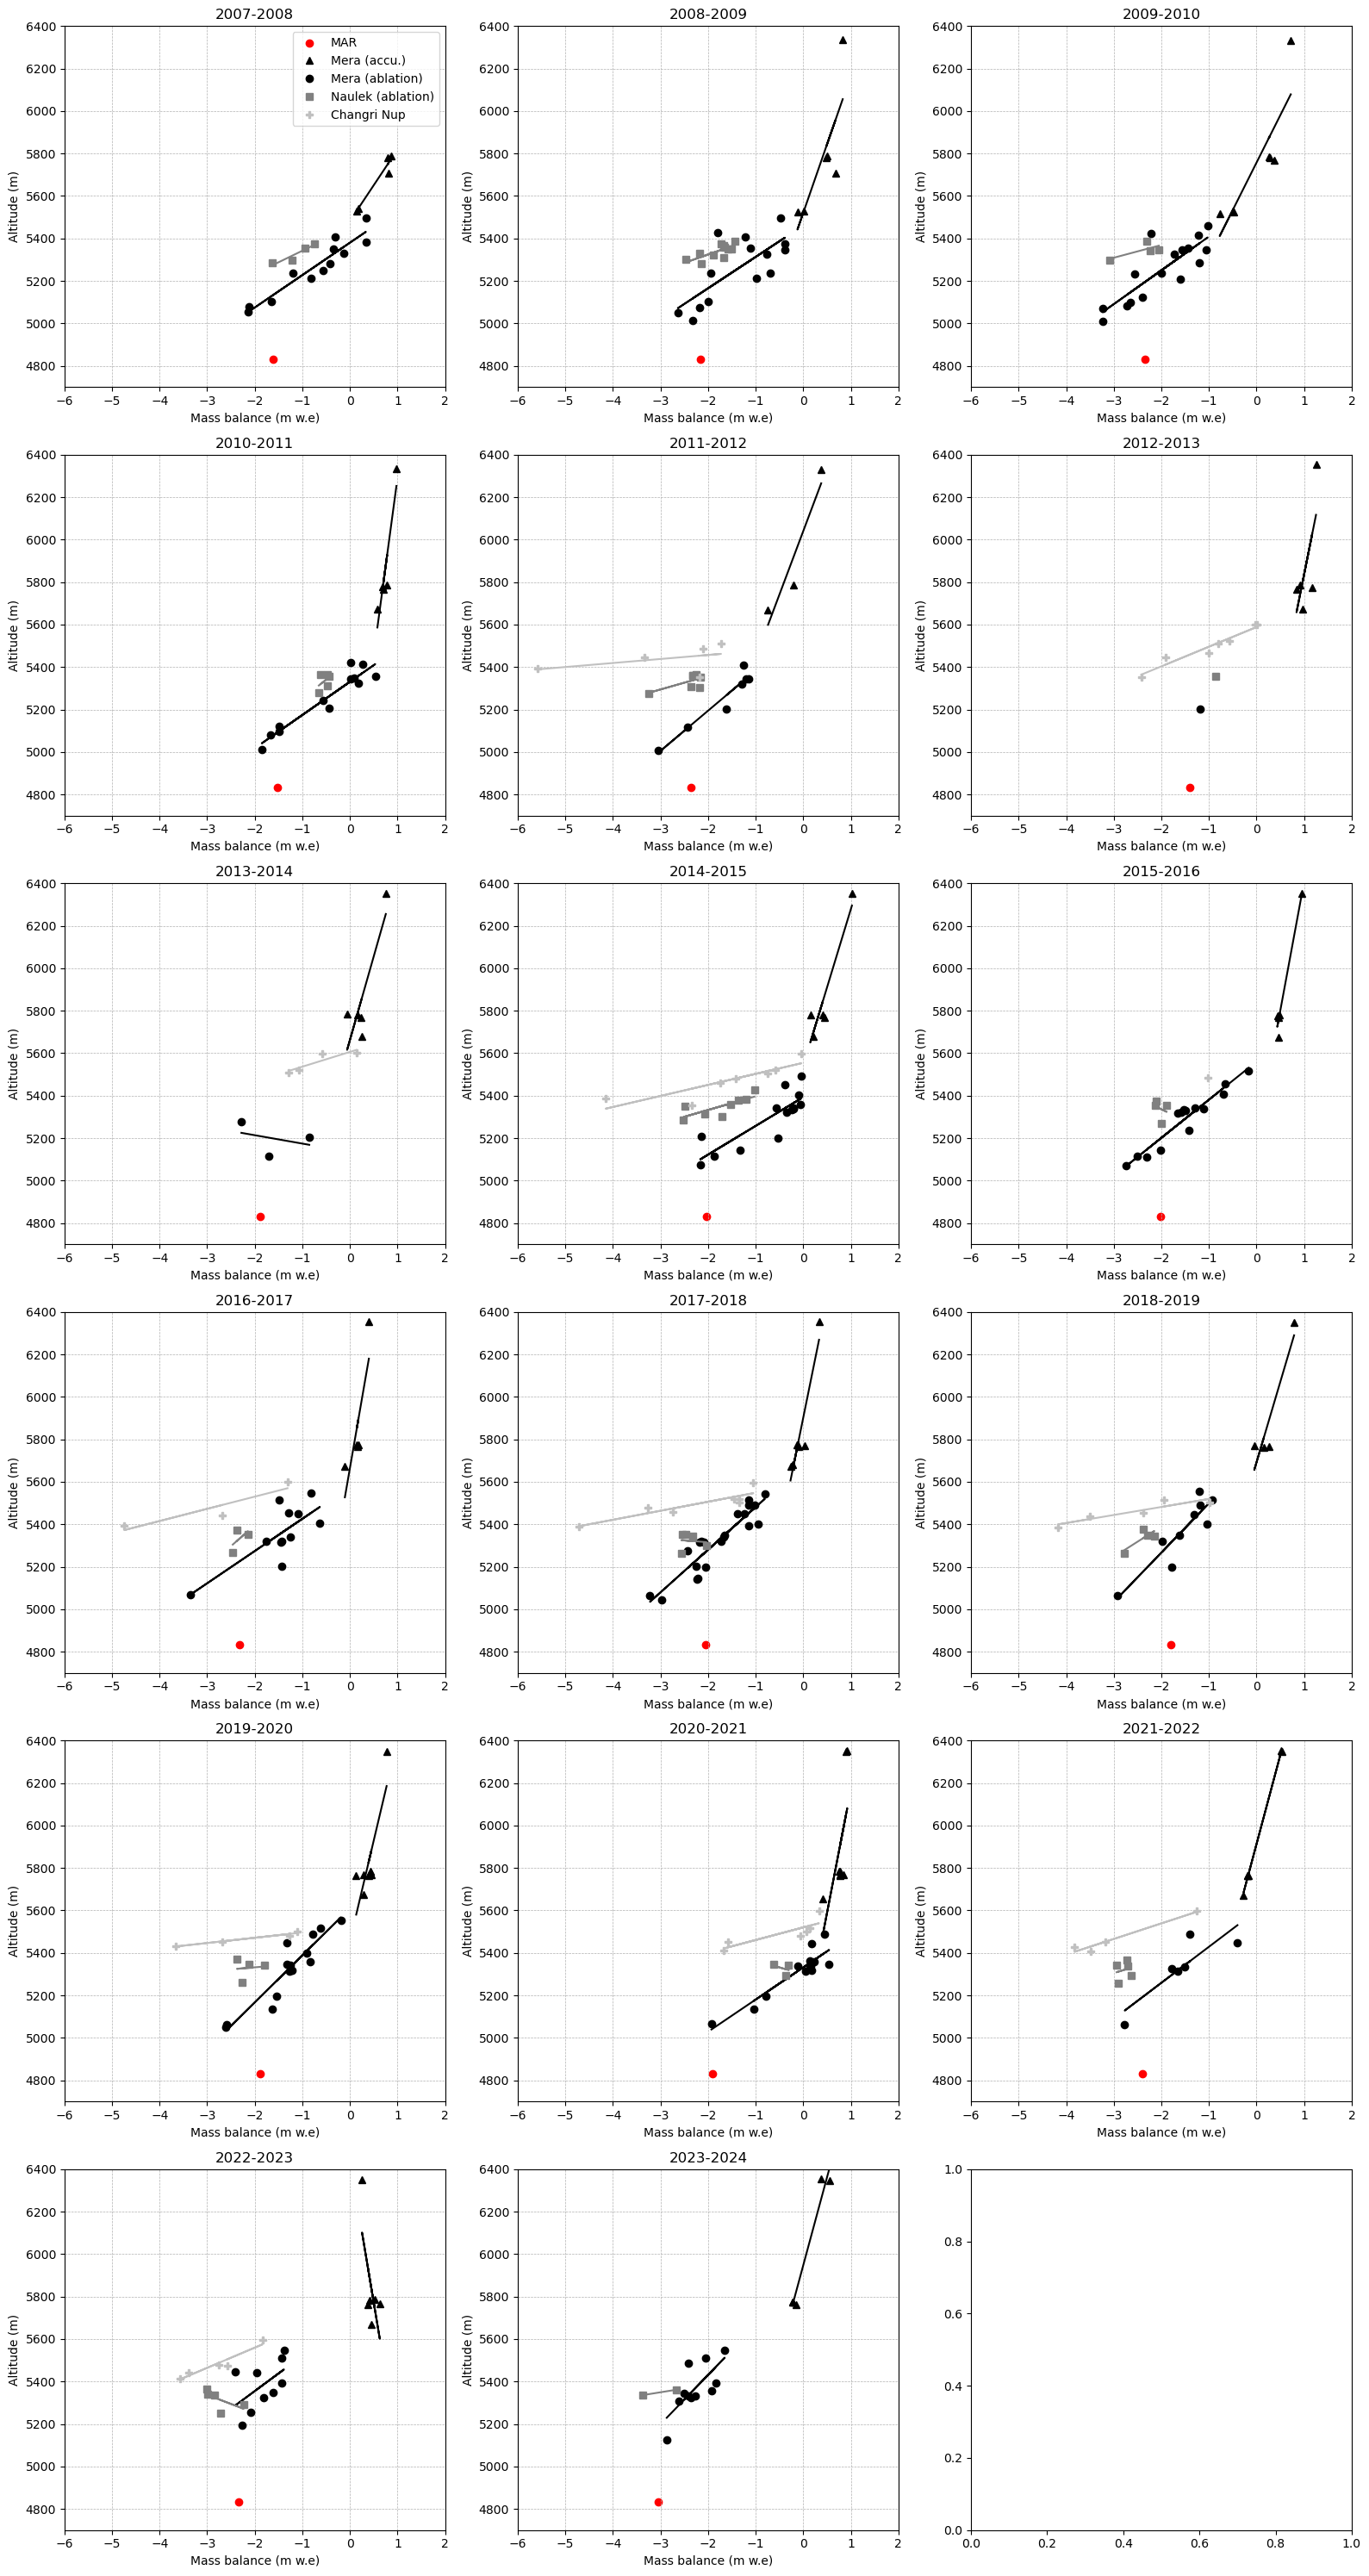

In [14]:
### Mera grid point
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_Mera = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle
    
    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=iY, X=iX)
    
    if j == 0:
        SMB_day = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=iY, X=iX) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list_Mera.append(SMB_MAR)

    SH_MAR = ds_SH.isel(y=iY, x=iX) # Altitude de la grille de MAR au Peak Mera (coord iY,iX)
    
    ax.scatter(SMB_MAR, SH_MAR, color="r", label="MAR") # Affiche le point de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-6, 2)
    ax.set_ylim(4700, 6400)
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
print('Grid alt =', SH_MAR.values, 'm')
plt.tight_layout()
#plt.savefig("Changri.png")

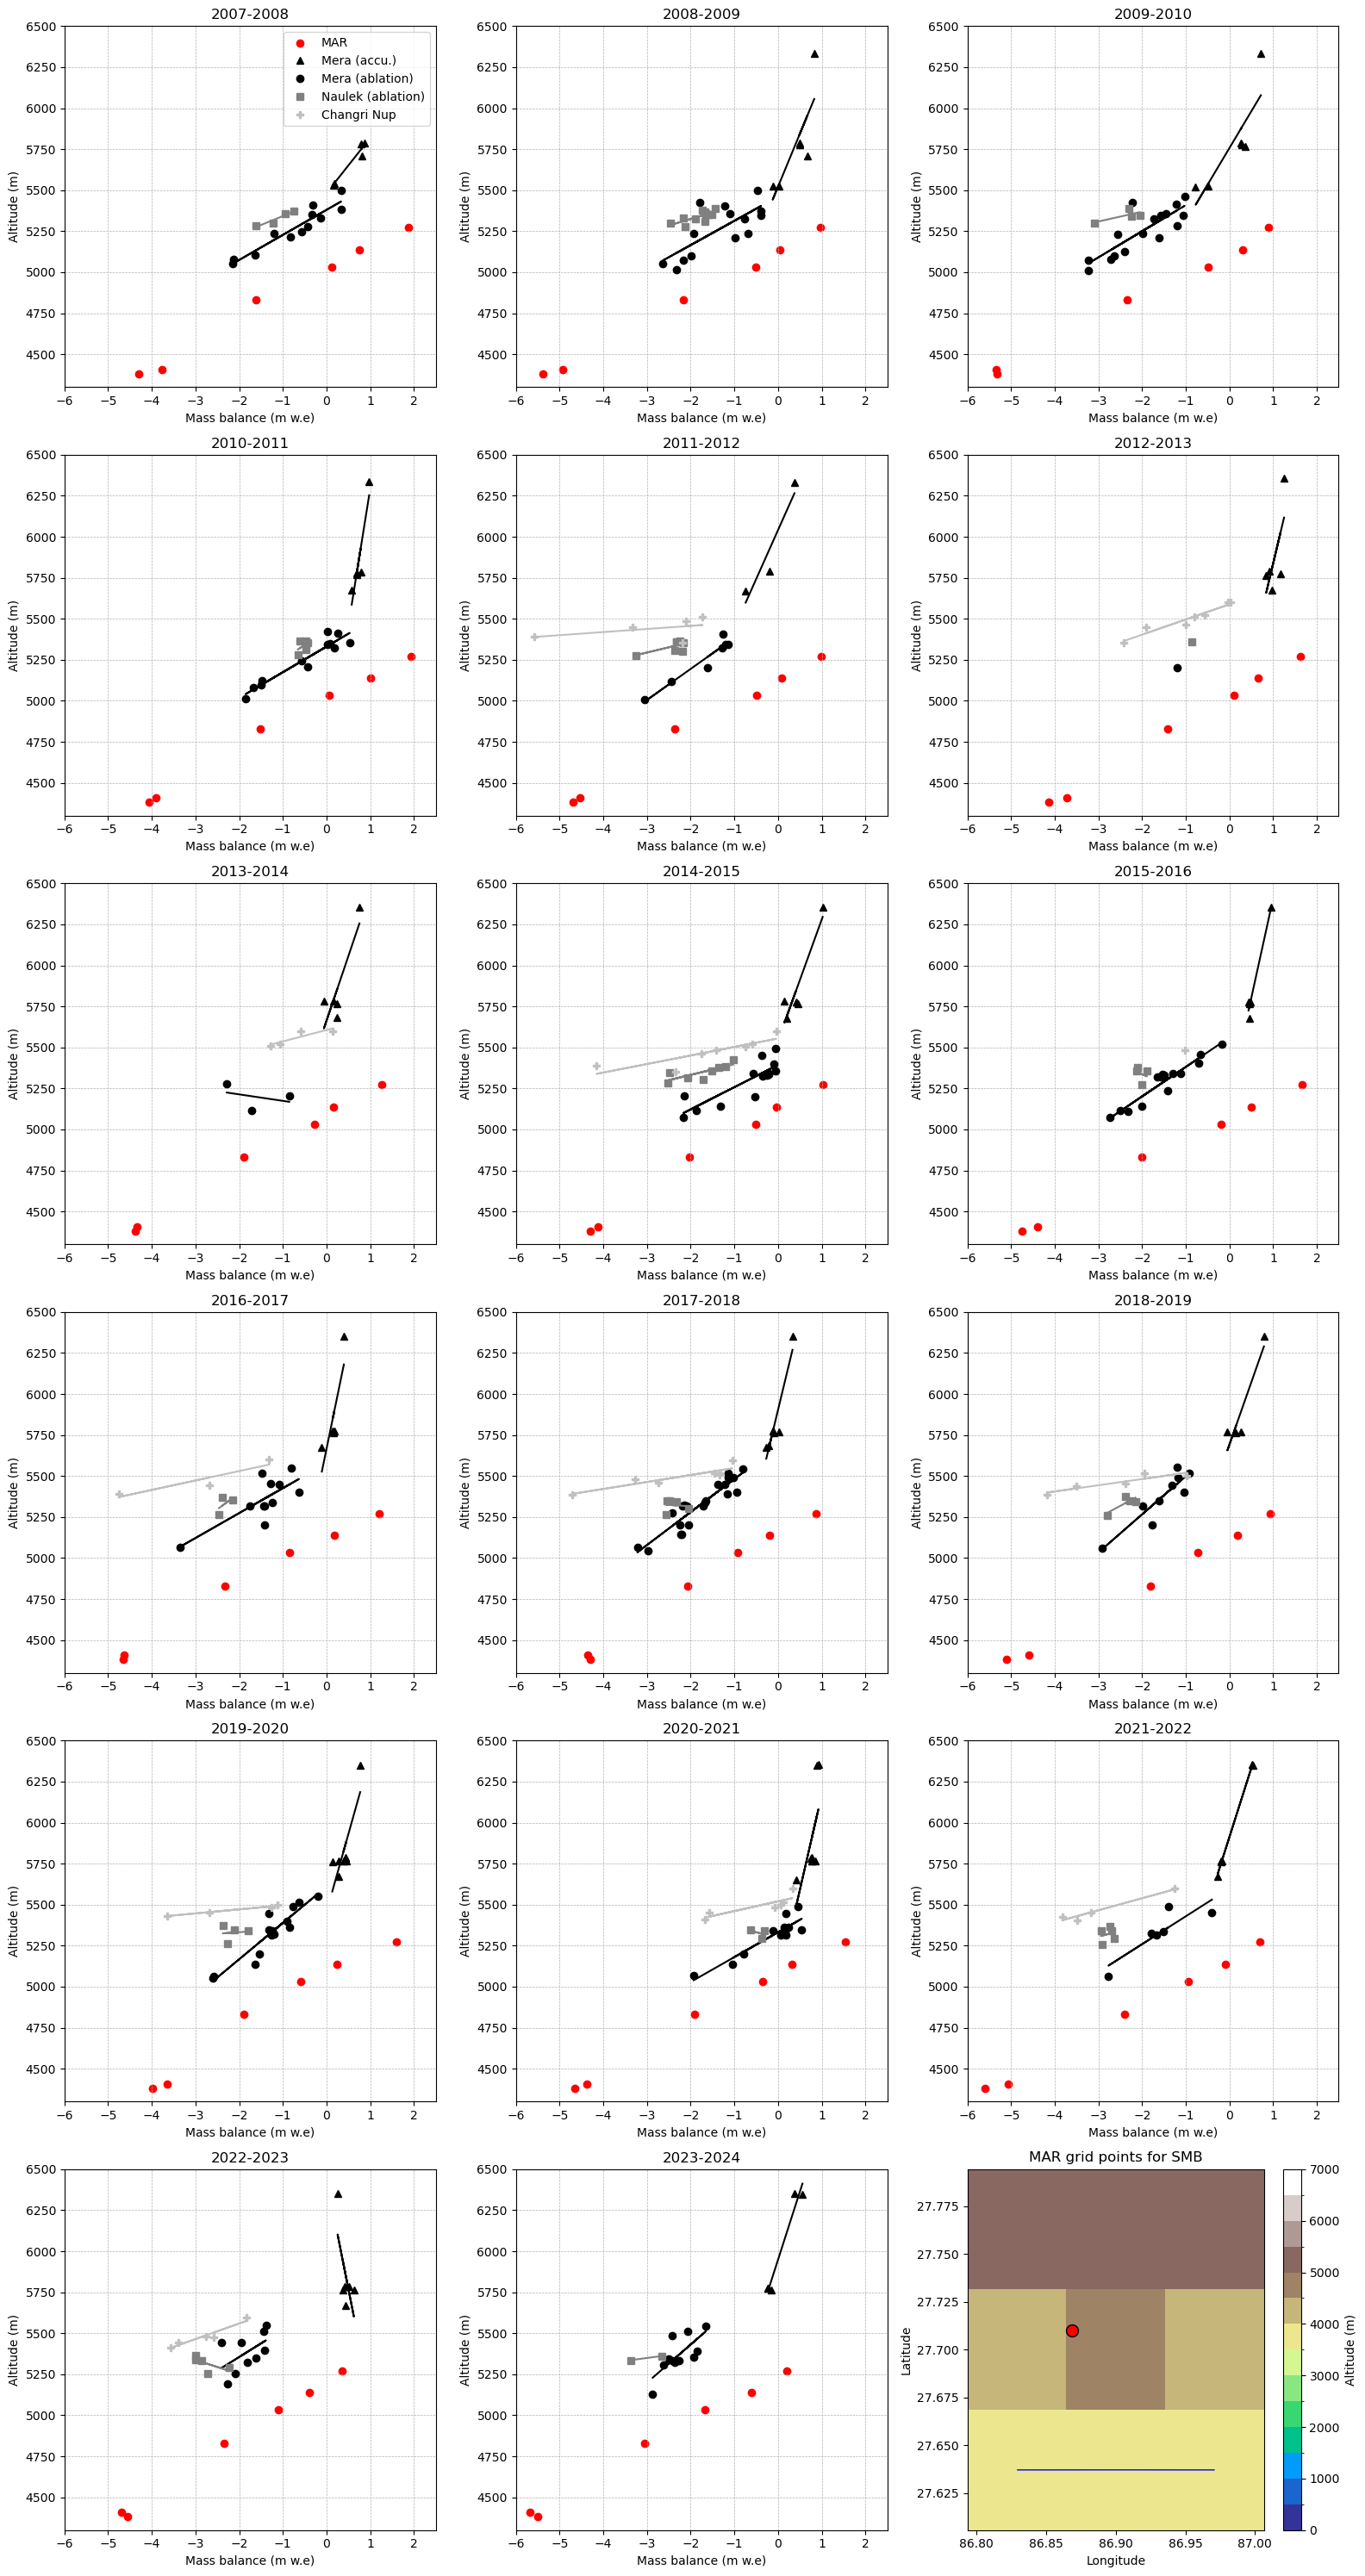

In [15]:
### 3x3 grid around Mera

Ydown, Yup, Xleft, Xright = iY-1, iY+2, iX-1, iX+2 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day2 = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day2 = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum2 = SMB_day2.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR2 = SMB_sum2.values.flatten()
 
    SH_MAR2 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR2 != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR2 = SMB_MAR2[mask_zero]
    SH_MAR2 = SH_MAR2[mask_zero]
    
    ax.scatter(SMB_MAR2, SH_MAR2, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
   
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
    ax.set_xlim(-6, 2.5)
    ax.set_ylim(4300, 6500) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()
#plt.savefig("Grid_around_Mera.png")

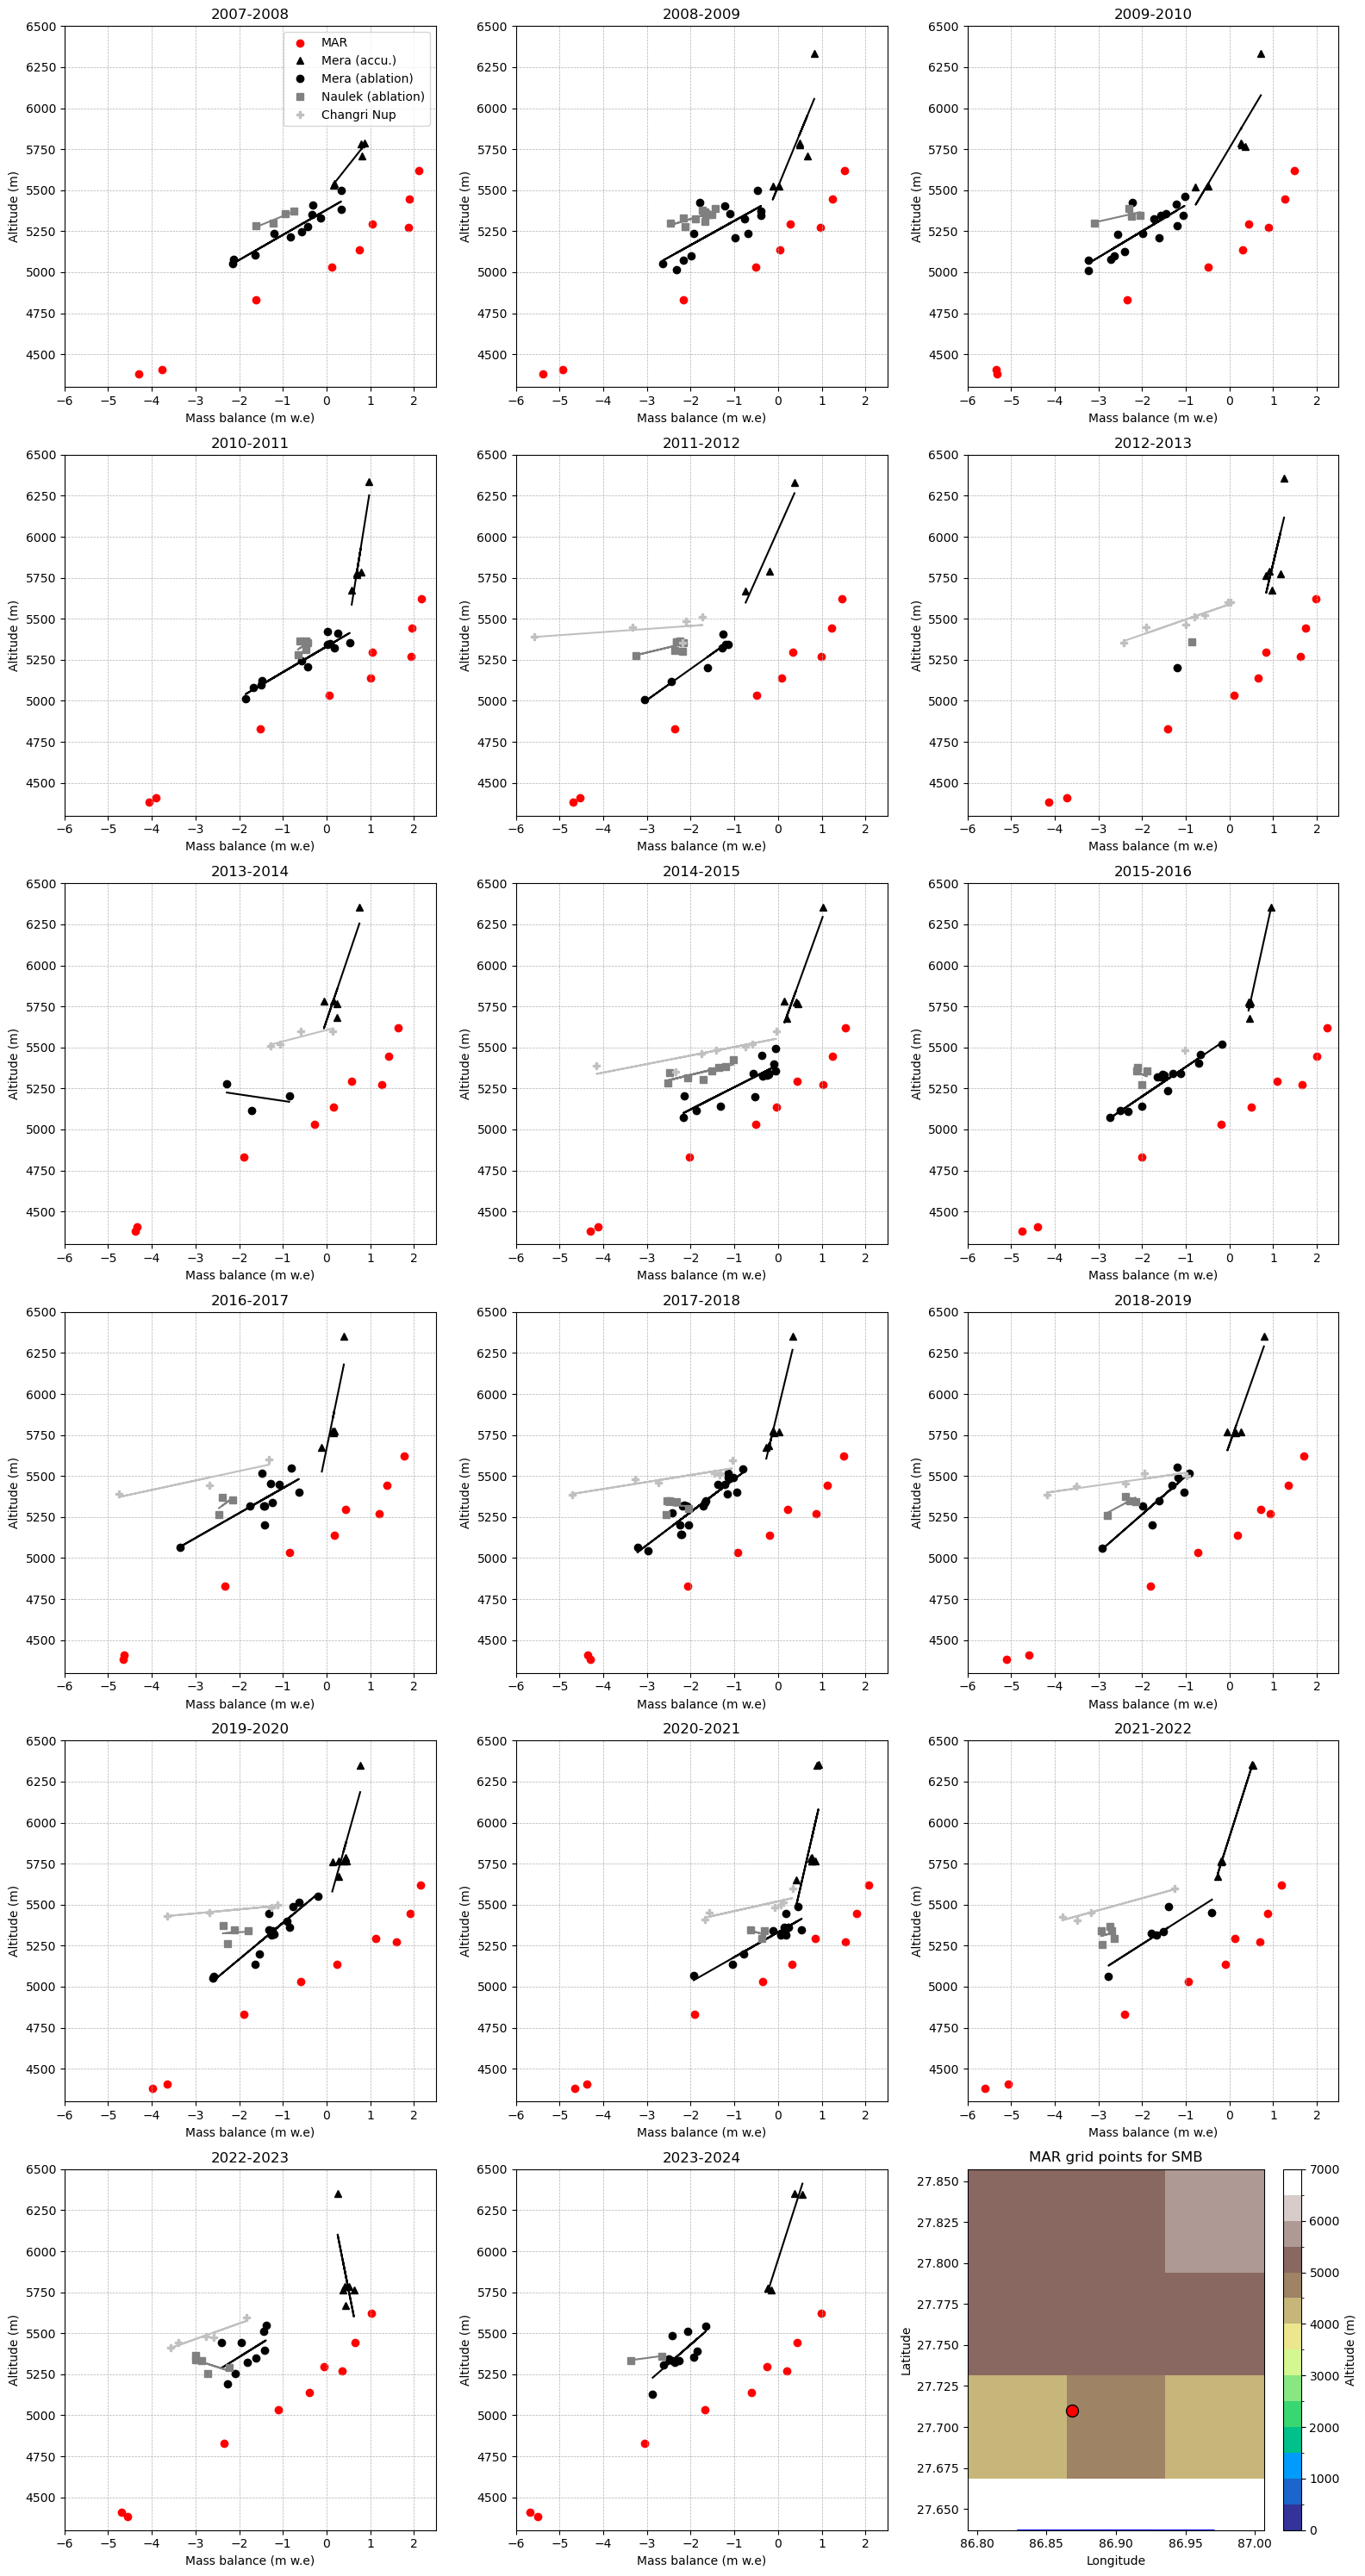

In [16]:
### 3x3 grid North of Mera

Ydown, Yup, Xleft, Xright = iY, iY+3, iX-1, iX+2 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]
ds_SH3 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_lat_mera3 = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_mera3 = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera3, ds_lat_mera3, ds_SH3, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day3 = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day3 = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum3 = SMB_day3.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR3 = SMB_sum3.values.flatten() 

    SH_MAR3 = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR3 != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR3 = SMB_MAR3[mask_zero]
    SH_MAR3 = SH_MAR3[mask_zero]

    ax.scatter(SMB_MAR3, SH_MAR3, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-6, 2.5)
    ax.set_ylim(4300, 6500) # Restriction du domaine 
    ax.grid(linestyle = '--', linewidth = 0.5)

    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()
#plt.savefig("Grid_north_Mera.png")

9 0 86.32823 28.265364
8 0 86.32857 28.202417
7 0 86.3289 28.139473
9 1 86.399704 28.265648
9 2 86.471176 28.265879


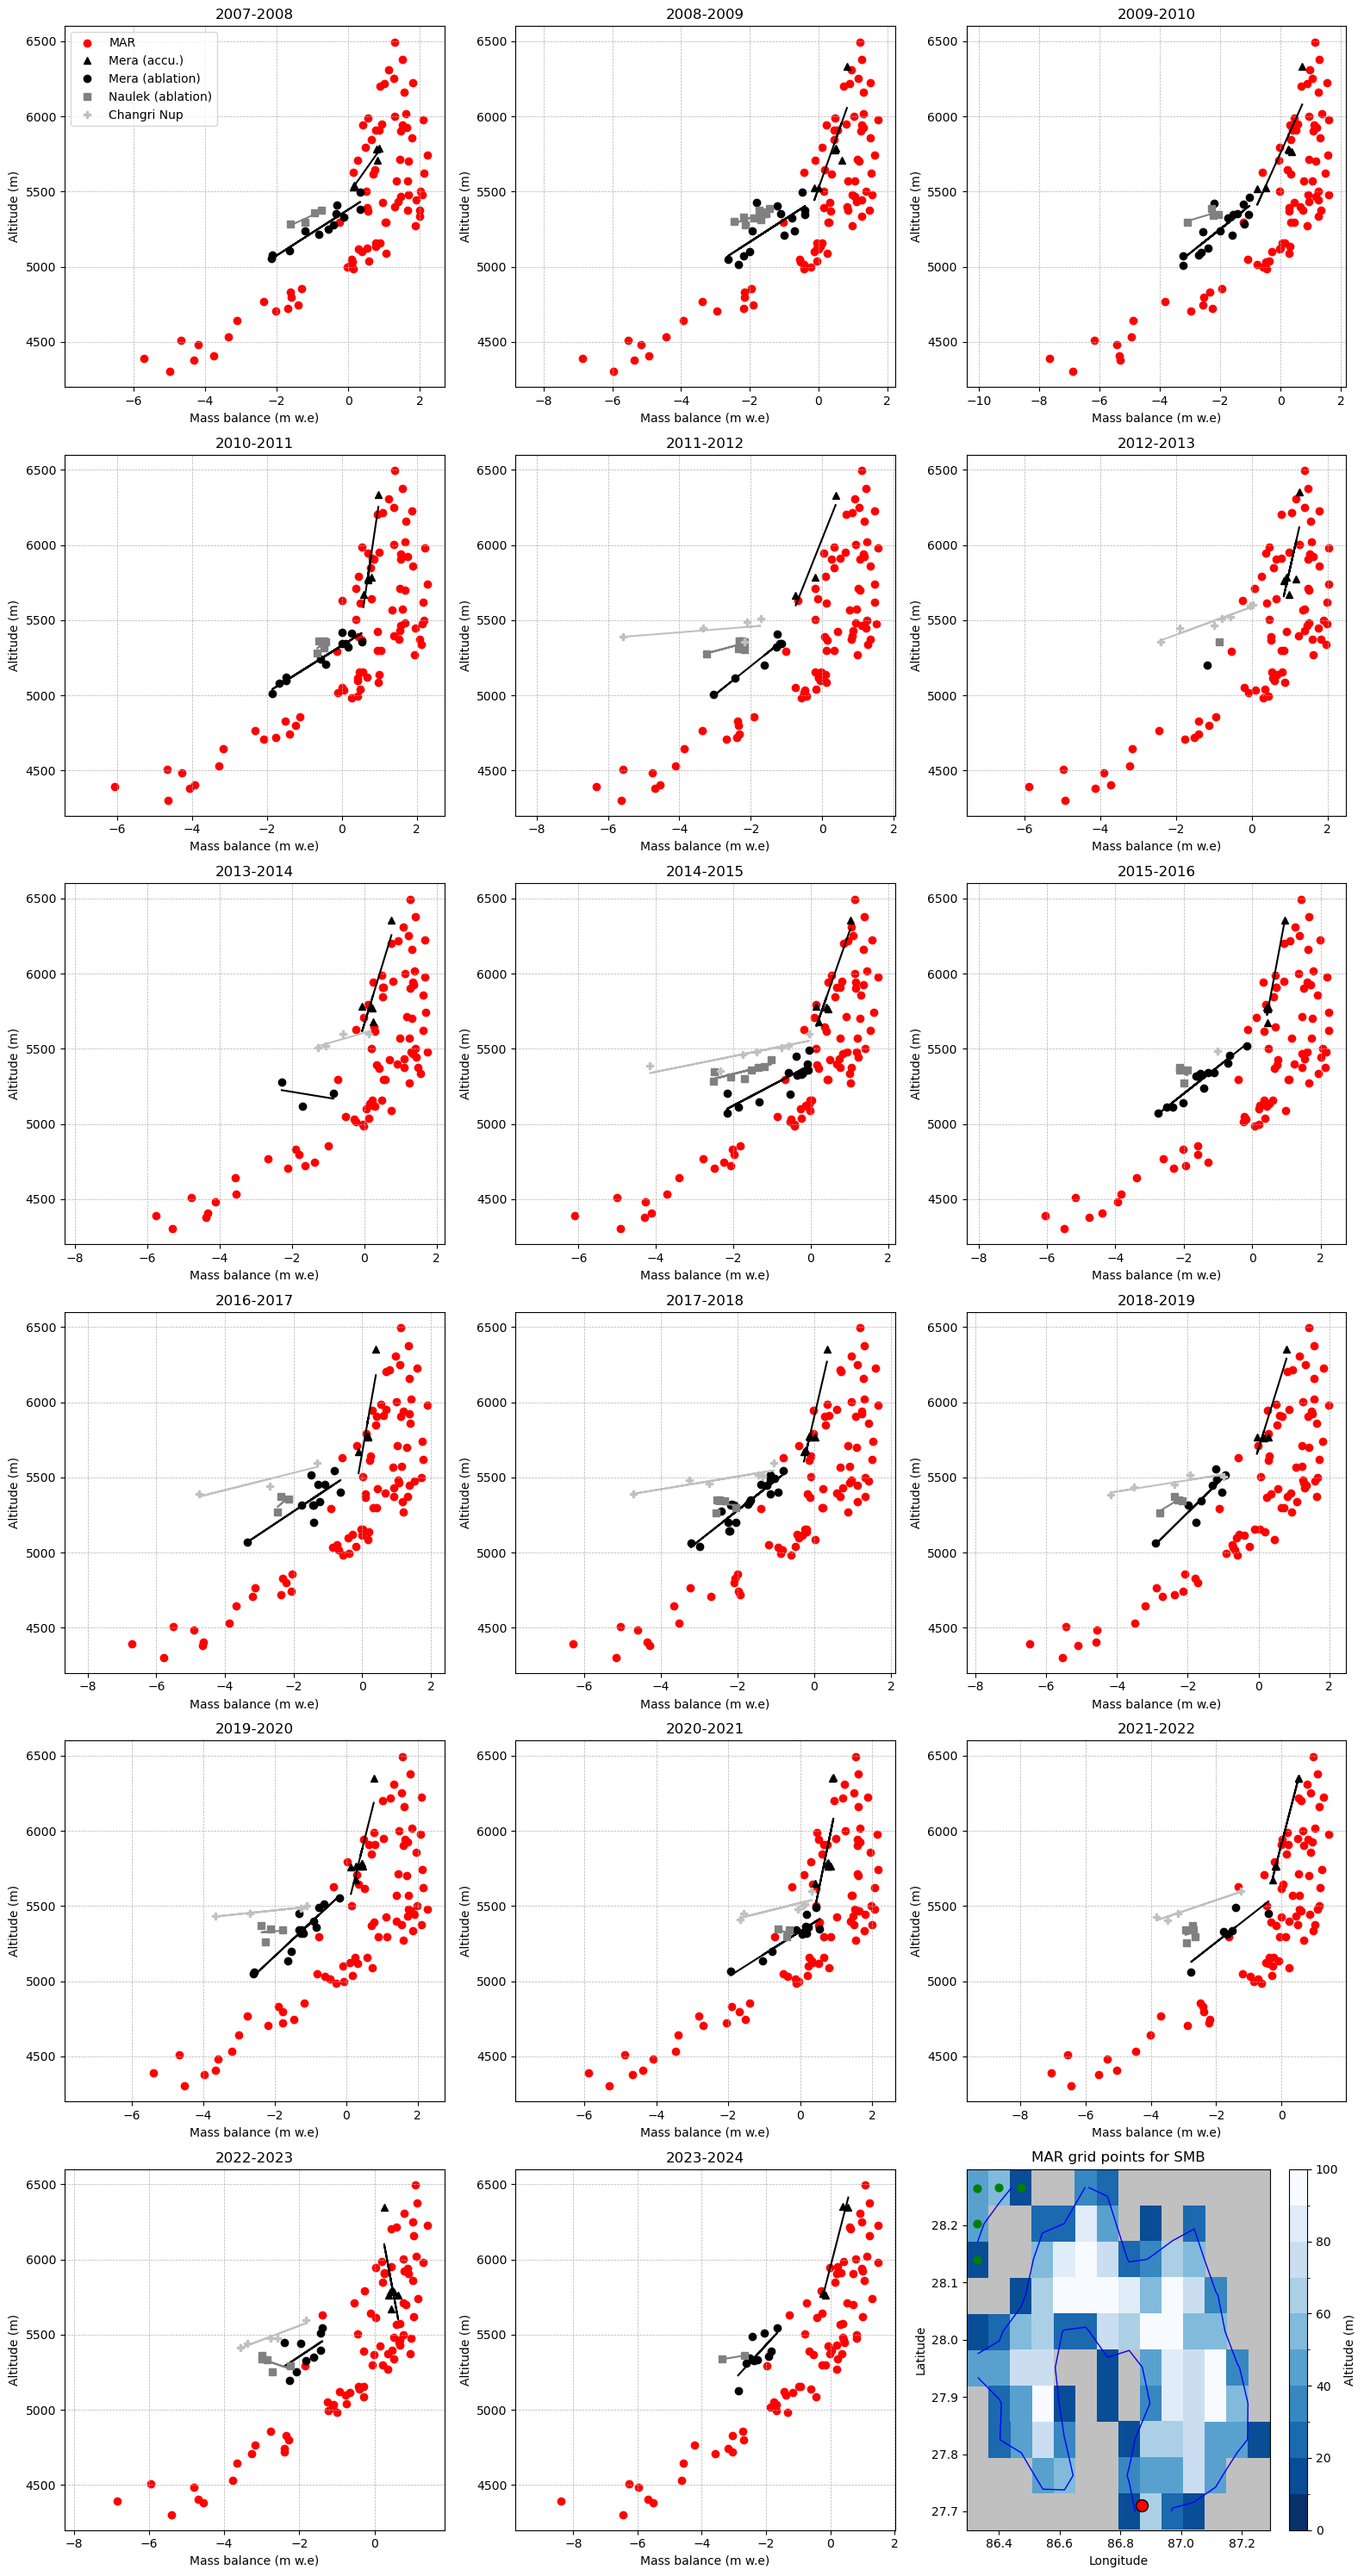

In [84]:
clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 

### Khumbu domain

Ydown, Yup, Xleft, Xright = iY, iY+10, iX-8, iX+6 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

################################################################################################
############ Création d'un masque sur les 5 points en haut à gauche à exclure ##################
Ysize = Yup - Ydown
Xsize = Xright - Xleft

mask_out = np.ones((Ysize, Xsize), dtype=bool)
out_points = [(Ysize-1, 0),(Ysize-2, 0),(Ysize-3, 0),(Ysize-1, 1),(Ysize-1, 2)]

for y, x in out_points:
    mask_out[y, x] = False
    #print(y, x, ds_lon_khumbu.values[y, x], ds_lat_khumbu.values[y, x])
#################################################################################################

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_khumbu, SMB_list_khumbu_hypso = [], []

####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

ax.set_facecolor('silver')
ICE_zero_khumbu = np.ma.masked_where(ds_ICE_khumbu ==0, ds_ICE_khumbu) # Créer un mask sur les valeurs de % de glace nul

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ICE_zero_khumbu, cmap=cmap, norm=norm, shading='auto')

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[30], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

###### Affichage des 5 points corrigés ########
for y, x in out_points:
    ax.scatter(ds_lon_khumbu.values[y, x], ds_lat_khumbu.values[y, x], color="green",s=40, zorder=5)

fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


###############################################
############### Subplot filling ############### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_out = mask_out.flatten() # Mask sur les 5 points hors du khumbu
    mask_zero = (SMB_MAR_khumbu != 0) & mask_out # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    ############ Hypsometry ###############
    df_mar = pd.DataFrame({"SMB": SMB_MAR_khumbu, "Elevation": SH_MAR_khumbu}) # Création d'un data frame pour les points de MAR

    df_mar["elev_bin"] = (df_mar["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band = df_mar.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge = pd.merge(df_mar_band, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge["SMB_weighted"] = df_merge["SMB"]*df_merge["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_khumbu_weighted = df_merge["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_list_khumbu_hypso.append(SMB_khumbu_weighted)
    #########################################
    
    # Prepare les données pour les plot en série temporelle (ici on retire les valeurs de SMB=0)
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    SMB_list_khumbu.append(SMB_regional)
    
    ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs

    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    #ax.set_xlim(-7, 3)
    ax.set_ylim(4200, 6600) # Restriction du domaine 
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
plt.tight_layout()
#plt.savefig("khumbu_ice0_new.png")

#print(date_ref[j], date_obs[j])
#print(SMB_day_khumbu.TIME.min().values, SMB_day_khumbu.TIME.max().values) # Vérification de la période prise en compte par MAR
#print(SMB_list_khumbu)

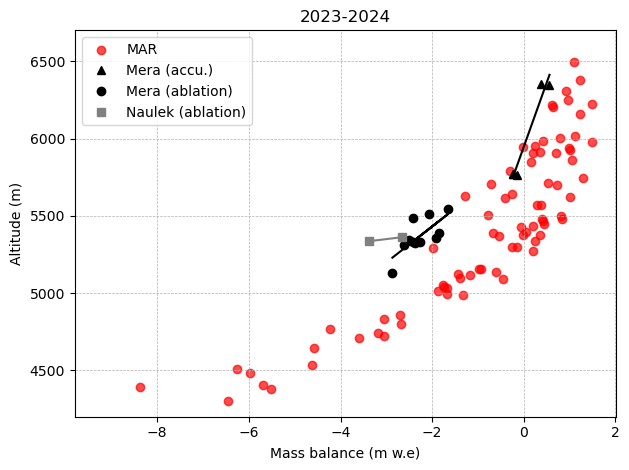

In [85]:
plt.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", alpha=0.7, label="MAR") # Affiche les points de MAR correspondant à la date des obs

###### Plot OBSERVATIONS ######
###### Accumulation
plt.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
plt.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

###### Ablation
plt.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
plt.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
plt.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
plt.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

##### Changri Nup
#plt.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup

###### Graphic features ######
plt.title(f"20{yy[j]}-20{yy[j+1]}")
plt.xlabel("Mass balance (m w.e)")
plt.ylabel("Altitude (m)")
plt.grid(linestyle = '--', linewidth = 0.5)
#plt.xlim(-7, 2)
plt.ylim(4200, 6700)
    
plt.tight_layout()
plt.legend()
plt.savefig("23_24_ice0.png")
#print(SH_MAR_khumbu)
#print(SMB_MAR_khumbu)

80


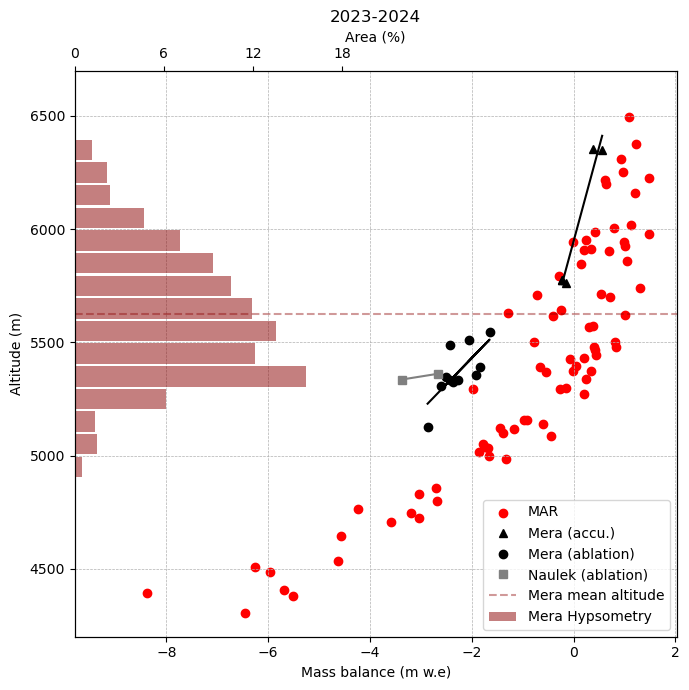

In [86]:
fig, ax = plt.subplots(figsize=(7,7))

##### MAR #####
ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", label="MAR")
print(len(SMB_MAR_khumbu))

###### OBS ######
ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)')
ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k')

ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)')
ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k')

ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)')
ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray')

##### Hypsométrie (100 m) #####
ax_hist = ax.twiny() # twiny sert à faire un plot sur un seul axe à l'inverse de inset

ax_hist.barh(df_100m["elev_center"], df_100m["Area_%"], height=90, color="darkred", alpha=0.5, label="Mera Hypsometry") # Hypsometry Mera
ax.axhline(Mera_alt_mean, color='darkred', linestyle='--', alpha=0.4, label='Mera mean altitude') # Moyenne de l'altitude du Mera

###### Axes ######
ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
ax.set_xlabel("Mass balance (m w.e)")
ax.set_ylabel("Altitude (m)")
#ax.set_xlim(-7, 2)
ax.set_ylim(4200, 6700)
ax.grid(linestyle='--', linewidth=0.5)

# Axe hypsométrie
ax_hist.set_xlabel("Area (%)")
ax_hist.set_xlim(0, df_100m["Area_%"].max()*2.6)
ax_hist.set_xticks(np.linspace(0, 18, 4)) # Permet de limiter le nombre de valeurs qu'on voit sur l'axe x

###### Légende ######
# Récupère les handles/labels des deux axes
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax_hist.get_legend_handles_labels()

ax.legend(handles1 + handles2, labels1 + labels2, loc='lower right') # Fusionne les deux légendes

plt.tight_layout()
plt.savefig("23_24_ice0_hypso.png")

9 0 86.32823 28.265364
8 0 86.32857 28.202417
7 0 86.3289 28.139473
9 1 86.399704 28.265648
9 2 86.471176 28.265879


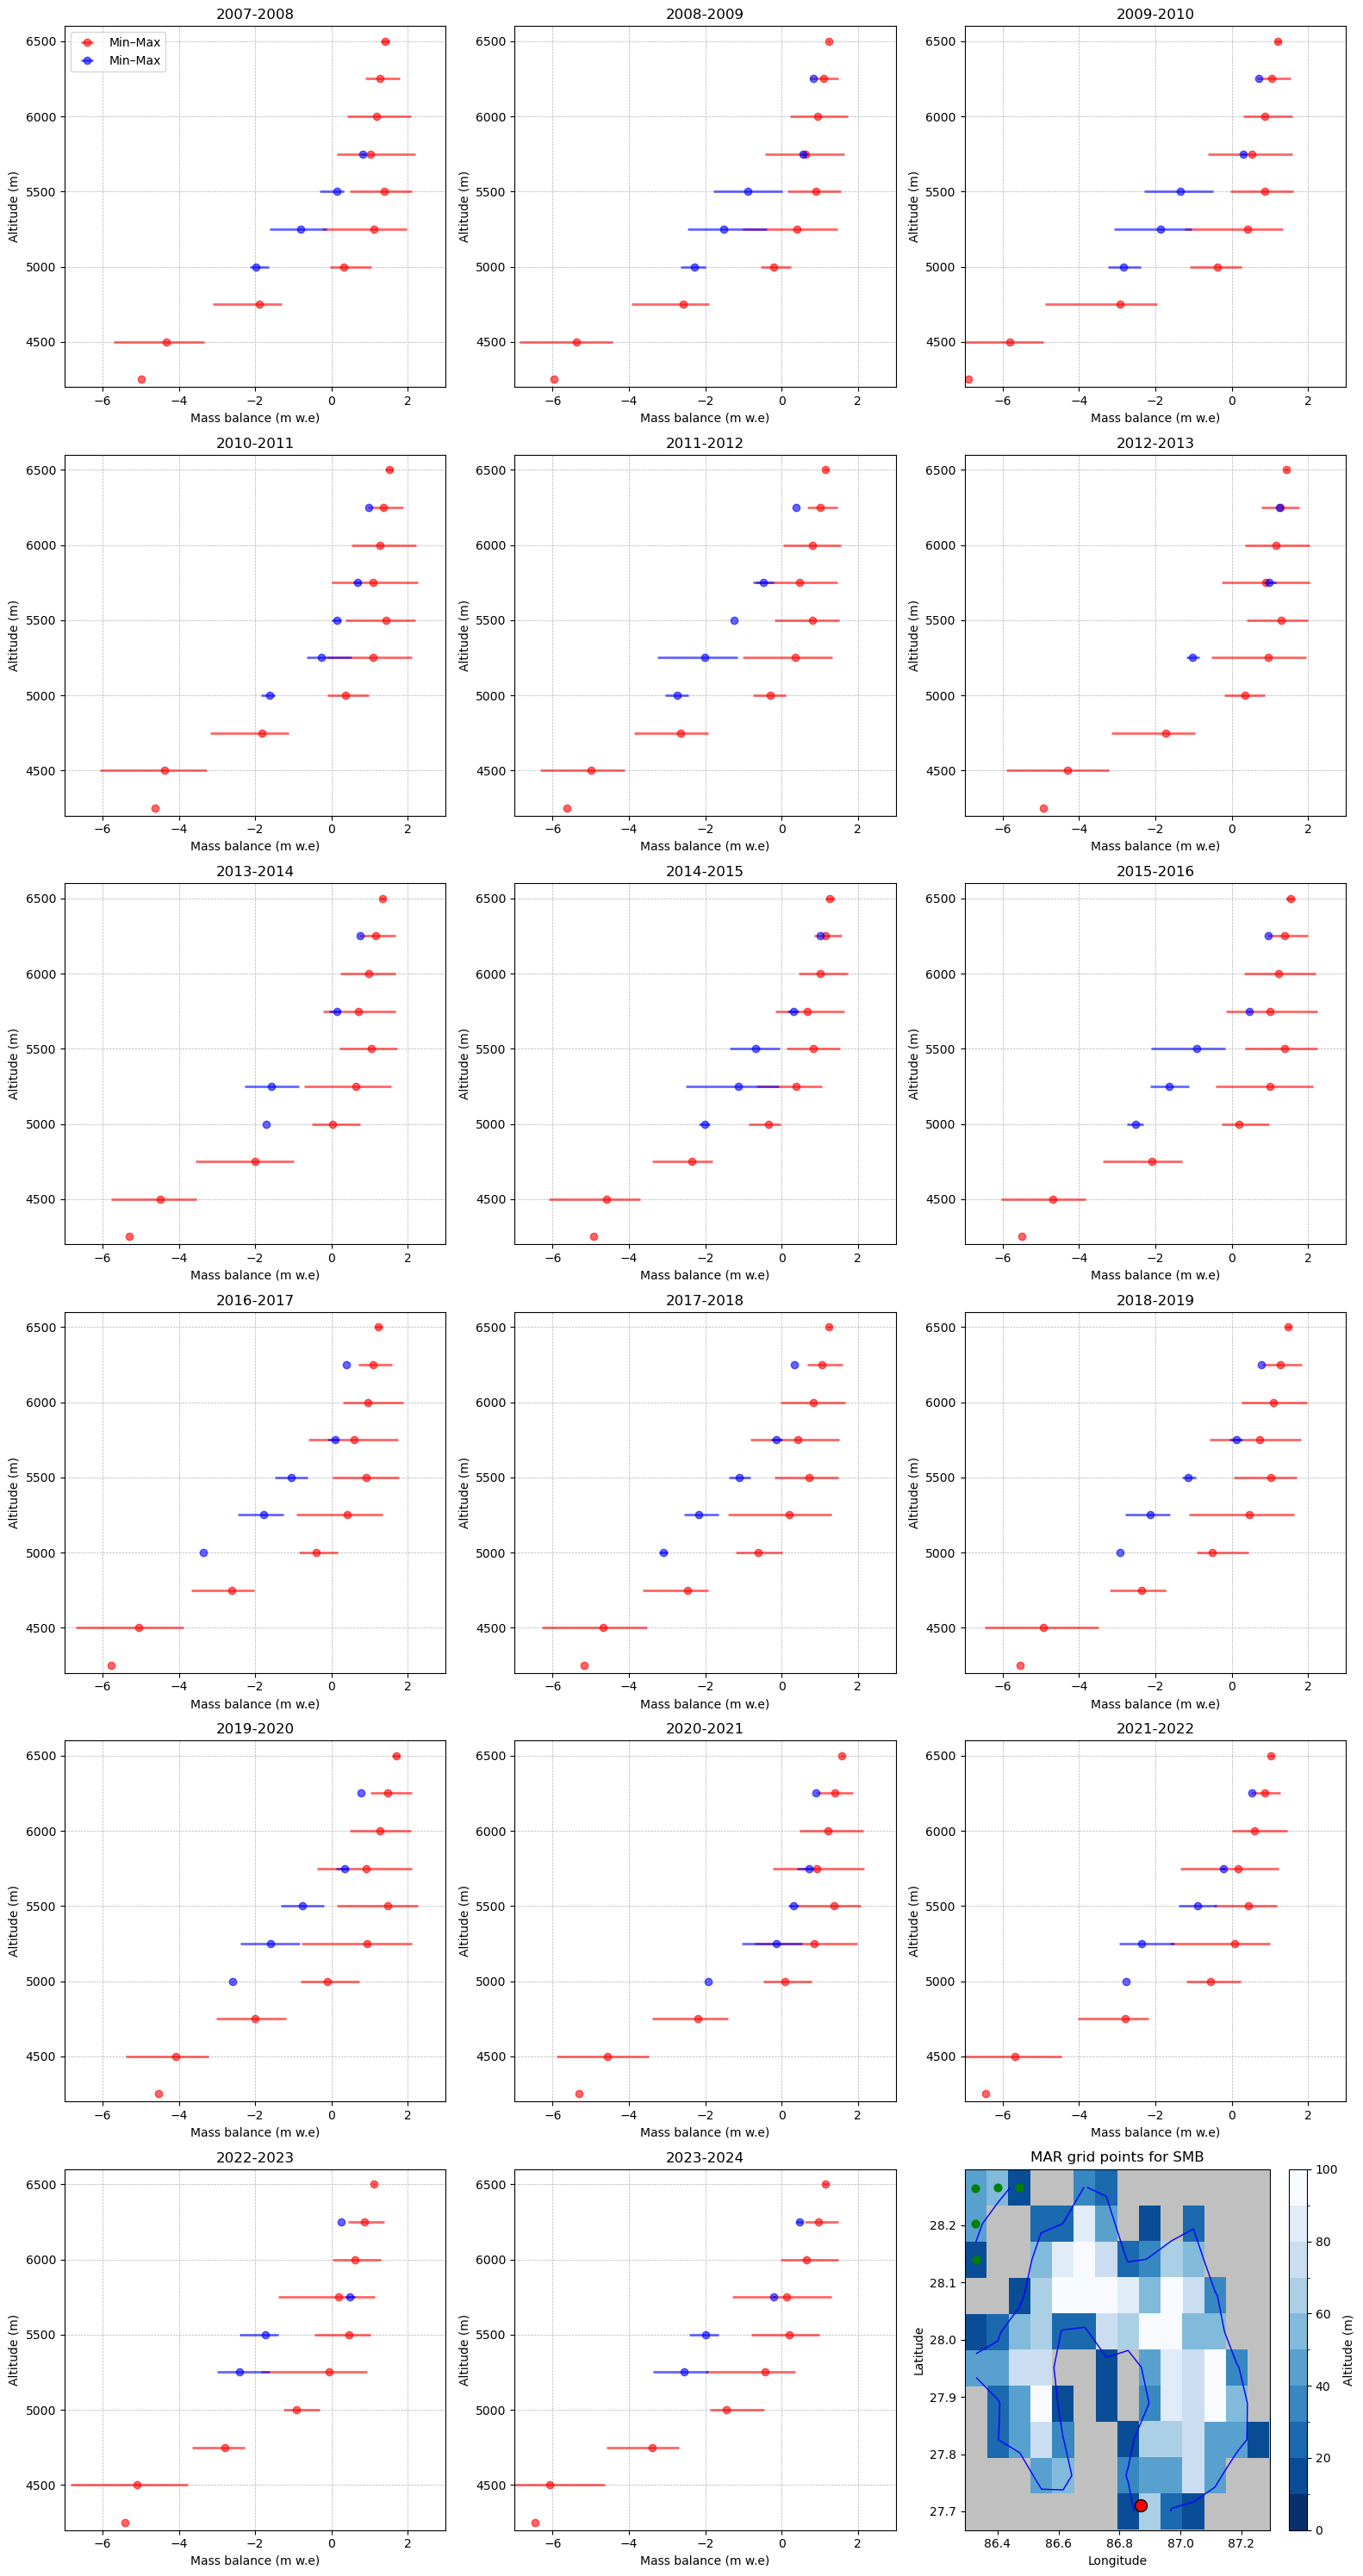

In [87]:
clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 

### Khumbu alt band

########### Stockage des résultats ###########
SMB_MAR_mean_alt_all = {}
SMB_OBS_mean_alt_all = {}

Ydown, Yup, Xleft, Xright = iY, iY+10, iX-8, iX+6 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

################################################################################################
############ Création d'un masque sur les 5 points en haut à gauche à exclure ##################
Ysize = Yup - Ydown
Xsize = Xright - Xleft

mask_out = np.ones((Ysize, Xsize), dtype=bool)
out_points = [(Ysize-1, 0),(Ysize-2, 0),(Ysize-3, 0),(Ysize-1, 1),(Ysize-1, 2)]

for y, x in out_points:
    mask_out[y, x] = False
    #print(y, x, ds_lon_khumbu.values[y, x], ds_lat_khumbu.values[y, x])
#################################################################################################

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

ax.set_facecolor('silver')
ICE_zero_khumbu = np.ma.masked_where(ds_ICE_khumbu ==0, ds_ICE_khumbu) # Créer un mask sur les valeurs de % de glace nul

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ICE_zero_khumbu, cmap=cmap, norm=norm, shading='auto')

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[30], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

###### Affichage des 5 points corrigés ########
for y, x in out_points:
    ax.scatter(ds_lon_khumbu.values[y, x], ds_lat_khumbu.values[y, x], color="green",s=40, zorder=5)

fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

########### Grille d'altitude commune ###########
alt_band_global = np.arange(125, 7000, 250)
alt_center_global = alt_band_global + 125
n_alt = len(alt_center_global)

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR
    
    mask_out = mask_out.flatten() # Mask sur les 5 points hors du khumbu
    mask_zero = (SMB_MAR_khumbu != 0) & mask_out # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    #### Création des classes d'altitude (pas de 250 m)
    alt_band = np.arange(125, 7000, 250)
    alt_classes = np.digitize(SH_MAR_khumbu, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

    SMB_min, SMB_max, SMB_p50, alt_center = [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

    ########### Initialisation MAR avec NaN ###########
    SMB_p50_full = np.full(n_alt, np.nan)
    SMB_min_full = np.full(n_alt, np.nan)
    SMB_max_full = np.full(n_alt, np.nan)
    
    for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
        # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur la classe et sur si la valeur de SMB n'est pas nulle
        m = (alt_classes == a) & (SMB_MAR_khumbu != 0) 

        smbk = SMB_MAR_khumbu[m]
        
        if len(smbk) == 0:
            continue
        idx = a - 1  # index global

        SMB_p50_full[idx] = np.mean(smbk)
        SMB_min_full[idx] = np.min(smbk)
        SMB_max_full[idx] = np.max(smbk)
    
    ########### Stockage MAR ###########
    SMB_MAR_mean_alt_all[j] = {"alt": alt_center_global, "mean": SMB_p50_full, "min": SMB_min_full, "max": SMB_max_full}

    # Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
    #ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color="r", ecolor="k", elinewidth=2, capsize=4, label="25%-75%")
    #ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="o", color="r", ecolor="r", elinewidth=2, alpha=0.6, label="Min–Max")

    valid = ~np.isnan(SMB_p50_full)
    ax.errorbar(SMB_p50_full[valid], alt_center_global[valid], xerr=[SMB_p50_full[valid]-SMB_min_full[valid], SMB_max_full[valid]-SMB_p50_full[valid]], fmt="o", color="r", ecolor="r", elinewidth=2, alpha=0.6, label="Min–Max")
    
    ################# OBSERVATION ################
    SMB_obs = np.concatenate([SMB_accu_m[j], SMB_ablation_m[j], SMB_ablation_n[j]]) # Assemblage des listes ensemble 
    SH_obs = np.concatenate([SH_accu_m[j], SH_ablation_m[j], SH_ablation_n[j]])
    
    #### Création des classes d'altitude (pas de 250 m)
    alt_band_obs = np.arange(125, 7000, 250)
    alt_classes_obs = np.digitize(SH_obs, alt_band_obs) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

    SMB_min_obs, SMB_max_obs, SMB_p50_obs, alt_center_obs = [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

    ########### Initialisation OBS avec NaN ###########
    SMB_p50_obs_full = np.full(n_alt, np.nan)
    SMB_min_obs_full = np.full(n_alt, np.nan)
    SMB_max_obs_full = np.full(n_alt, np.nan)
    
    for a in np.unique(alt_classes_obs): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
        # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
        m = (alt_classes_obs == a) & (SMB_obs != 0) 

        smbk = SMB_obs[m]
        
        if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
            continue

        idx = a - 1

        SMB_p50_obs_full[idx] = np.mean(smbk)
        SMB_min_obs_full[idx] = np.min(smbk)
        SMB_max_obs_full[idx] = np.max(smbk)

    ########### Stockage OBS ###########
    SMB_OBS_mean_alt_all[j] = {"alt": alt_center_global, "mean": SMB_p50_obs_full, "min": SMB_min_obs_full, "max": SMB_max_obs_full}

    # Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
    #ax.errorbar(SMB_p50_obs, alt_center_obs, xerr=[SMB_p50_obs-SMB_p25_obs, SMB_p75_obs-SMB_p50_obs], fmt="o", color="b", ecolor="b", elinewidth=2, capsize=4, label="25%-75%")
    #ax.errorbar(SMB_p50_obs, alt_center_obs, xerr=[SMB_p50_obs-SMB_min_obs, SMB_max_obs-SMB_p50_obs], fmt="o", color="b", ecolor="b", elinewidth=2, alpha=0.6, label="Min–Max")

    valid = ~np.isnan(SMB_p50_obs_full)
    ax.errorbar(SMB_p50_obs_full[valid], alt_center_global[valid], xerr=[SMB_p50_obs_full[valid]-SMB_min_obs_full[valid], SMB_max_obs_full[valid]-SMB_p50_obs_full[valid]], fmt="o", color="b", ecolor="b", elinewidth=2, alpha=0.6, label="Min–Max")
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-7, 3)
    ax.set_ylim(4200, 6600) # Restriction du domaine 
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
        
#print(SMB_MAR_mean_alt_all[0]['mean'])
#print(SMB_OBS_mean_alt_all[0])
plt.tight_layout()
plt.savefig("khumbu_ice0_new_altclass.png")

80


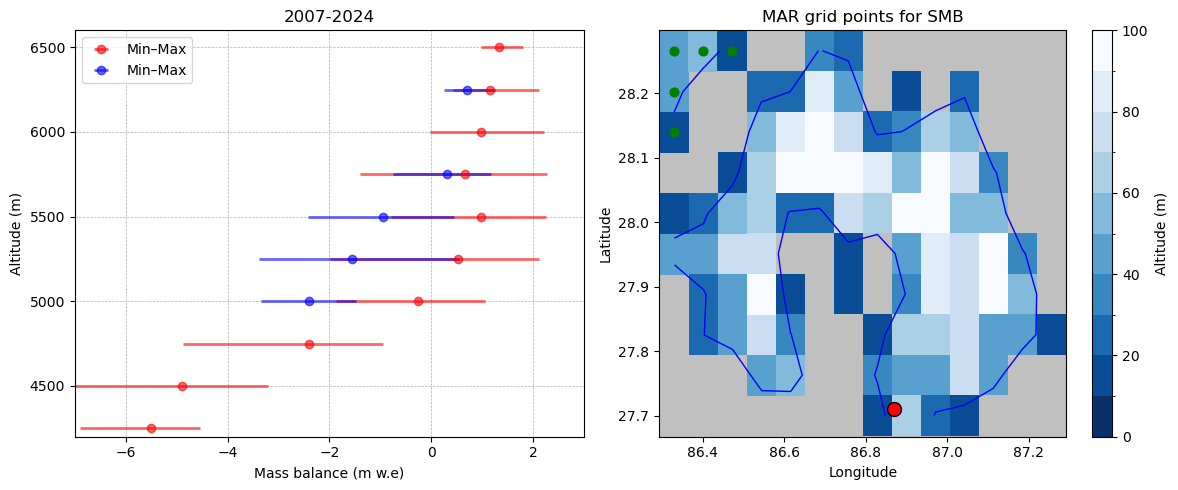

In [91]:
### Khumbu alt band for the all period 2007-2024

Ydown, Yup, Xleft, Xright = iY, iY+10, iX-8, iX+6 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

fig, axes = plt.subplots(1, 2, figsize=(12,5))
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy
n = len(yy)-2

SMB_MAR_0724, SH_MAR_0724, SMB_obs_0724, SH_obs_0724 = [], [], [], [] # Stockage de toutes les années

ax0 = axes[0]
ax1 = axes[1]

###### Subplot filling ######
for j in range(n):
    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_out = mask_out.flatten() # Mask sur les 5 points hors du khumbu
    mask_zero = (SMB_MAR_khumbu != 0) & mask_out # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    SMB_MAR_0724.extend(SMB_MAR_khumbu)
    SH_MAR_0724.extend(SH_MAR_khumbu)

    ################# OBSERVATION ################
    SMB_obs = np.concatenate([SMB_accu_m[j], SMB_ablation_m[j], SMB_ablation_n[j]]) # Assemblage des listes ensemble 
    SH_obs = np.concatenate([SH_accu_m[j], SH_ablation_m[j], SH_ablation_n[j]])
    
    SMB_obs_0724.extend(SMB_obs) # Stockage des valeurs. Le .extend fait comme append() mais fait directement la concaténation des années 07-08 pour les plots dans le scatter après
    SH_obs_0724.extend(SH_obs)
#### Création des classes d'altitude (pas de 250 m)
alt_band = np.arange(125, 7000, 250)
SMB_MAR_0724 = np.array(SMB_MAR_0724)
SH_MAR_0724 = np.array(SH_MAR_0724)
alt_classes = np.digitize(SH_MAR_0724, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
    # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur la classe et sur si la valeur de SMB n'est pas nulle
    m = (alt_classes == a) & (SMB_MAR_0724 != 0) 

    smbk = SMB_MAR_0724[m]
    shk = SH_MAR_0724[m]

    if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
        continue

    p25 = np.percentile(smbk, 25)
    p50 = np.mean(smbk)   
    p75 = np.percentile(smbk, 75)
        
    # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
    SMB_p25.append(p25)
    SMB_p50.append(p50)
    SMB_p75.append(p75)
    SMB_min.append(np.min(smbk))
    SMB_max.append(np.max(smbk))
        
    #alt_center.append(np.mean(shk))
    alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)
        
SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
SMB_p50 = np.array(SMB_p50)
SMB_p75 = np.array(SMB_p75)
SMB_min = np.array(SMB_min)
SMB_max = np.array(SMB_max)
alt_center = np.array(alt_center)


# Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
#ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color="r", ecolor="k", elinewidth=2, capsize=4, label="25%-75%")

ax0.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="o", color="r", ecolor="r", elinewidth=2, alpha=0.6, label="Min–Max")
    
    
#### Création des classes d'altitude (pas de 250 m)
alt_band_obs = np.arange(125, 7000, 250)
SMB_obs_0724 = np.array(SMB_obs_0724)
SH_obs_0724 = np.array(SH_obs_0724)
alt_classes_obs = np.digitize(SH_obs_0724, alt_band_obs) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

SMB_min_obs, SMB_max_obs, SMB_p50_obs, SMB_p25_obs, SMB_p75_obs, alt_center_obs = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
    # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
    m = (alt_classes_obs == a) & (SMB_obs_0724 != 0) 

    smbk = SMB_obs_0724[m]
    shk = SH_obs_0724[m]

    if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
        continue

    p25_obs = np.percentile(smbk, 25)
    p50_obs = np.mean(smbk) 
    p75_obs = np.percentile(smbk, 75)
        
    # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
    SMB_p25_obs.append(p25_obs)
    SMB_p50_obs.append(p50_obs)
    SMB_p75_obs.append(p75_obs)
    SMB_min_obs.append(np.min(smbk))
    SMB_max_obs.append(np.max(smbk))
        
    #alt_center.append(np.mean(shk))
    alt_center_obs.append(alt_band_obs[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

SMB_p25_obs = np.array(SMB_p25_obs) # Transformation des listes en tableaux pour pouvoir les plot
SMB_p50_obs = np.array(SMB_p50_obs)
SMB_p75_obs = np.array(SMB_p75_obs)
SMB_min_obs = np.array(SMB_min_obs)
SMB_max_obs = np.array(SMB_max_obs)
alt_center_obs = np.array(alt_center_obs)

# Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
#ax.errorbar(SMB_p50_obs, alt_center_obs, xerr=[SMB_p50_obs-SMB_p25_obs, SMB_p75_obs-SMB_p50_obs], fmt="o", color="b", ecolor="b", elinewidth=2, capsize=4, label="25%-75%")

ax0.errorbar(SMB_p50_obs, alt_center_obs, xerr=[SMB_p50_obs-SMB_min_obs, SMB_max_obs-SMB_p50_obs], fmt="o", color="b", ecolor="b", elinewidth=2, alpha=0.6, label="Min–Max")
  
###### Graphic features ######
ax0.set_title("2007-2024")
ax0.set_xlabel("Mass balance (m w.e)")
ax0.set_ylabel("Altitude (m)")
ax0.set_xlim(-7, 3)
ax0.set_ylim(4200, 6600) # Restriction du domaine 
ax0.grid(linestyle = '--', linewidth = 0.5)
ax0.legend()

####### Plot ######
ax1 = axes[1]

clevs = np.arange(0, 110, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 

ax1.set_facecolor('silver')
ICE_zero_khumbu = np.ma.masked_where(ds_ICE_khumbu ==0, ds_ICE_khumbu) # Créer un mask sur les valeurs de % de glace nul

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[30], colors="b", linewidths=1) # Contours glaciers
ax1.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

#cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
pcm = ax1.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ICE_zero_khumbu, cmap=cmap, norm=norm, shading='auto')

###### Affichage des 5 points corrigés ########
for y, x in out_points:
    ax1.scatter(ds_lon_khumbu.values[y, x], ds_lat_khumbu.values[y, x], color="green",s=40, zorder=5)

fig.colorbar(pcm, ax=ax1, label="Altitude (m)")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("MAR grid points for SMB")
    
plt.tight_layout()
plt.savefig("khumbu_ice0_new_altclass.png")

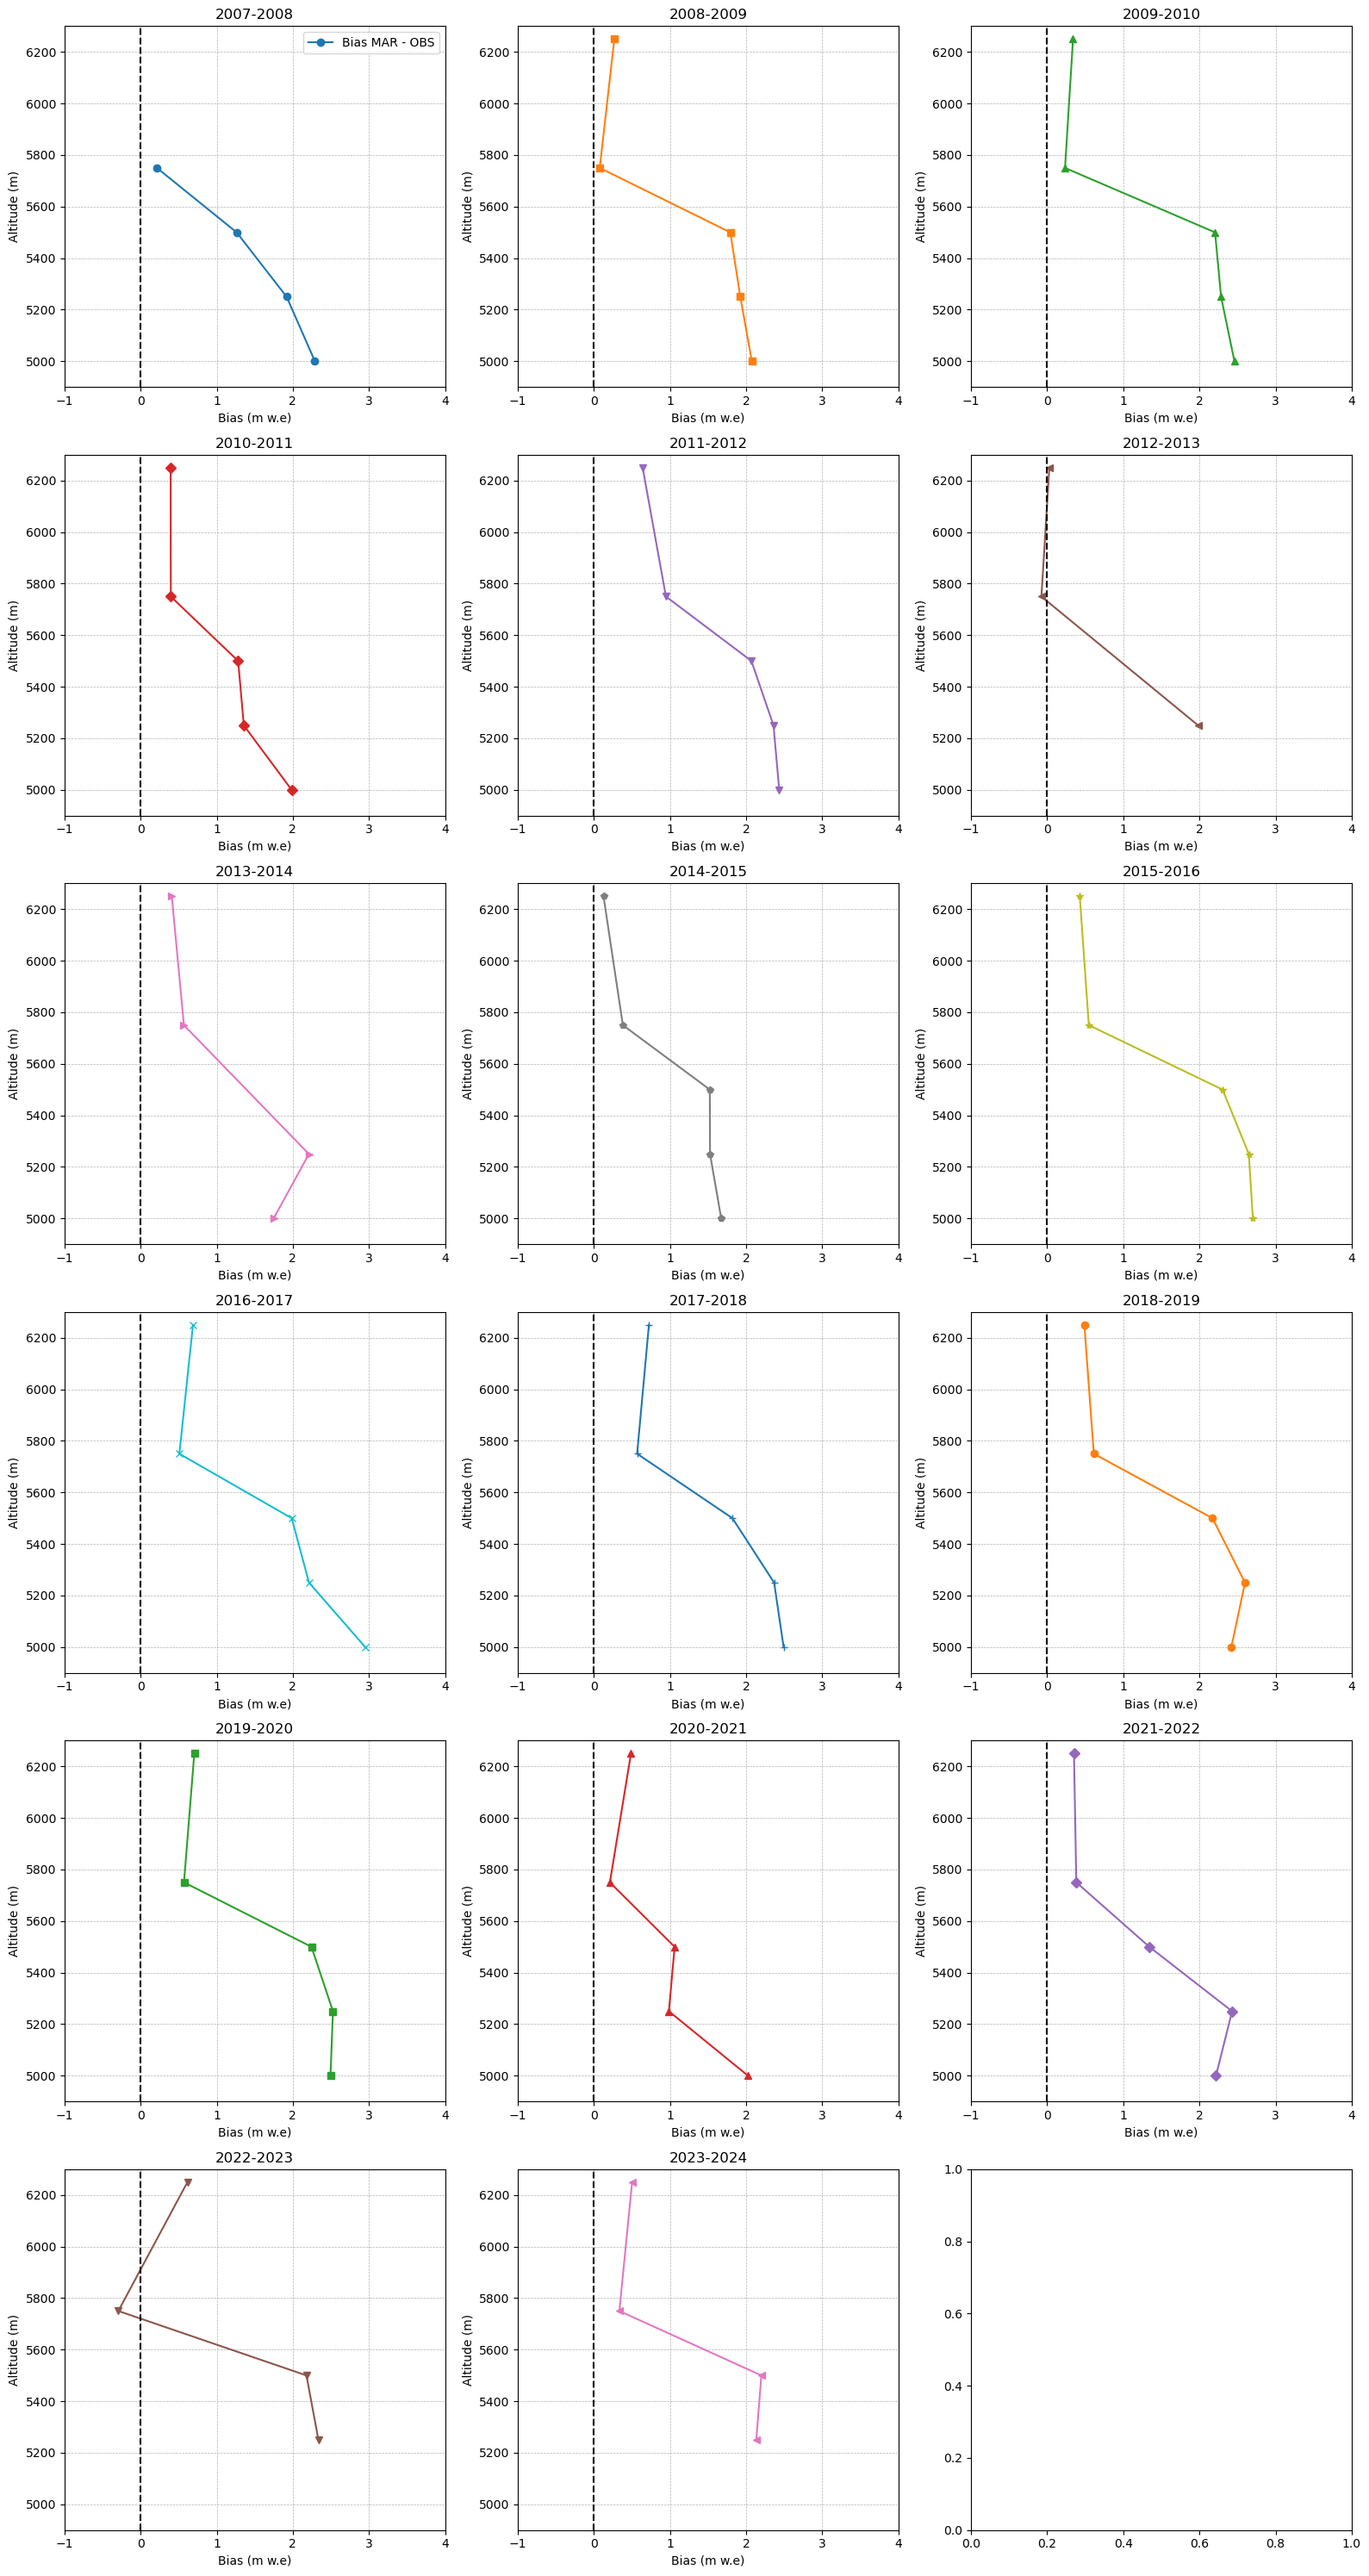

In [94]:
### Khumbu diff obs Modèle
fig, axes = plt.subplots(line, col, figsize=(16,5*line))
axes = axes.flatten()

########### Grid on last subplot ###########
axn = axes[nyy] # La grille du dernier subplot va servir à afficher toute la période
all_diff = []
all_common_alt = []

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'x', '+'] # Différents marker pour l'affichage

########## Subplot filling ###########
for j in range(nyy):
    ax = axes[j]
    
    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR
    
    mask_out = mask_out.flatten() # Mask sur les 5 points hors du khumbu
    mask_zero = (SMB_MAR_khumbu != 0) & mask_out # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]
    alt_band = np.arange(125, 7000, 250)
    alt_classes = np.digitize(SH_MAR_khumbu, alt_band)
    SMB_p50, alt_center = [], []

    for a in np.unique(alt_classes):
        m = (alt_classes == a)
        smbk = SMB_MAR_khumbu[m]
        if len(smbk) == 0:
            continue

        SMB_p50.append(np.mean(smbk))
        alt_center.append(alt_band[a-1] + 125)

    SMB_p50 = np.array(SMB_p50) # Convertit les listes en array
    alt_center = np.array(alt_center)

    
    ################### OBS ##################
    SMB_obs = np.concatenate([SMB_accu_m[j], SMB_ablation_m[j], SMB_ablation_n[j]])
    SH_obs = np.concatenate([SH_accu_m[j], SH_ablation_m[j], SH_ablation_n[j]])
    
    alt_classes_obs = np.digitize(SH_obs, alt_band)
    SMB_p50_obs, alt_center_obs = [], []

    for a in np.unique(alt_classes_obs):
        m = (alt_classes_obs == a)
        smbk = SMB_obs[m]
        if len(smbk) == 0:
            continue

        SMB_p50_obs.append(np.mean(smbk))
        alt_center_obs.append(alt_band[a-1] + 125)

    SMB_p50_obs = np.array(SMB_p50_obs)
    alt_center_obs = np.array(alt_center_obs)

    
    ############### Diff et plot #################
    common_alt = np.intersect1d(alt_center, alt_center_obs) # On cherche les bands d'altitude commune aux obs et à MAR
    diff = []
    
    for a in common_alt: # Pour chaque année, on calcul la diff model-obs, pour chaque bande d'altitude
        # On cherche la valeur de SMB associée à la bande d'altitude pour MAR et OBS pour les soustraire (on fait ça pour toutes les bandes d'une année)
        mar_p50 = SMB_p50[alt_center == a][0] # Le [0] garanti de passer à un scalaire et pas rester à xarray
        obs_p50 = SMB_p50_obs[alt_center_obs == a][0]
        diff.append(mar_p50 - obs_p50)

    diff = np.array(diff)
    all_diff.append(diff) # On stockes chaque années
    all_common_alt.append(common_alt)
    
    ax.plot(diff, common_alt, color=colors[j % len(colors)], marker=markers[j % len(markers)], label="Bias MAR - OBS") # Affichage de la diff entre le modèle et les obs selon les bandes d'altitude
    
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Bias (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-1, 4)
    ax.set_ylim(4900, 6300)
    ax.axvline(0, color='k', linestyle='--')
    ax.grid(linestyle='--', linewidth=0.5)

    if j == 0:
        ax.legend()

plt.tight_layout()
plt.savefig("khumbu_diff_altclass.png")

In [95]:
alt_band = np.arange(125, 7000, 250) # bands
diff_0724 = []

######## Fonction to compute the mean of each alt band ######
def mean_alt_band(SH, SMB):
    alt_classes = np.digitize(SH, alt_band)
    alt_center, smb_mean = [], []

    for a in np.unique(alt_classes):
        m = (alt_classes == a)
        if np.sum(m) == 0:
            continue
        smb_mean.append(np.mean(SMB[m])) # La moyenne de chaque bande d'altitude
        alt_center.append(alt_band[a-1] + 125) # Le centre de chaque bande d'alt pour affichage

    return np.array(alt_center), np.array(smb_mean), alt_classes

####### MAR / OBS #########
alt_center_mar, SMB_p50_mar, alt_classes_mar = mean_alt_band(SH_MAR_0724, SMB_MAR_0724) # Utilisation de la fonction pour MAR et les OBS en attribuant les valeurs aux variables d'alt et de moyenne
alt_center_obs, SMB_p50_obs, alt_classes_obs = mean_alt_band(SH_obs_0724, SMB_obs_0724)

####### Diff #########
common_alt_0724 = np.intersect1d(alt_center_mar, alt_center_obs) # Recherche les valeurs conjointes de ces deux séries pour les réutiliser

for a in common_alt_0724:
    mar = SMB_p50_mar[alt_center_mar == a][0] # Le [0] garanti de passer à un scalaire et pas rester à xarray
    obs = SMB_p50_obs[alt_center_obs == a][0]
    diff_0724.append(mar - obs) # Calcul la diff 

diff_0724 = np.array(diff_0724)
print(diff_0724)

###### RMSE / STD by alt ########
rmse_alt, std_alt, alt_valid = [], [], []

common_classes = np.intersect1d(np.unique(alt_classes_mar), np.unique(alt_classes_obs)) # Recherche les valeurs conjointes de ces deux séries pour les réutiliser

for a in common_classes:
    mar_0724 = SMB_MAR_0724[alt_classes_mar == a]
    obs_0724 = SMB_obs_0724[alt_classes_obs == a]

    if len(mar_0724) < 2 or len(obs_0724) < 2:
        continue
        
    mean_mar = np.mean(mar_0724) # Moyennes
    mean_obs = np.mean(obs_0724)
    
    var_mar = np.var(mar_0724) # Variances 
    var_obs = np.var(obs_0724)
    
    bias = mean_mar - mean_obs # Biais (déjà cohérent avec ton diff)
    
    # Le RMSE est racine carré de (la moyenne des erreurs au carré), donc il combine biais systématique² et les variabilités internes des jeux de données (biais + dispersion)
    rmse = np.sqrt(bias**2 + var_mar + var_obs) # RMSE = biais² + variances
    
    std = np.sqrt(var_mar + var_obs) # STD du biais (dispersion combinée)
    
    rmse_alt.append(rmse)
    std_alt.append(std)
    alt_valid.append(alt_band[a-1] + 125)

rmse_alt = np.array(rmse_alt)
std_alt = np.array(std_alt)
alt_valid = np.array(alt_valid)

# Alignement permet de re aligner les rmse et std avec les bonnes valeurs sur les classes d'altitudes en commun (car ils n'ont été calculé que pour certaines classe d'altitude)
rmse_align = np.array([rmse_alt[np.where(alt_valid == a)[0][0]] if a in alt_valid else np.nan for a in common_alt_0724])
std_align  = np.array([std_alt[np.where(alt_valid == a)[0][0]] if a in alt_valid else np.nan for a in common_alt_0724])

[2.14257197 2.07972943 1.92733496 0.33903225 0.46871984]


[2.14257197 2.07972943 1.92733496 0.33903225 0.46871984]
[2.28067394 2.39792284 2.1531277  0.95835213 0.64730112]


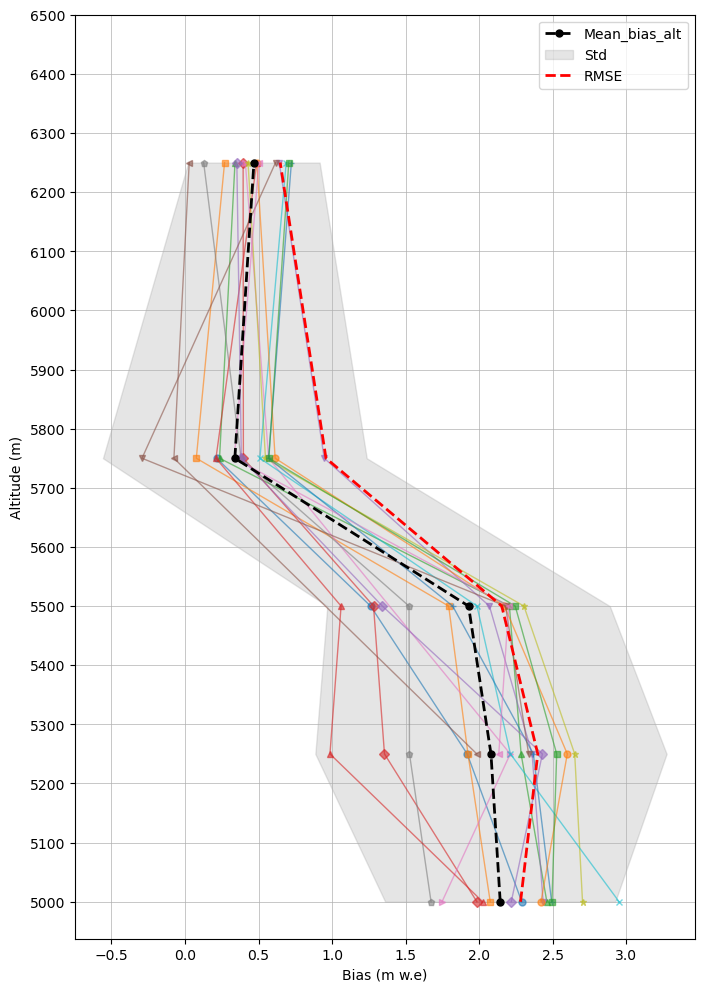

In [96]:
plt.figure(figsize=(8,12))

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'x', '+'] # Différents marker pour l'affichage

for j in range(nyy):
    plt.plot(all_diff[j], all_common_alt[j], '-', marker=markers[j % len(markers)],  alpha=0.6, markersize=5, linewidth=1)

plt.plot(diff_0724, common_alt_0724, '--', marker='o', markersize=5, color='k', linewidth=2, label="Mean_bias_alt")
plt.fill_betweenx(common_alt_0724, diff_0724 - std_align, diff_0724 + std_align, color="gray", alpha=0.2, label="Std")
plt.plot(rmse_align, common_alt_0724, color="red", linestyle="--", label="RMSE", linewidth=2)

plt.yticks(np.linspace(5000,6500,16))
plt.xlabel("Bias (m w.e)")
plt.ylabel("Altitude (m)")
plt.legend()

plt.grid('--', linewidth=0.5)
plt.savefig("diff_mean.png")
print(diff_0724)
print(rmse_align)

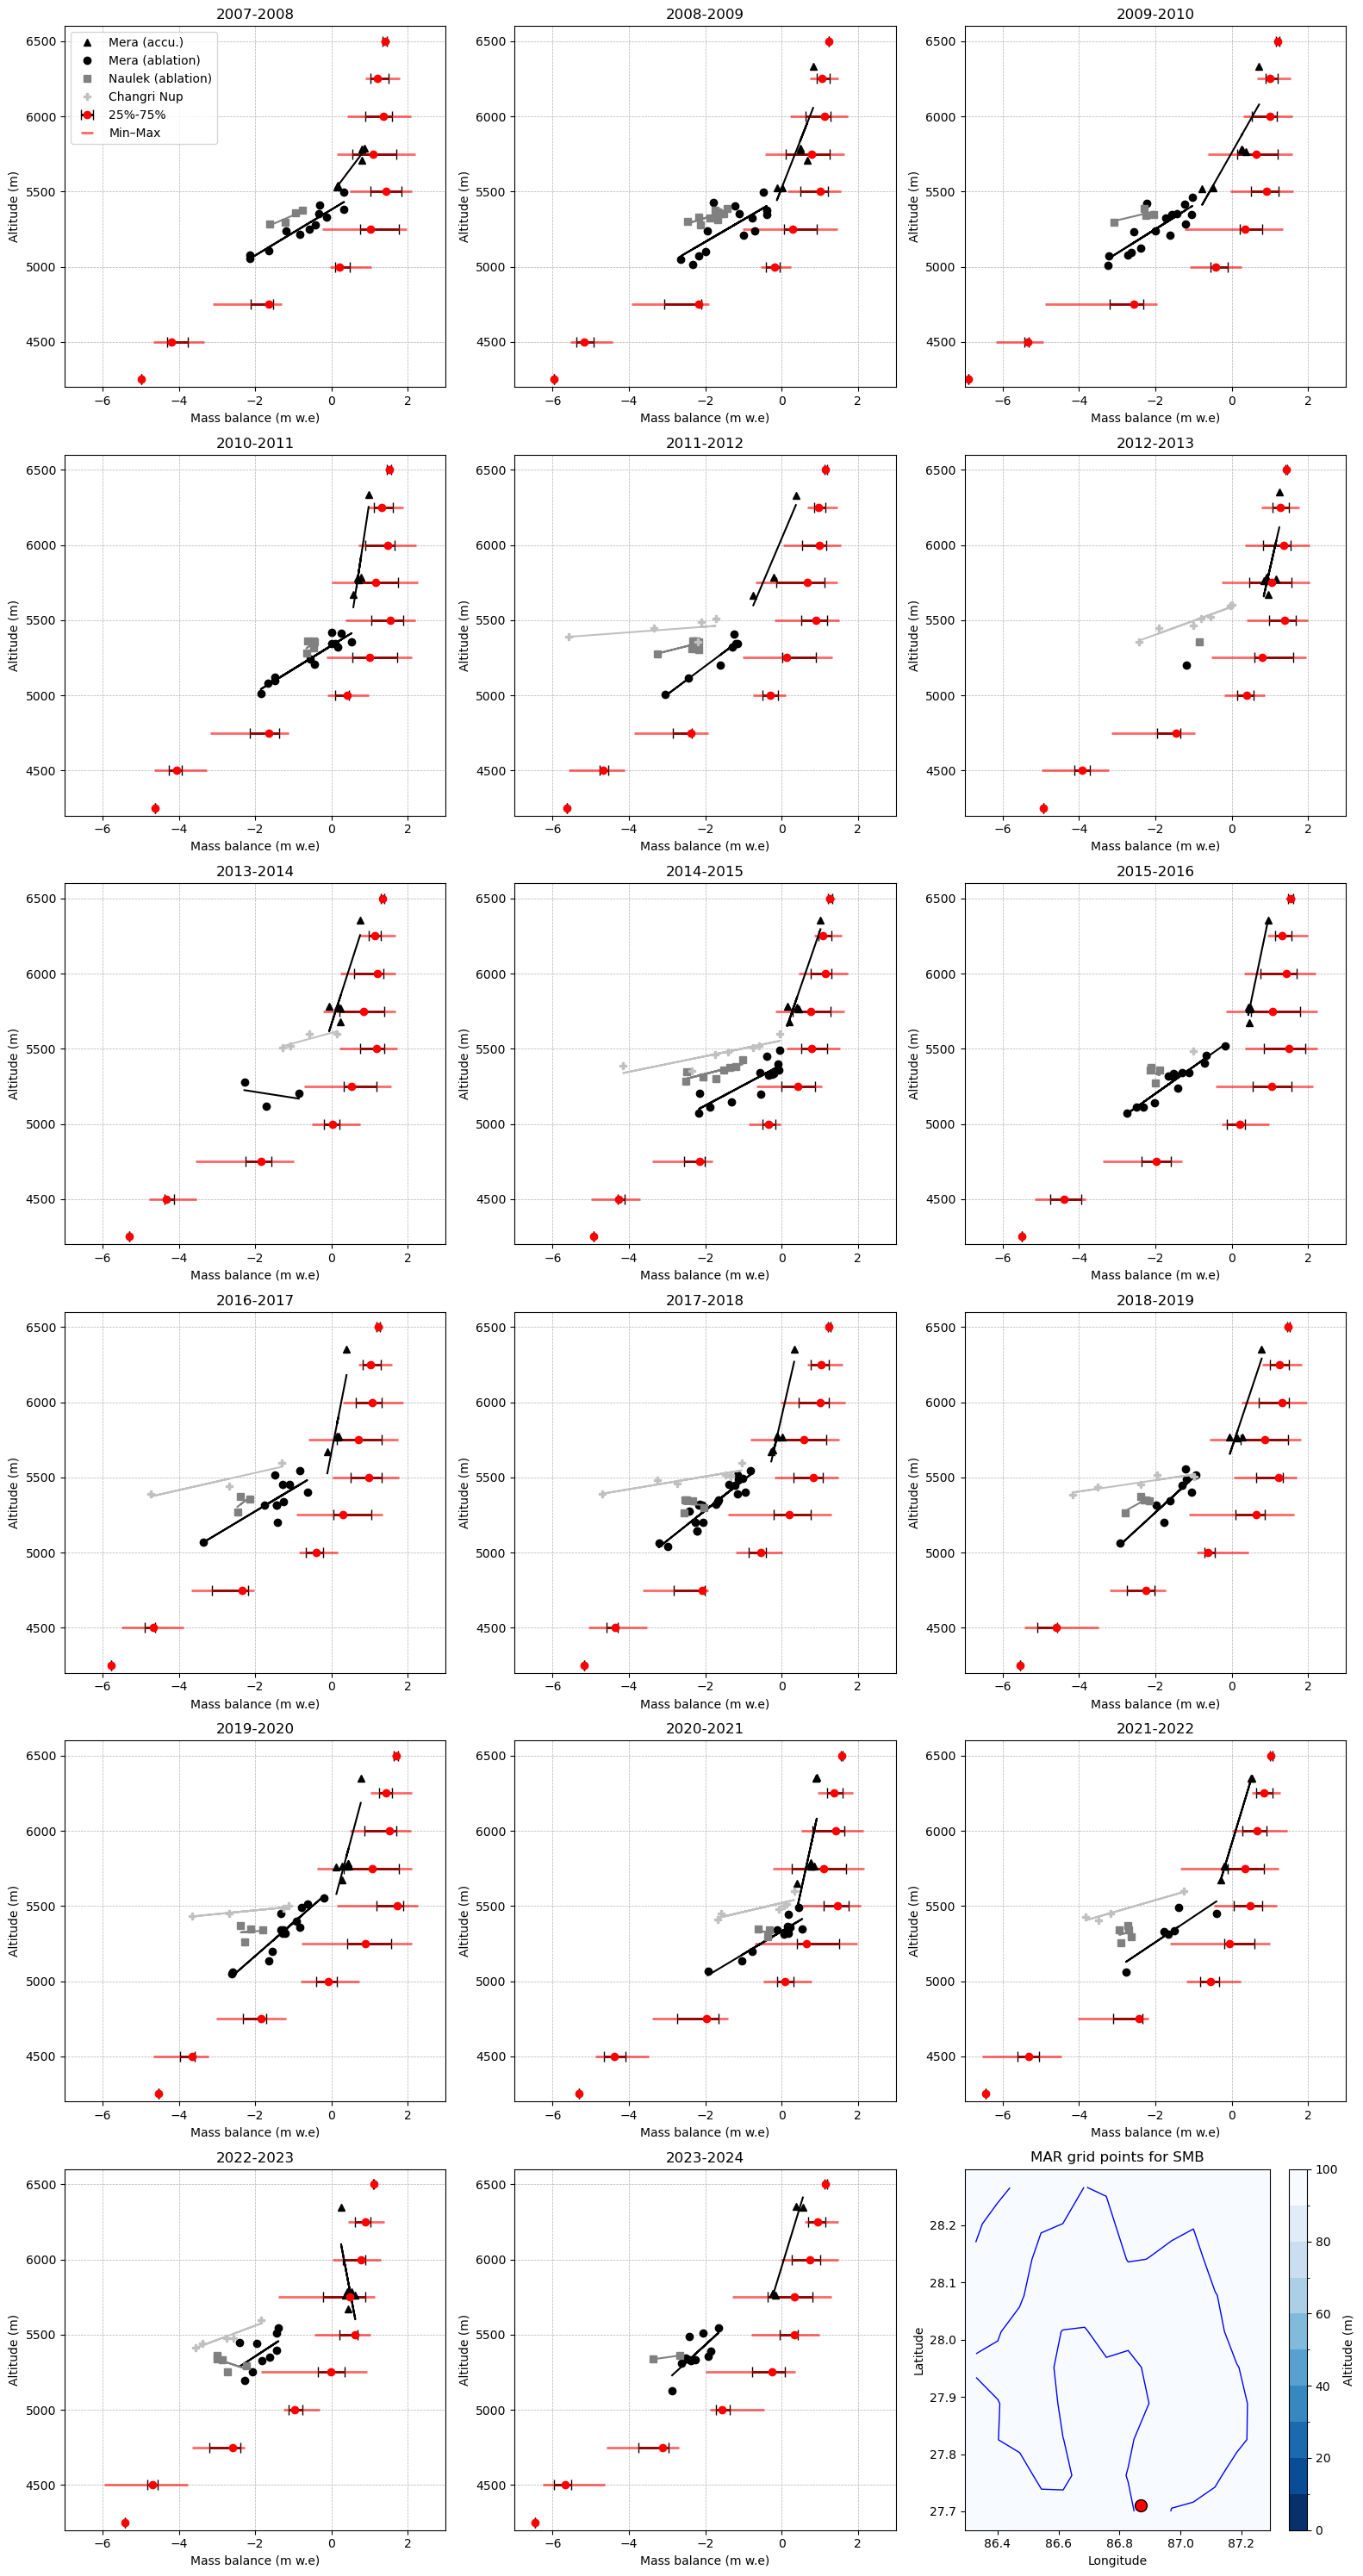

In [25]:
### Khumbu alt band

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[nyy]

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[30], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

###### Subplot filling ######
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    #### Création des classes d'altitude (pas de 250 m)
    alt_band = np.arange(125, 7000, 250)
    alt_classes = np.digitize(SH_MAR_khumbu, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

    SMB_min, SMB_max, SMB_p50, SMB_p25, SMB_p75, alt_center = [], [], [], [], [], [] # Définition des listes des percentilles, min et max de chaque classe d'alt

    for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
        # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
        m = (alt_classes == a) & (SMB_MAR_khumbu != 0) 

        smbk = SMB_MAR_khumbu[m]
        shk = SH_MAR_khumbu[m]

        if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
            continue

        p25 = np.percentile(smbk, 25)
        p50 = np.percentile(smbk, 50)   # moyenne
        p75 = np.percentile(smbk, 75)
        
        # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
        SMB_p25.append(p25)
        SMB_p50.append(p50)
        SMB_p75.append(p75)
        SMB_min.append(np.min(smbk))
        SMB_max.append(np.max(smbk))
        
        #alt_center.append(np.mean(shk))
        alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

    SMB_p25 = np.array(SMB_p25) # Transformation des listes en tableaux pour pouvoir les plot
    SMB_p50 = np.array(SMB_p50)
    SMB_p75 = np.array(SMB_p75)
    SMB_min = np.array(SMB_min)
    SMB_max = np.array(SMB_max)
    alt_center = np.array(alt_center)

    # Plot des percentilles avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
    ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_p25, SMB_p75-SMB_p50], fmt="o", color="r", ecolor="k", elinewidth=2, capsize=4, label="25%-75%")

    ax.errorbar(SMB_p50, alt_center, xerr=[SMB_p50-SMB_min, SMB_max-SMB_p50], fmt="none", ecolor="r", elinewidth=2, alpha=0.6, label="Min–Max")
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
      
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-7, 3)
    ax.set_ylim(4200, 6600) # Restriction du domaine 
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()
plt.savefig("khumbu_ice0_new_altclass.png")

In [26]:
#### Manual data loading of Mera and Changri glacier wide MB #####

Mera_MBgw = [0.15, -0.35, -0.75, 0.26, -0.90, 0.19, -0.41, -0.22, -0.42, -0.76, -0.92, -0.80, -0.49, 0.29, -0.85, -0.83, -1.28] # Annual glacier-wide (m w.e.a-1) MB 2007-2020 from Wagnon

error_annual = [0.28, 0.26, 0.24, 0.22, 0.19, 0.16, 0.16, 0.16, 0.16, 0.16, 0.16, 0.19, 0.22, 0.22, 0.22, 0.22, 0.22]
error_complet = np.full(len(Mera_MBgw), np.nan) # On rempli par des NaN les valeurs manquantes
error_complet[:len(error_annual)] = error_annual

Mera_MBgw_cum = np.cumsum(Mera_MBgw)

# Remplissage de la liste des années
years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))
    
Changri_MBgw = [-0.95, -1.73, -0.92, -1.33, -1.28, -0.75, -2.56, -2.1, -1.69, -0.83, -0.35, -2.5, -2.65, -2.31]
Changri_MBgw_full = np.full(len(years), np.nan)
start_changri = 2011
start_index = years.index(start_changri)
Changri_MBgw_full[start_index:start_index+len(Changri_MBgw)] = Changri_MBgw
Changri_MBgw_cum = np.nancumsum(Changri_MBgw_full)

n = min(len(years), len(Mera_MBgw)) # Permet de plot jusqu'à ce que la plus petite liste soit vidée

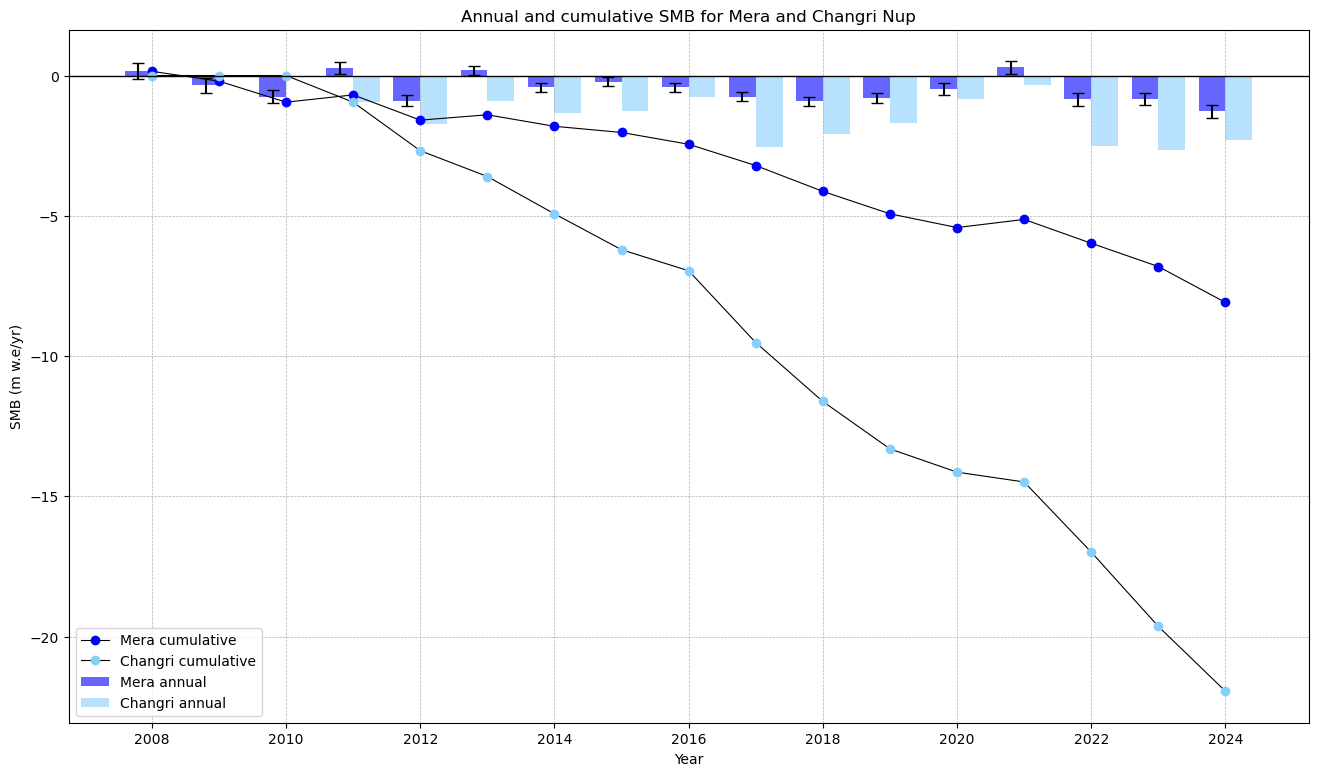

In [27]:
# Série temporelle OBS 
plt.figure(figsize=(16,9))

width = 0.4 # Largeur des barres annual
offsets = [-width/2, width/2] # Décalage des barres annual

series = [("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.6, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB for Mera and Changri Nup")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

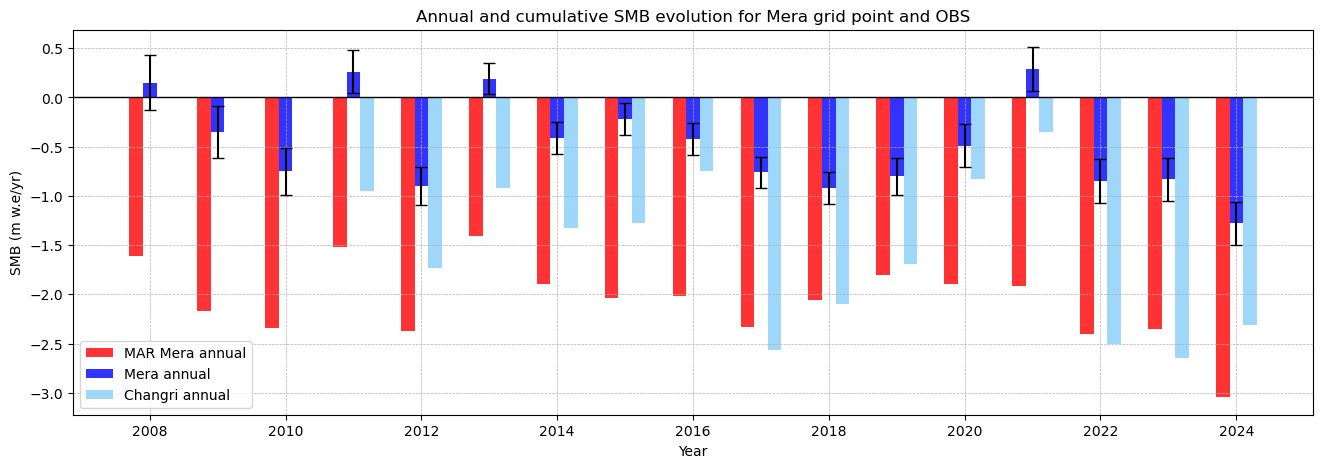

In [28]:
# Série temporelle Mera grid 
plt.figure(figsize=(16,5))

SMB_cum = np.cumsum(SMB_list_Mera)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR Mera", SMB_list_Mera, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for Mera grid point and OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

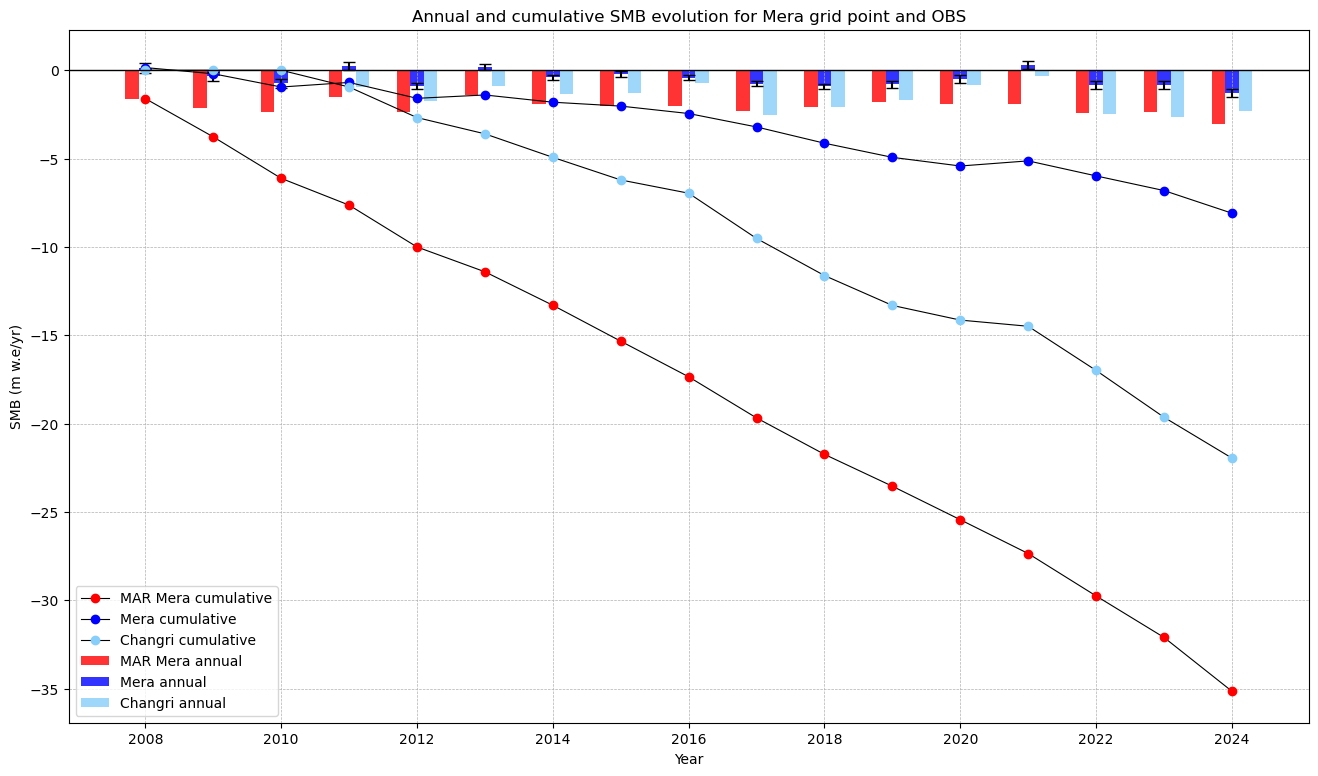

In [29]:
# Série temporelle Mera grid 
plt.figure(figsize=(16,9))

SMB_cum = np.cumsum(SMB_list_Mera)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR Mera", SMB_list_Mera, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### MAR ######
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR Mera cumulative") # Cumulative SMB
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for Mera grid point and OBS")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("Changri_timeseries.png")

Mean bias: -1.5914246634876026 m w.e/yr
RMSE: 1.6131350951561314 m w.e/yr
Relative bias (%): 14.855715048205523
Correlation: 0.8196633405047854


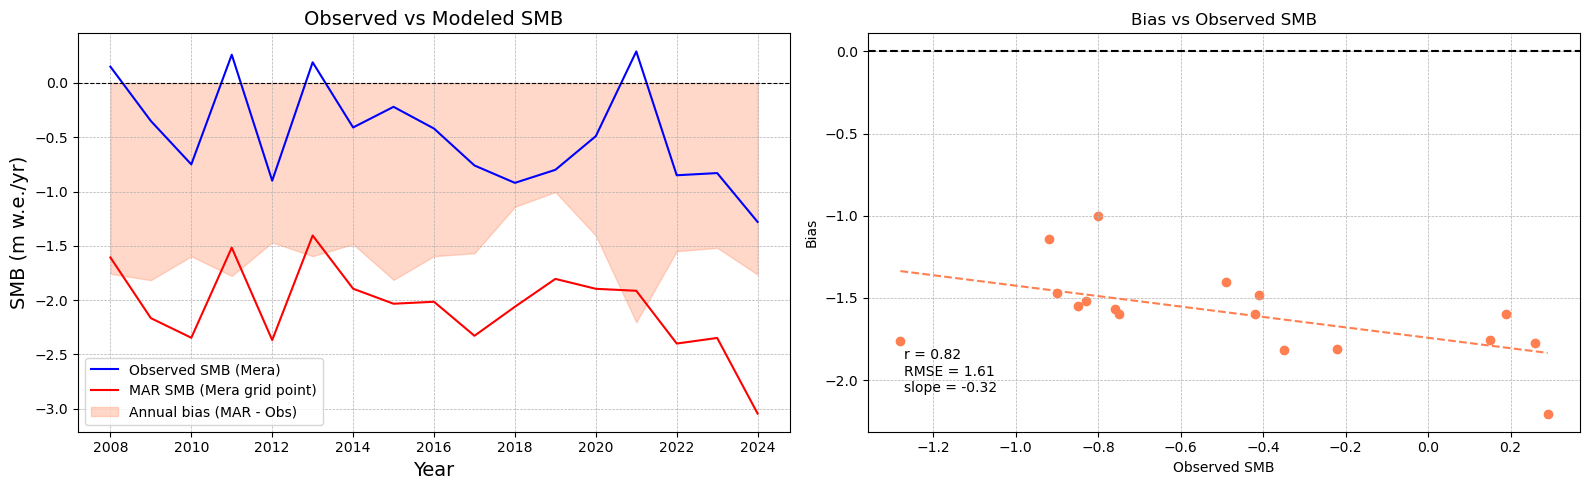

In [30]:
MAR_bias = SMB_list_Mera
obs = np.array(Mera_MBgw[:n])

########## Mean bias ##########
mean_bias = np.mean(MAR_bias - obs) 
print("Mean bias:", mean_bias, 'm w.e/yr')

######### Annual bias ##########
annual_bias = MAR_bias - obs 

########### RMSE ###############
rmse = np.sqrt(np.mean((MAR_bias - obs)**2))
print("RMSE:", rmse, 'm w.e/yr')

########## Biais relatif ############
bias_relatif = np.mean((MAR_bias - obs)/obs)*100 # Compare en % des observations et permet de comparer différentes périodes ou site
print("Relative bias (%):", bias_relatif)

########## Corrélation ###########
corr = np.corrcoef(MAR_bias, obs)[0,1] # Permet d'obtenri la corrélation entre modèle et obs, et donc indique si la variabilité inter-annuel est bien reproduite
print("Correlation:", corr)

######## Plot ########
fig, axes = plt.subplots(1, 2, figsize=(16,5)) 

ax = axes[0] # Série temporelle
ax.plot(years[:n], obs, color="blue", label="Observed SMB (Mera)")
ax.plot(years[:n], MAR_bias, color="red", label="MAR SMB (Mera grid point)")
ax.fill_between(years[:n], annual_bias, 0, color="coral", alpha=0.3, label="Annual bias (MAR - Obs)")
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("SMB (m w.e./yr)", fontsize=14)
ax.set_title("Observed vs Modeled SMB", fontsize=14)
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax.grid(linestyle='--', linewidth=0.5)
ax.legend(loc='lower left')

ax = axes[1] # Régression
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, annual_bias) # Calcul des coeff de regression linéare
ax.scatter(obs, annual_bias, color="coral") # Biais annuel selon les observation (permet de voir la tendance)
x = np.linspace(obs.min(), obs.max(), 100)   
ax.plot(x, slope*x + intercept, color="coral", linestyle='--') # Droite de régression étendue sur le min et max des observations 

ax.axhline(0, color='k', linestyle='--')
ax.set_xlabel("Observed SMB")
ax.set_ylabel("Bias")
ax.set_title("Bias vs Observed SMB")

ax.text(0.05, 0.1, f"r = {corr:.2f}\nRMSE = {rmse:.2f}\nslope = {slope:.2f}", transform=plt.gca().transAxes) # Affiche le RMSE et la corrélation sur le graph


axes[1].grid(linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig("Bias_analyse.png")
plt.show()

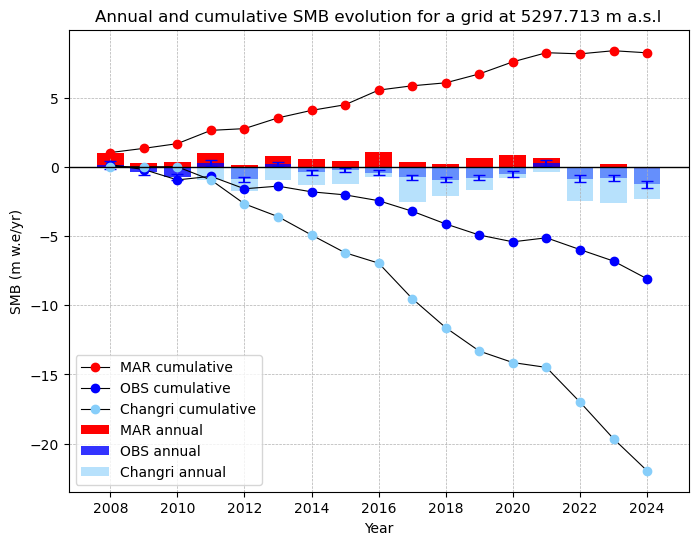

In [31]:
### Série temporelle SMB grille 3 case au nord par rapport au Mera

SMB_list = []
Ygrid, Xgrid = iY+3, iX

for j in range(nyy):
    ###### MAR_data loading and sorting  ######   
    SMB_day = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=Ygrid, X=Xgrid) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)

    SH_MAR = ds_SH.isel(y=Ygrid, x=Xgrid) # Altitude de la grille de MAR au Peak Mera (coord iYN,iXN)
    Grid_alt = SH_MAR.values

plt.figure(figsize=(8,6))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=1, width=0.8, label="MAR annual") # SMB MAR annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR cumulative") # Cumulative SMB

plt.bar(years[:n], Mera_MBgw[:n], yerr=error_complet[:n],
        color="b", alpha=0.8, width=0.8, capsize=4, ecolor="b", label="OBS annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="OBS cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

##### Changri #####
plt.bar(years[:n], Changri_MBgw_full[:n], # yerr est une fonction matplotlib qui permt d'afficher les barres d'erreur 
        color="lightskyblue", alpha=0.6, width=0.8, capsize=4, ecolor="lightskyblue", label="Changri annual") # SMB OBS annuel sous forme de bar 
plt.plot(years[:n], Changri_MBgw_cum[:n], 
         color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for a grid at "+str(Grid_alt)+" m a.s.l")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)


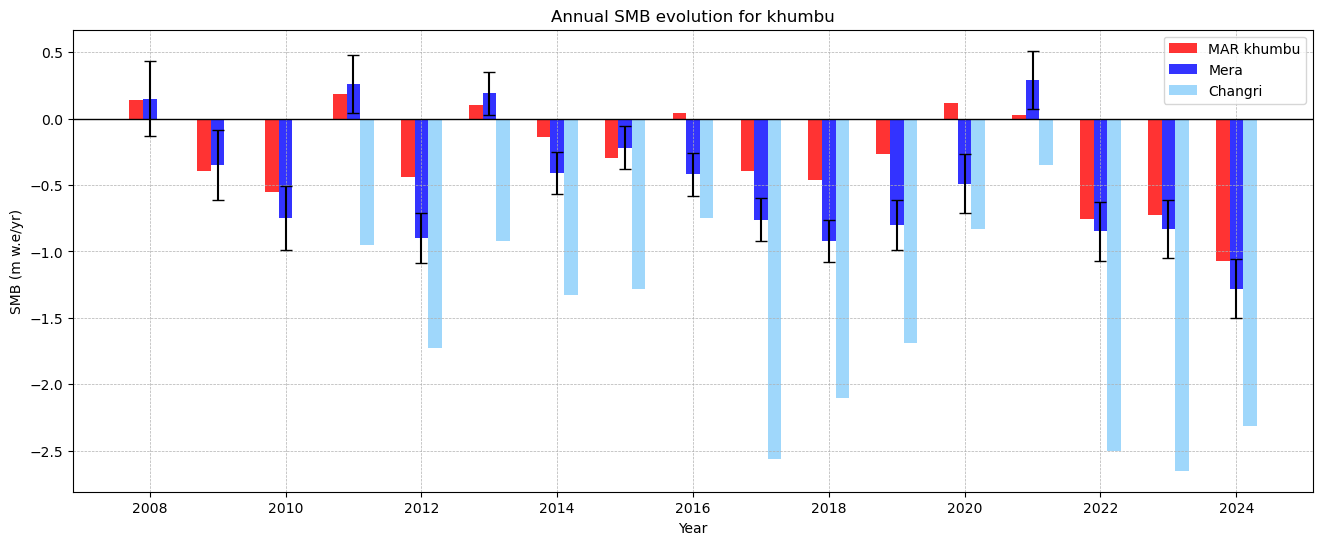

In [32]:
# Série temporelle Khumbu OBS 
plt.figure(figsize=(16,6))

SMB_cum = np.cumsum(SMB_list_khumbu)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR khumbu", SMB_list_khumbu, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR
##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name}") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)
    
plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual SMB evolution for khumbu")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("khumbu_timeseries_ice0.png")

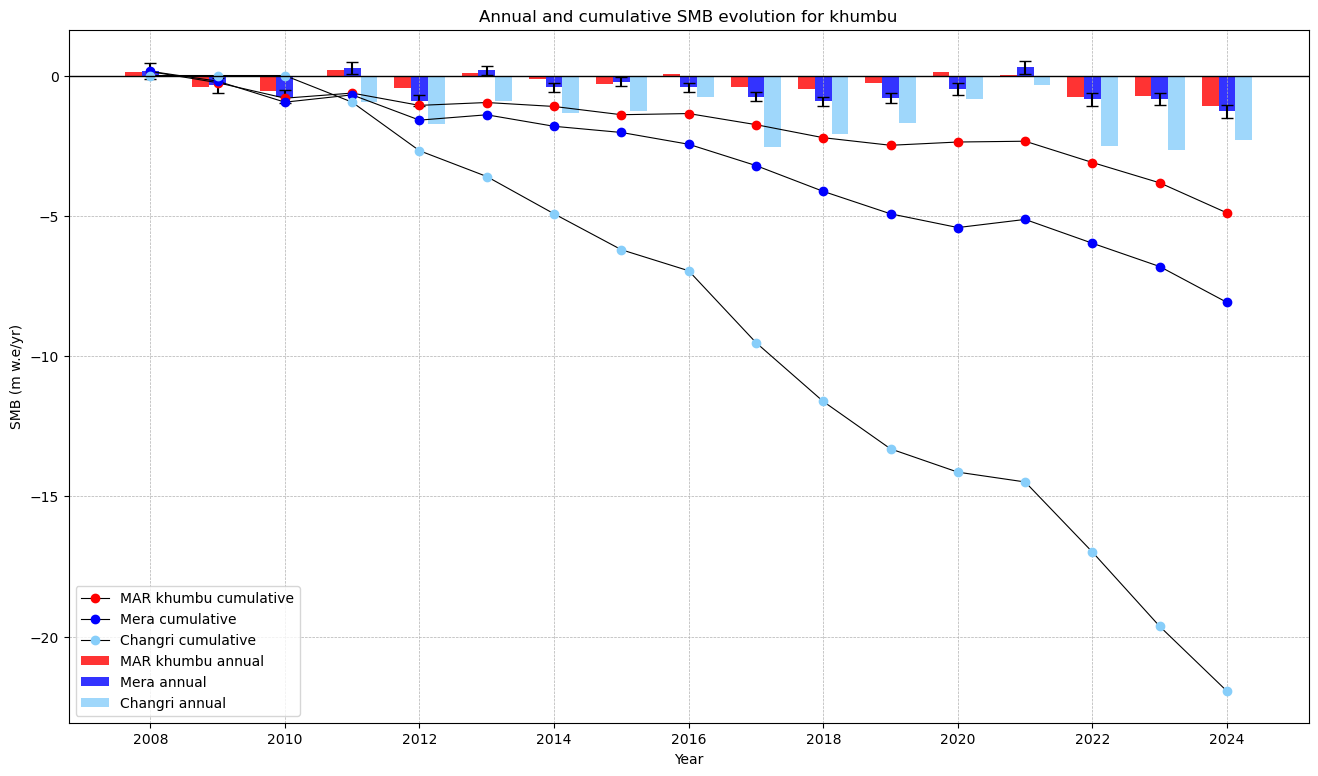

In [33]:
# Série temporelle Khumbu OBS 
plt.figure(figsize=(16,9))

SMB_cum = np.cumsum(SMB_list_khumbu)

width = 0.25 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR khumbu", SMB_list_khumbu, None, "r"),("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### MAR ######
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR khumbu cumulative") # Cumulative SMB
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for khumbu")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("khumbu_timeseries_cumul_ice0.png")

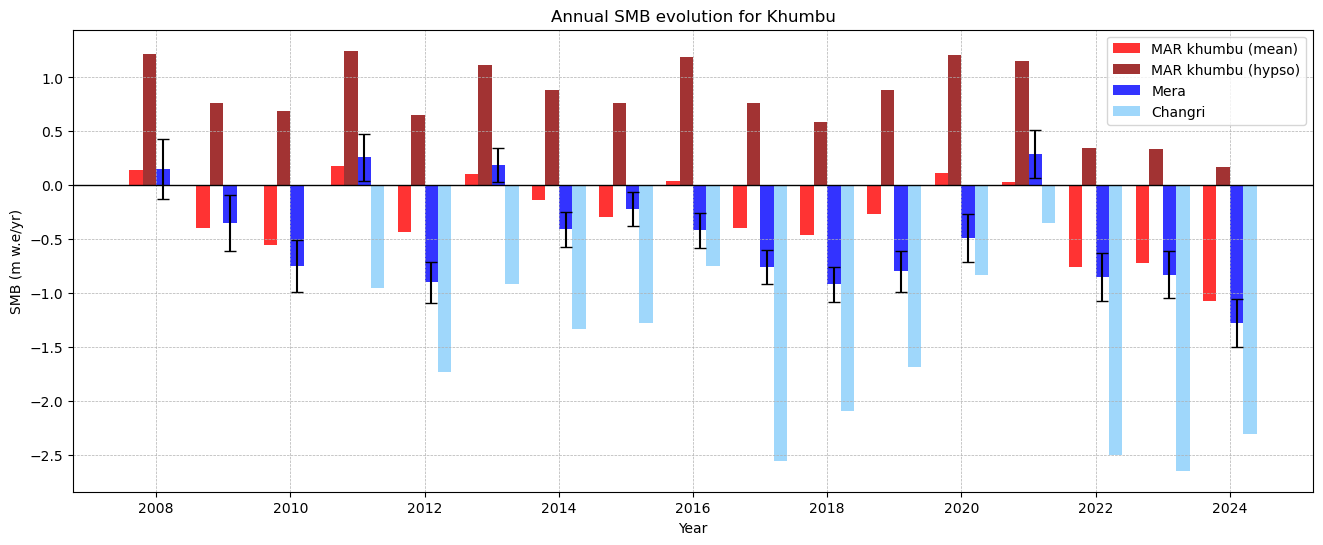

In [34]:
plt.figure(figsize=(16,6))

SMB_cum = np.cumsum(SMB_list_khumbu)
SMB_cum_hypso = np.cumsum(SMB_list_khumbu_hypso)

width = 0.20
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width] # On a ici 4 séries avec celle de l'hypso

series = [ ("MAR khumbu (mean)", SMB_list_khumbu, None, "red"), ("MAR khumbu (hypso)", SMB_list_khumbu_hypso, None, "darkred"), ("Mera", Mera_MBgw, error_complet, "blue"), ("Changri", Changri_MBgw_full, None, "lightskyblue")]

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series):
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=name)

plt.axhline(0, color="k", linewidth=1)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual SMB evolution for Khumbu")

plt.legend()
plt.grid(linestyle='--', linewidth=0.5)

plt.savefig("khumbu_timeseries_ice0_hypso.png")

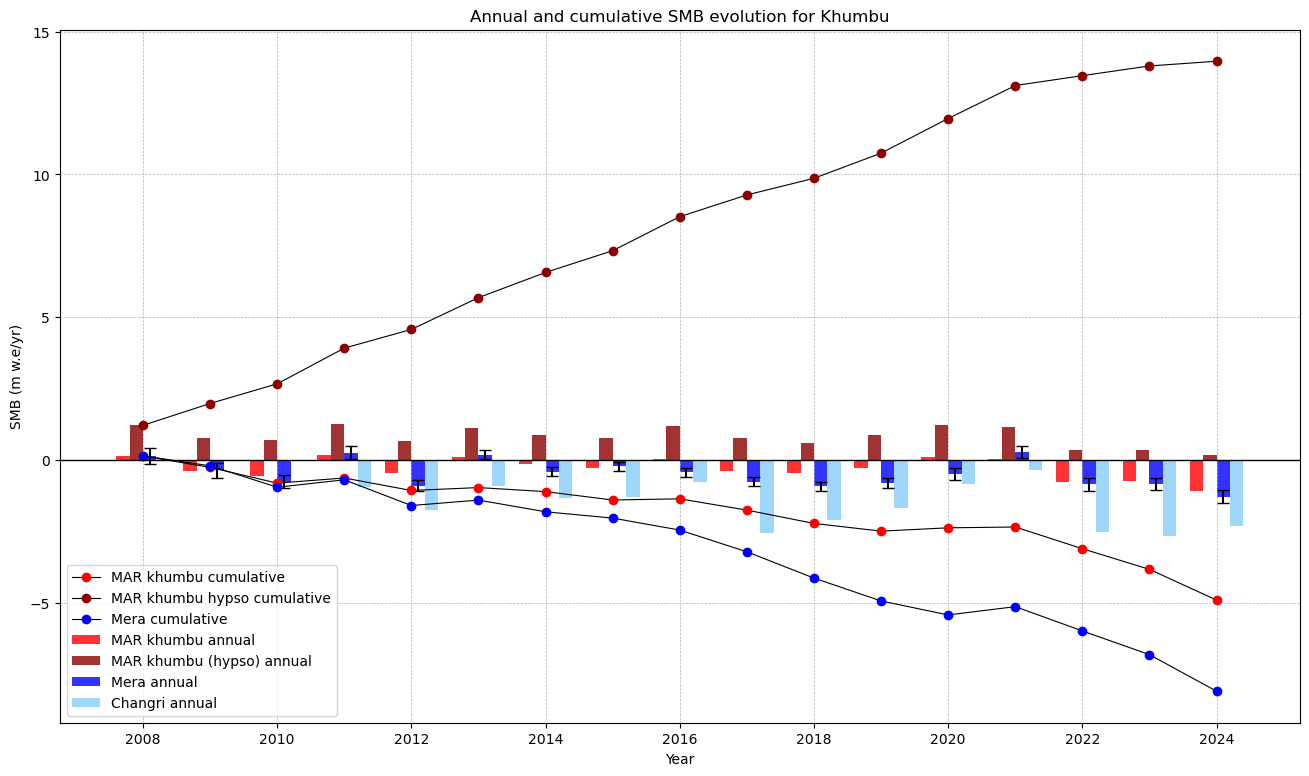

In [35]:
plt.figure(figsize=(16,9))

SMB_cum = np.cumsum(SMB_list_khumbu)
SMB_cum_hypso = np.cumsum(SMB_list_khumbu_hypso)

width = 0.20
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

series = [("MAR khumbu", SMB_list_khumbu, None, "r"), ("MAR khumbu (hypso)", SMB_list_khumbu_hypso, None, "darkred"), ("Mera", Mera_MBgw, error_complet, "b"), ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)


##### Cumulative ######
##### MAR Mean ######
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r", label="MAR khumbu cumulative") # Cumulative SMB
##### MAR hypso ######
plt.plot(years, SMB_cum_hypso, color="black", linewidth=0.8, marker="o", markerfacecolor="darkred", markeredgecolor="darkred", label="MAR khumbu hypso cumulative")
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution for Khumbu")

plt.legend()
plt.grid(linestyle='--', linewidth=0.5)

plt.savefig("khumbu_timeseries_cumul_ice0_hypso.png")

# Quantification du biais (MAR_khumbu_hypso)

Mean bias: 1.2971307693083063 m w.e/yr
RMSE: 1.3250929836992966 m w.e/yr
Standard deviation: 0.27078253777292527


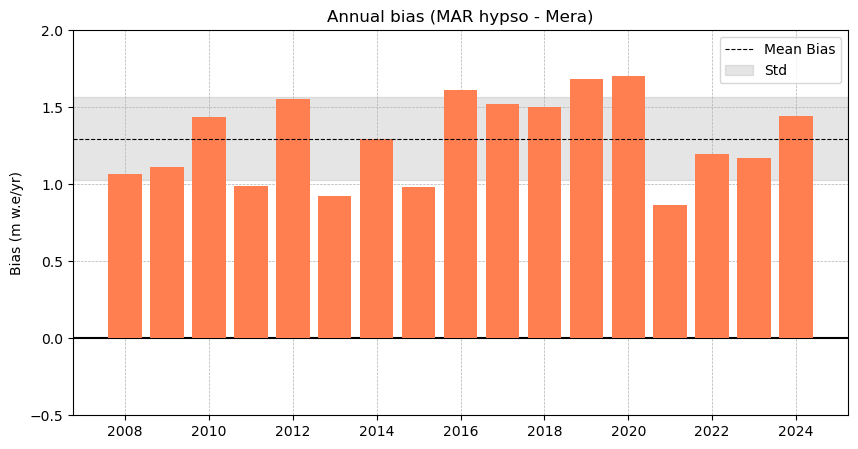

In [36]:
###### Quantification du biais annuel et moyen #######
plt.figure(figsize=(10,5))

mar_hypso = np.array(SMB_list_khumbu_hypso[:n])
obs = np.array(Mera_MBgw[:n])

annual_bias = mar_hypso - obs # Biais sur chaque année

mean_bias = np.mean(annual_bias) # Biais moyen sur toute la période
print("Mean bias:", mean_bias, 'm w.e/yr')

rmse = np.sqrt(np.mean((mar_hypso - obs)**2))
print("RMSE:", rmse, 'm w.e/yr')

std = np.std(annual_bias)
print("Standard deviation:", std)

plt.bar(years[:n], annual_bias, color="coral", zorder=3)
plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.2, label="Std")
plt.axhline(0, color="k")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.title("Annual bias (MAR hypso - Mera)")
plt.legend()
plt.ylabel("Bias (m w.e/yr)")
plt.ylim(-0.5,2)
plt.grid(linestyle='--', linewidth=0.5, zorder=0)
plt.savefig("mar-obs_hypso.png")

In [37]:
##### Biais relatif ######
bias_relatif = np.mean((mar_hypso - obs)/obs)*100 # Compare en % des observations et permet de comparer différentes périodes ou site
print("Relative bias (%):", bias_relatif)

##### Corrélation #####
corr = np.corrcoef(mar_hypso, obs)[0,1] # Permet d'obtenri la corrélation entre modèle et obs, et donc indique si la variabilité inter-annuel est bien reproduite
print("Correlation:", corr)

Relative bias (%): -74.6676157287416
Correlation: 0.8151535580258549


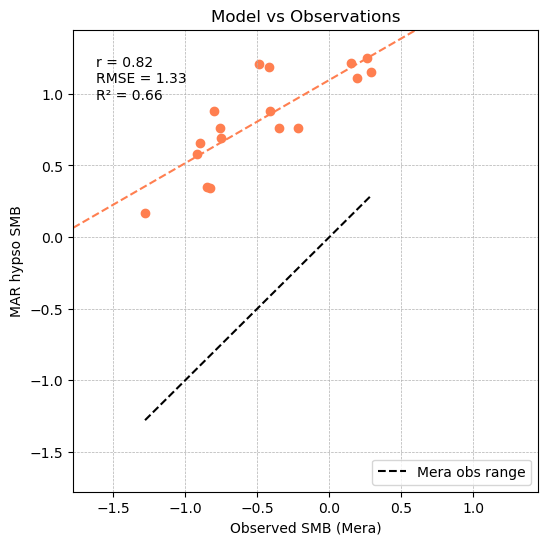

In [38]:
#### Régression linéaire Obs et Modèle ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, mar_hypso)

plt.figure(figsize=(6,6))
plt.scatter(obs, mar_hypso, color="coral")
lims = [min(obs.min()-0.5, mar_hypso.min()-0.5), max(obs.max()+0.2, mar_hypso.max()+0.2)]
plt.xlim(lims)
plt.ylim(lims)
coef = np.polyfit(obs, mar_hypso, 1)
x = np.linspace(*lims, 100)
plt.plot(x, coef[0]*x + coef[1], color="coral", linestyle='--')

plt.plot([obs.min(), obs.max()], [obs.min(), obs.max()], 'k--', label="Mera obs range")
plt.xlabel("Observed SMB (Mera)")
plt.ylabel("MAR hypso SMB")

plt.text(0.05, 0.85, f"r = {corr:.2f}\nRMSE = {rmse:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # Affiche le RMSE et la corrélation sur le graph

plt.title("Model vs Observations")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.savefig("model_vs_obs_hypso.png")

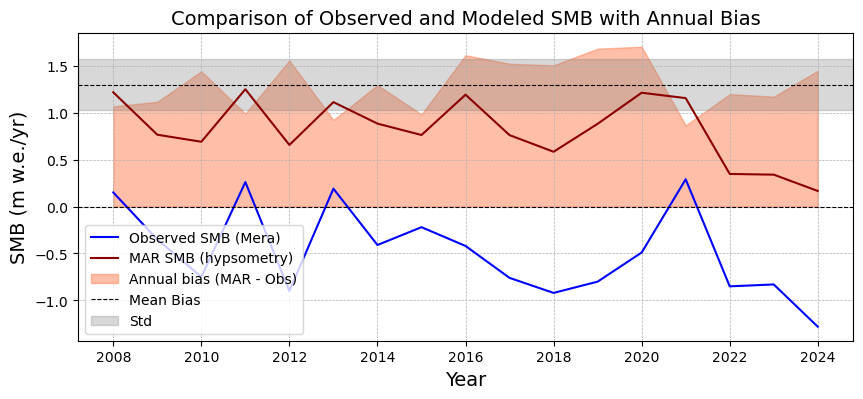

In [39]:
plt.figure(figsize=(10,4))

plt.plot(years[:n], obs, color="blue", label="Observed SMB (Mera)")
plt.plot(years[:n], mar_hypso, color="darkred", label="MAR SMB (hypsometry)")
plt.fill_between(years[:n], annual_bias, 0, color="coral", alpha=0.5, label="Annual bias (MAR - Obs)")
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.title("Comparison of Observed and Modeled SMB with Annual Bias", fontsize=14)
plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.3, label="Std")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')
plt.savefig("annual_bias_hypso.png")

In [40]:
extreme = np.abs(obs) > np.percentile(np.abs(obs), 75)

print("Bias extreme years:", np.mean(annual_bias[extreme])) # Valeur du biais pour les 75% de valeur les plus extrêmes
print("Bias normal years:", np.mean(annual_bias[~extreme])) # Valeur du biais pour les valeurs moins extrêmes
### On voit une faible différence entre le biais pour toutes les valeurs, ou sans les extrêmes

Bias extreme years: 1.4251657559211988
Bias normal years: 1.2577353888120315


Slope: -0.4190971562040782
Correlation (r): -0.7124497185658178
R²: 0.507584601484513
p_value: 0.0013309594087146737


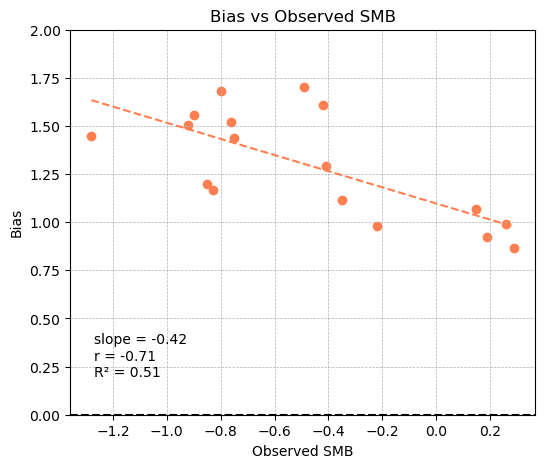

In [41]:
#### Régression linéaire du biais selon les obs ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, annual_bias)

# Toutes les valeurs associée à la régression linéaire
print("Slope:", slope)
print("Correlation (r):", r_value)
print("R²:", r_value**2)
print("p_value:", p_value)

plt.figure(figsize=(6,5))

plt.scatter(obs, annual_bias, color="coral")
x = np.linspace(obs.min(), obs.max(), 100)
plt.plot(x, slope*x + intercept, color="coral", linestyle='--')

plt.axhline(0, color='k', linestyle='--')
plt.ylim(0,2)
plt.xlabel("Observed SMB")
plt.ylabel("Bias")
plt.title("Bias vs Observed SMB")

plt.text(0.05, 0.1, f"slope = {slope:.2f}\nr = {r_value:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # affichage valeurs sur le plot
plt.grid(linestyle='--', linewidth=0.5)
plt.savefig("bias_vs_observed_SMB.png")

# Quantification du biais (MAR_khumbu_mean)

Mean bias: 0.18769834312007708 m w.e/yr
RMSE: 1.3250929836992966 m w.e/yr
Standard deviation: 0.27078253777292527


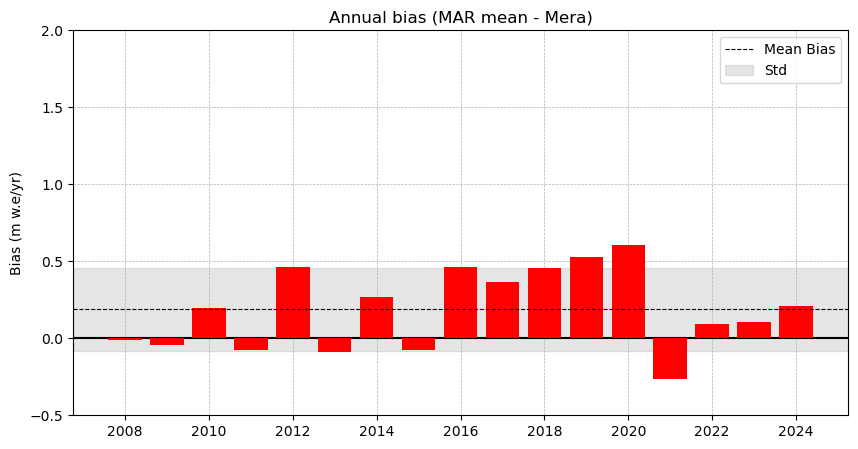

In [42]:
###### Quantification du biais annuel et moyen #######
plt.figure(figsize=(10,5))

mar_mean = np.array(SMB_list_khumbu[:n])
obs = np.array(Mera_MBgw[:n])

mean_bias = np.mean(mar_mean - obs) # Biais moyen sur toute la période
print("Mean bias:", mean_bias, 'm w.e/yr')

rmse = np.sqrt(np.mean((mar_hypso - obs)**2))
print("RMSE:", rmse, 'm w.e/yr')

std = np.std(annual_bias)
print("Standard deviation:", std)

annual_bias = mar_mean - obs # Biais sur chaque année
plt.bar(years[:n], annual_bias, color="red", zorder=3)
plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.2, label="Std")
plt.axhline(0, color="k")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.title("Annual bias (MAR mean - Mera)")
plt.legend()
plt.ylabel("Bias (m w.e/yr)")
plt.ylim(-0.5,2)
plt.grid(linestyle='--', linewidth=0.5, zorder=0)
plt.savefig("mar-obs_mean.png")

In [43]:
rmse = np.sqrt(np.mean((mar_mean - obs)**2))
print("RMSE:", rmse, 'm w.e/yr')

RMSE: 0.3141221529147363 m w.e/yr


In [44]:
##### Biais relatif ######
bias_relatif = np.mean((mar_mean - obs)/obs)*100 # Compare en % des observations et permet de comparer différentes périodes ou site
print("Relative bias (%):", bias_relatif)

##### Corrélation #####
corr = np.corrcoef(mar_mean, obs)[0,1] # Permet d'obtenri la corrélation entre modèle et obs, et donc indique si la variabilité inter-annuel est bien reproduite
print("Correlation:", corr)

Relative bias (%): -41.53821240454687
Correlation: 0.8400753797120922


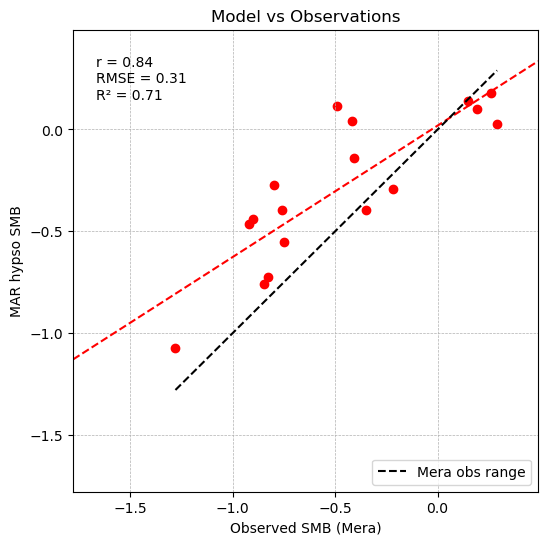

In [45]:
#### Régression linéaire Obs et Modèle ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, mar_mean)

plt.figure(figsize=(6,6))
plt.scatter(obs, mar_mean, color="red")
lims = [min(obs.min()-0.5, mar_mean.min()-0.5), max(obs.max()+0.2, mar_mean.max()+0.2)]
plt.xlim(lims)
plt.ylim(lims)
coef = np.polyfit(obs, mar_mean, 1)
x = np.linspace(*lims, 100)
plt.plot(x, coef[0]*x + coef[1], color="red", linestyle='--')

plt.plot([obs.min(), obs.max()], [obs.min(), obs.max()], 'k--', label="Mera obs range")
plt.xlabel("Observed SMB (Mera)")
plt.ylabel("MAR hypso SMB")

plt.text(0.05, 0.85, f"r = {corr:.2f}\nRMSE = {rmse:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # Affiche le RMSE et la corrélation sur le graph

plt.title("Model vs Observations")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.savefig("model_vs_obs_mean.png")

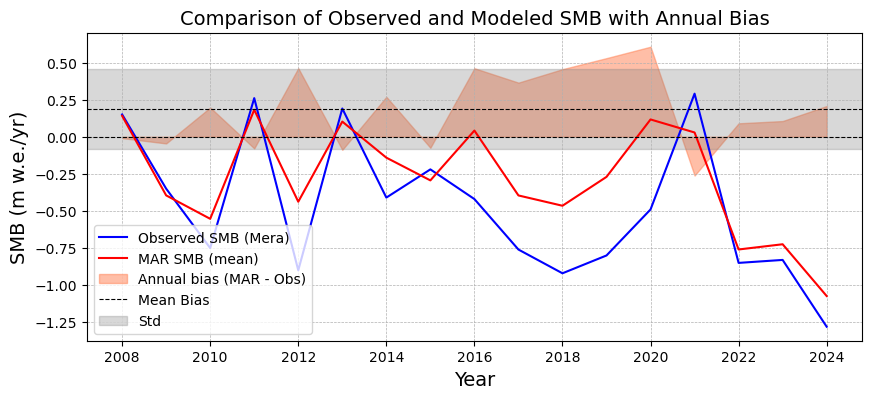

In [46]:
plt.figure(figsize=(10,4))

plt.plot(years[:n], obs, color="blue", label="Observed SMB (Mera)")
plt.plot(years[:n], mar_mean, color="red", label="MAR SMB (mean)")
plt.fill_between(years[:n], annual_bias, 0, color="coral", alpha=0.5, label="Annual bias (MAR - Obs)")
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.title("Comparison of Observed and Modeled SMB with Annual Bias", fontsize=14)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.3, label="Std")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')
plt.savefig("annual_bias_mean.png")

In [47]:
extreme = np.abs(obs) > np.percentile(np.abs(obs), 75)

print("Bias extreme years:", np.mean(annual_bias[extreme])) # Valeur du biais pour les 75% de valeur les plus extrêmes
print("Bias normal years:", np.mean(annual_bias[~extreme])) # Valeur du biais pour les valeurs moins extrêmes
### On voit une faible différence entre le biais pour toutes les valeurs, ou sans les extrêmes

Bias extreme years: 0.3035521015524864
Bias normal years: 0.15205103283318186


Slope: -0.35444408534896604
Correlation (r): -0.6477676549354546
R²: 0.4196029347805782
p_value: 0.004928337559991933


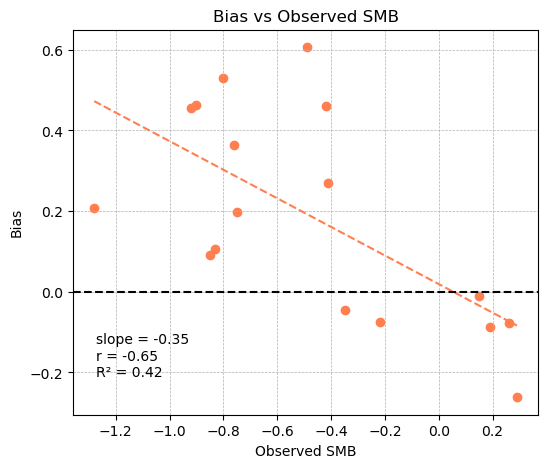

In [48]:
#### Régression linéaire du biais selon les obs ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, annual_bias)

# Toutes les valeurs associée à la régression linéaire
print("Slope:", slope)
print("Correlation (r):", r_value)
print("R²:", r_value**2)
print("p_value:", p_value)

plt.figure(figsize=(6,5))

plt.scatter(obs, annual_bias, color="coral")
x = np.linspace(obs.min(), obs.max(), 100)
plt.plot(x, slope*x + intercept, color="coral", linestyle='--')

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Observed SMB")
plt.ylabel("Bias")
plt.title("Bias vs Observed SMB")

plt.text(0.05, 0.1, f"slope = {slope:.2f}\nr = {r_value:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # affichage valeurs sur le plot
plt.grid(linestyle='--', linewidth=0.5)
plt.savefig("bias_obs_mean.png")

# Quantification et correction biais par bande d'alt

Alt: 5000
Mean bias for alt: 2.28293008418031
RMSE: 2.308543377227741 m w.e/yr

Alt: 5250
Mean bias for alt: 2.1057829828682766
RMSE: 2.1513407002456653 m w.e/yr

Alt: 5500
Mean bias for alt: 1.829193626402855
RMSE: 1.8749579604893363 m w.e/yr

Alt: 5750
Mean bias for alt: 0.3641239214263737
RMSE: 0.46060435687304674 m w.e/yr

Alt: 6250
Mean bias for alt: 0.4503141799388961
RMSE: 0.4906518174925959 m w.e/yr



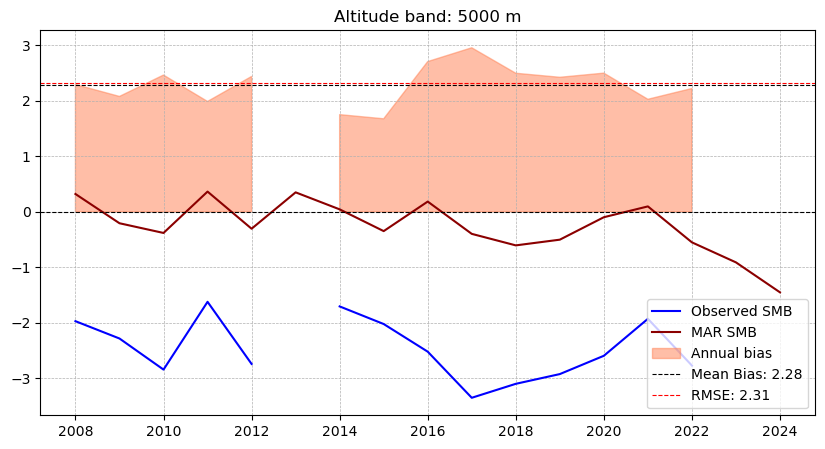

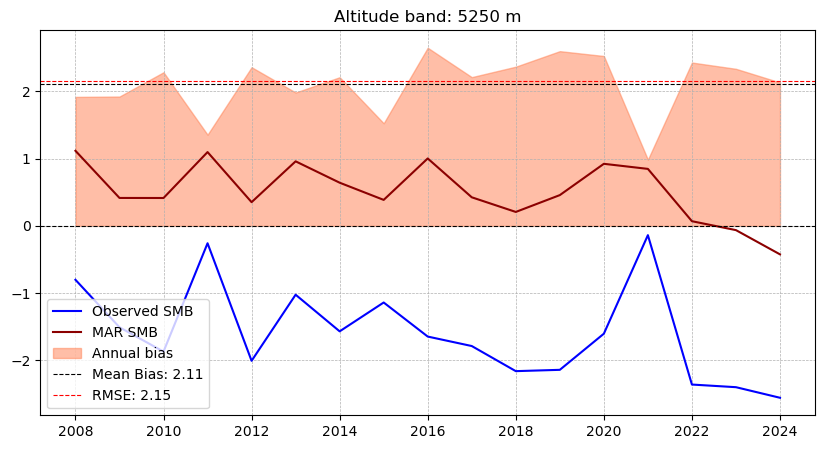

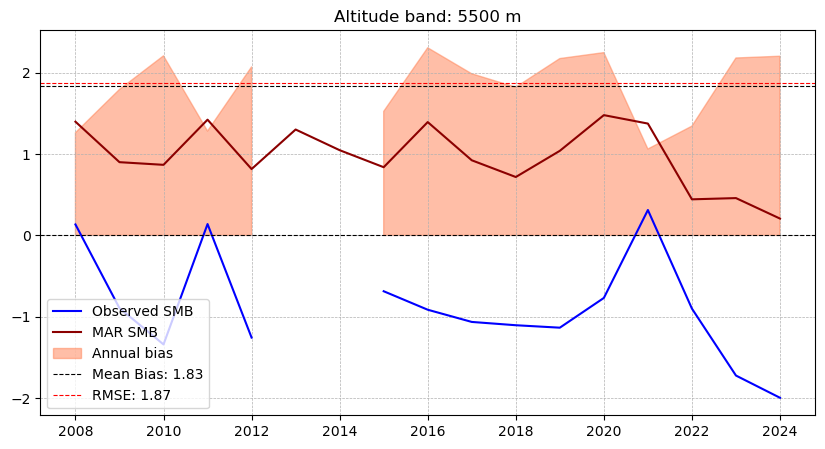

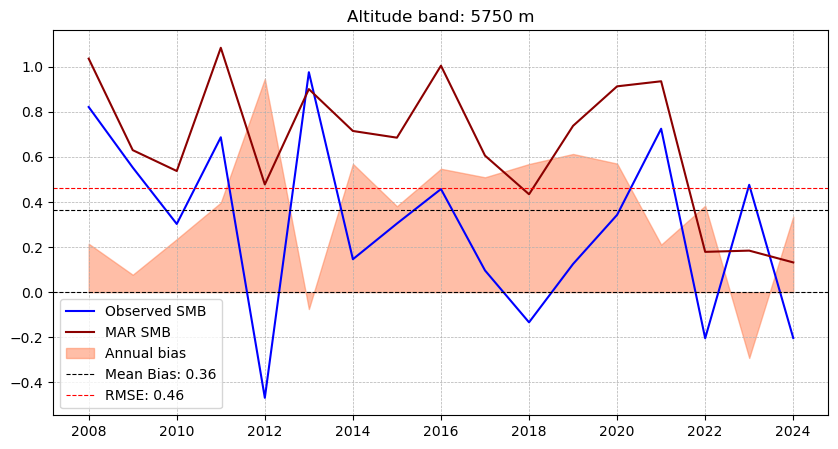

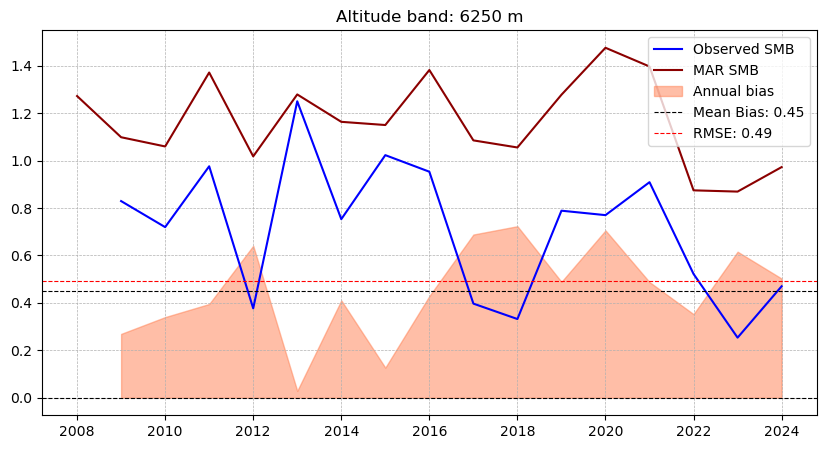

In [97]:
########### Reconstruction propre (avec NaN) ###########
years = years[:nyy]   # timeline complète
MAR_by_alt = {}
OBS_by_alt = {}

alts_valid = []
bias_mean_valid = []

# Initialisation : toutes les altitudes possibles
all_alts = alt_center_global

# Initialisation avec NaN
for alt in all_alts:
    MAR_by_alt[alt] = np.full(len(years), np.nan)
    OBS_by_alt[alt] = np.full(len(years), np.nan)

########### Remplissage ###########
for j in range(nyy):
    
    alt_mar = SMB_MAR_mean_alt_all[j]["alt"]
    mean_mar = SMB_MAR_mean_alt_all[j]["mean"]

    alt_obs = SMB_OBS_mean_alt_all[j]["alt"]
    mean_obs = SMB_OBS_mean_alt_all[j]["mean"]

    for i, alt in enumerate(alt_mar):
        MAR_by_alt[alt][j] = mean_mar[i]

    for i, alt in enumerate(alt_obs):
        OBS_by_alt[alt][j] = mean_obs[i]

########### Plot ###########
for alt in all_alts:

    mar_series = MAR_by_alt[alt]
    obs_series = OBS_by_alt[alt]
    valid = ~np.isnan(mar_series) & ~np.isnan(obs_series)     # On garde seulement les points où les deux existent

    if np.sum(valid) < 2:
        continue  # pas assez de points pour un plot
        
    years_plot = np.array(years)

    annual_bias = mar_series - obs_series
    valid_bias = ~np.isnan(annual_bias)

    mean_bias = np.mean(annual_bias[valid_bias])
    std = np.std(annual_bias[valid_bias])
    rmse = np.sqrt(np.mean((annual_bias[valid_bias])**2))

    alts_valid.append(alt)
    bias_mean_valid.append(mean_bias)
    
    print('Alt:', alt)    
    print('Mean bias for alt:', mean_bias)
    print("RMSE:", rmse, 'm w.e/yr') 
    print()

    std = np.std(annual_bias)

    plt.figure(figsize=(10,5))

    plt.plot(years_plot, obs_series, color="blue", label="Observed SMB")
    plt.plot(years_plot, mar_series, color="darkred", label="MAR SMB")

    plt.fill_between(years_plot, annual_bias, 0, color="coral", alpha=0.5, label="Annual bias")

    plt.title(f"Altitude band: {int(alt)} m")

    plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, label=f"Mean Bias: {mean_bias:.2f}")
    plt.axhline(rmse, color="r", linestyle='--', linewidth=0.8, label=f"RMSE: {rmse:.2f}")
    plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

    plt.grid(linestyle='--', linewidth=0.5)
    plt.legend()

    plt.savefig(f"annual_bias_alt_{int(alt)}.png")

[5000 5100 5200 5300 5400 5500 5600 5700 5800 5900 6000 6100 6200 6300
 6400 6500]


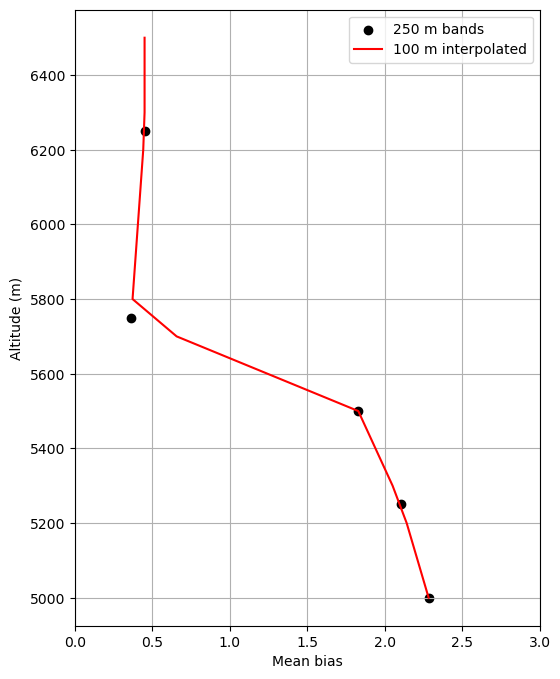

In [98]:
############ Interpolation ##########
alt_100m = np.arange(np.min(alts_valid), np.max(alts_valid)+300, 100) # On définit les bandes de 100m d'alt, et force avec +300 à atteindre 6500m
print(alt_100m)

bias_interp = np.interp(alt_100m, alts_valid, bias_mean_valid) # Interpolation sur des bandes de 100m

##### Plot ######
plt.figure(figsize=(6,8))

plt.scatter(bias_mean_valid, alts_valid, label="250 m bands", color="k")
plt.plot(bias_interp, alt_100m, label="100 m interpolated", color="red")
#print(bias_interp)

plt.ylabel("Altitude (m)")
plt.xlabel("Mean bias")
plt.xlim(0,3)
plt.legend()
plt.grid()
plt.savefig('altbias_interpolation.png')

2023-11-11 12:30:22.948675960 2024-11-27 12:31:44.151683480
2023-11-12T12:00:00.000000000 2024-11-27T12:00:00.000000000


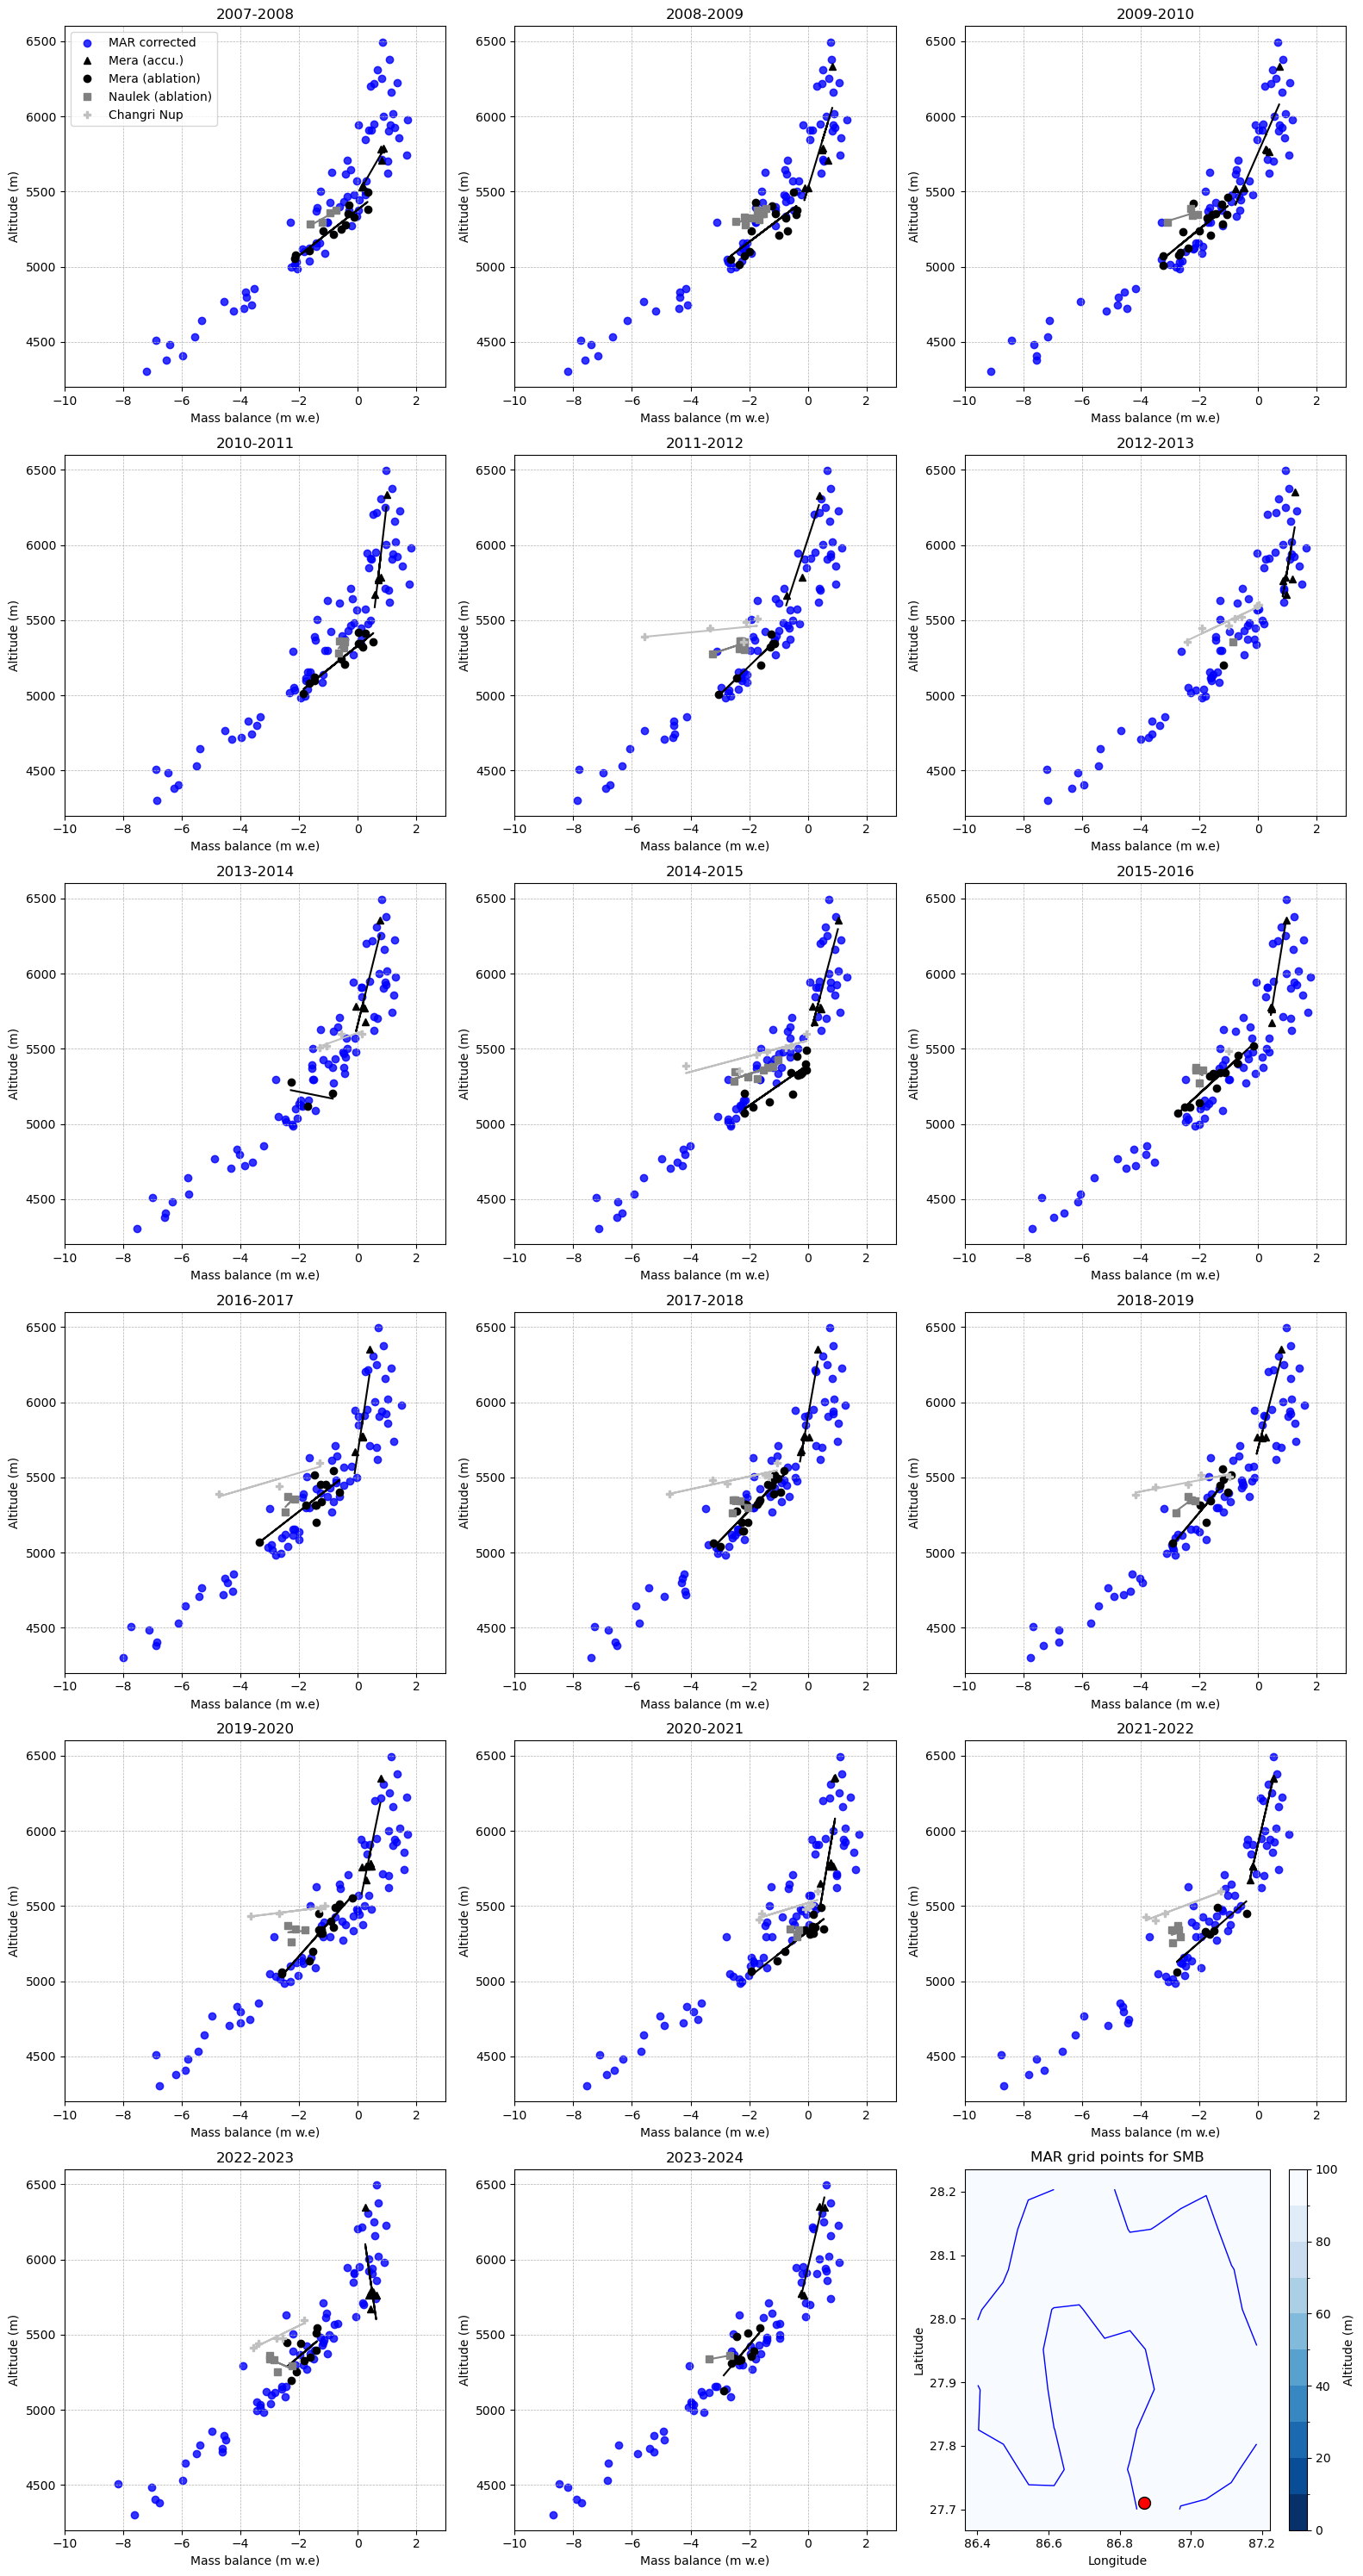

In [51]:
### Sert uniquement à visualiser la correction du biais en altitude sur chaque point de grille 

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_khumbu, SMB_hypso_corr = [], []

####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[30], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    # Cette ligne créer bien une liste de valeur de biais associés à chaque point de grille
    bias_points = np.interp(SH_MAR_khumbu, alt_100m, bias_interp) # Interpolation du biais pour chaque point de grille en fct de leur altitude
    
    SMB_MAR_khumbu_corr = SMB_MAR_khumbu - bias_points # Correction du SMB de chaque points de grille

    ############ Hypsometry ###############
    df_mar = pd.DataFrame({"SMB": SMB_MAR_khumbu_corr, "Elevation": SH_MAR_khumbu}) # Création d'un data frame pour les points de MAR

    df_mar["elev_bin"] = (df_mar["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band = df_mar.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge = pd.merge(df_mar_band, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge["SMB_weighted"] = df_merge["SMB"]*df_merge["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_weighted_corr = df_merge["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_hypso_corr.append(SMB_weighted_corr)
    #########################################
    
    # Prepare les données pour les plot en série temporelle (ici on retire les valeurs de SMB=0)
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    SMB_list_khumbu.append(SMB_regional)
    
    #ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", alpha=0.4, label="MAR") # Affiche les points de MAR correspondant à la date des obs
    ax.scatter(SMB_MAR_khumbu_corr, SH_MAR_khumbu, color="blue", alpha=0.8, label="MAR corrected") # Points de MAR corrigés en altitude
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-10, 3)
    ax.set_ylim(4200, 6600) # Restriction du domaine 
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
plt.tight_layout()
plt.savefig("khumbu_SMB_corrected.png")

print(date_ref[j], date_obs[j])
print(SMB_day_khumbu.TIME.min().values, SMB_day_khumbu.TIME.max().values) # Vérification de la période prise en compte par MAR
#print(SMB_list_khumbu)

# Extension de la période (correction du biais en altitude)

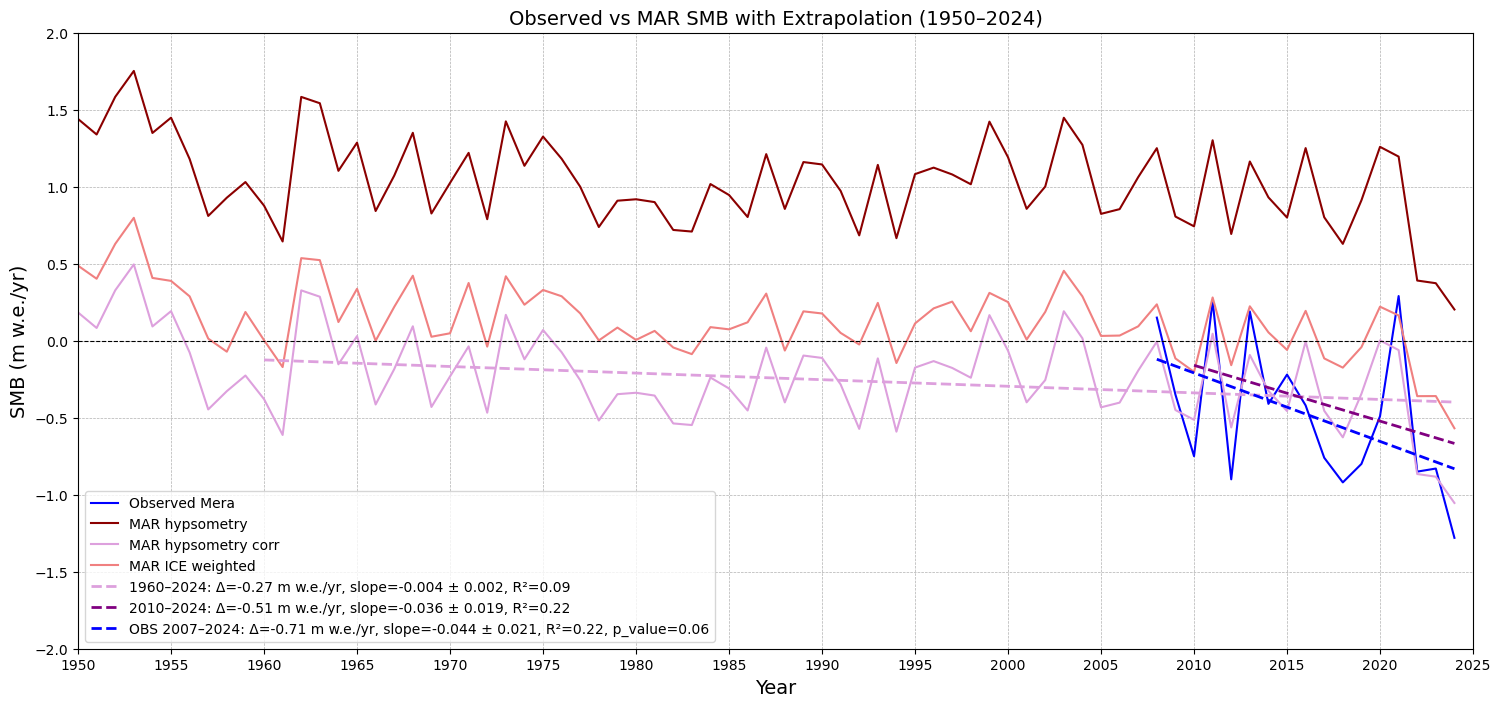

In [105]:
######### MAR data on the periode 2000-2024 #############
years_full = np.arange(1950, 2025) # Liste des années sous le format yy

variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

SMB_extra = []


############### MAR data loading ##############
for year in years_full:
    file = f"{variable}_daysum_MARv3.14_ER5_spin2_GRq_{year}.nc"
    
    ds_SMB_extra = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMB_extra = ds_SMB_extra[:,k:-k,k:-k]
    
    ds_ICE_mask = ds_ICE_mask.assign_coords(Y=ds_SMB_extra.Y, X=ds_SMB_extra.X) # Force le ICE_mask a être sur la même grille que le SMB
    ds_SMB_extra = ds_SMB_extra.where(ds_ICE_mask) # On fait directement un tri sur les données. Seuls les points de grille avec de la glace >= ice_level seront reconnus
    
    SMB_extra.append(ds_SMB_extra)


############# Khumbu domain ###############
Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

SMB_list_khumbu, SMB_list_extra_hypso, SMB_list_extra_hypso_corr, SMB_list_extra_ICEweighted = [], [], [], []

years_obs = {year: (date_ref[i], date_obs[i]) for i, year in enumerate(years[:n])} # Créer un dictionnaire où on attribue à chaque année où les obs sont présentes, les dates de mesure determinée


############# MAR data processing ##################
for j in range(len(years_full)):
    year = years_full[j] # année réelle

    ########## Années avec obs #########
    if year in years_obs: # Condition permettant de choisir la même période que les obs pour les années conjointes
        start_obs, end_obs = years_obs[year]
        
        if j > 0:
            SMB_concat = xr.concat([SMB_extra[j-1], SMB_extra[j]], dim="TIME")
        else:
            SMB_concat = SMB_extra[j]
            
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(start_obs, end_obs)).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    #################################################

        
    ######### Année hydrologique (without obs) ##############
    else:
        if j > 0: # 1 Dec (year-1) → 30 Nov (year)
            dec_past = SMB_extra[j-1].sel(TIME=slice(f"{year-1}-12-01", f"{year-1}-12-31"))

            jan_nov = SMB_extra[j].sel(TIME=slice(f"{year}-01-01", f"{year}-11-30"))

            SMB_day_khumbu = xr.concat([dec_past, jan_nov], dim="TIME").isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))

        else: # année incomplète (pas d'année précédente)
            SMB_day_khumbu = SMB_extra[j].sel(TIME=slice(f"{year}-01-01", f"{year}-11-30")).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    #################################################

    
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_extra = SMB_sum_khumbu.values.flatten()
    SH_MAR_extra = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_extra != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_extra = SMB_MAR_extra[mask_zero]
    SH_MAR_extra = SH_MAR_extra[mask_zero]

    # Cette ligne créer bien une liste de valeur de biais associés à chaque point de grille
    bias_points_extra = np.interp(SH_MAR_extra, alt_100m, bias_interp) # Interpolation du biais pour chaque point de grille en fct de leur altitude
    
    SMB_MAR_extra_corr = SMB_MAR_extra - bias_points_extra # Correction du SMB de chaque points de grille
    ############ Hypsometry corrigé ###############
    df_mar_corr = pd.DataFrame({"SMB": SMB_MAR_extra_corr, "Elevation": SH_MAR_extra}) # Création d'un data frame pour les points de MAR

    df_mar_corr["elev_bin"] = (df_mar_corr["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band_corr = df_mar_corr.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge_corr = pd.merge(df_mar_band_corr, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge_corr["SMB_weighted"] = df_merge_corr["SMB"]*df_merge_corr["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_extra_weighted_corr = df_merge_corr["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_list_extra_hypso_corr.append(SMB_extra_weighted_corr)
    #########################################
    
    ############ Hypsometry NON corrigée ###############
    df_mar = pd.DataFrame({"SMB": SMB_MAR_extra, "Elevation": SH_MAR_extra}) # Création d'un data frame pour les points de MAR

    df_mar["elev_bin"] = (df_mar["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band = df_mar.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge = pd.merge(df_mar_band, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge["SMB_weighted"] = df_merge["SMB"]*df_merge["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_extra_weighted = df_merge["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_list_extra_hypso.append(SMB_extra_weighted)
    #########################################

    
    ########## Moyenne sur le domaine ############
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    SMB_list_khumbu.append(SMB_regional)
    #########################################

    
    ######## Moyenne pondérée par ICE % ############
    ICE_frac = ds_ICE_mask.isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Fraction de glace sur le domaine défini (ici khumbu)

    SMB_regional_ICEweighted = ((SMB_sum_khumbu * ICE_frac).sum(dim=["Y","X"]) / ICE_frac.sum(dim=["Y","X"])).values # Moyenne pondérée à la fraction de glace par point de grille
    # Pour chaque point de grille on lui donne le poids de sa fraction de glace occupé en % --> On somme sur tout le domaine et on normalise les poids
    SMB_list_extra_ICEweighted.append(SMB_regional_ICEweighted)
    #########################################


############ Plot ##############
plt.figure(figsize=(18,8))

mar_mean = np.array(SMB_list_khumbu)
mar_hypso = np.array(SMB_list_extra_hypso)
mar_hypso_corr = np.array(SMB_list_extra_hypso_corr)
mar_ICEweighted = np.array(SMB_list_extra_ICEweighted)
obs = np.array(Mera_MBgw[:n])

plt.plot(years[:n], obs, color="blue", label="Observed Mera")
plt.plot(years_full, mar_hypso, color="darkred", label="MAR hypsometry")
plt.plot(years_full, mar_hypso_corr, color="plum", label="MAR hypsometry corr")
plt.plot(years_full, mar_ICEweighted, color="lightcoral", label="MAR ICE weighted") # MAR brut pondéré
#plt.plot(years_full, mar_mean, color="red", linestyle="--", label="MAR mean") # MAR mean sur le khumbu

years = np.array(years)
years_obs = years[:n]

plt.plot(years_1960, trend_1960, color="plum", linewidth=2, linestyle="--", label=f"1960–2024: Δ={Delta_SMB_1960:.2f} m w.e./yr, slope={slope_1960:.3f} ± {std_err_1960:.3f}, R²={R2_1960:.2f}")
plt.plot(years_2010, trend_2010, color="purple", linewidth=2, linestyle="--", label=f"2010–2024: Δ={Delta_SMB_2010:.2f} m w.e./yr, slope={slope_2010:.3f} ± {std_err_2010:.3f}, R²={R2_2010:.2f}")
plt.plot(years_obs, trend_obs, color="blue", linewidth=2, linestyle="--", label=f"OBS 2007–2024: Δ={Delta_SMB_obs:.2f} m w.e./yr, slope={slope_obs:.3f} ± {std_err_obs:.3f}, R²={R2_obs:.2f}, p_value={p_value_obs:.2f}")

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.xlim(1950, 2025)
plt.ylim(-2, 2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.title("Observed vs MAR SMB with Extrapolation (1950–2024)", fontsize=14)

plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')

plt.savefig("SMB_1950.png", dpi=300)

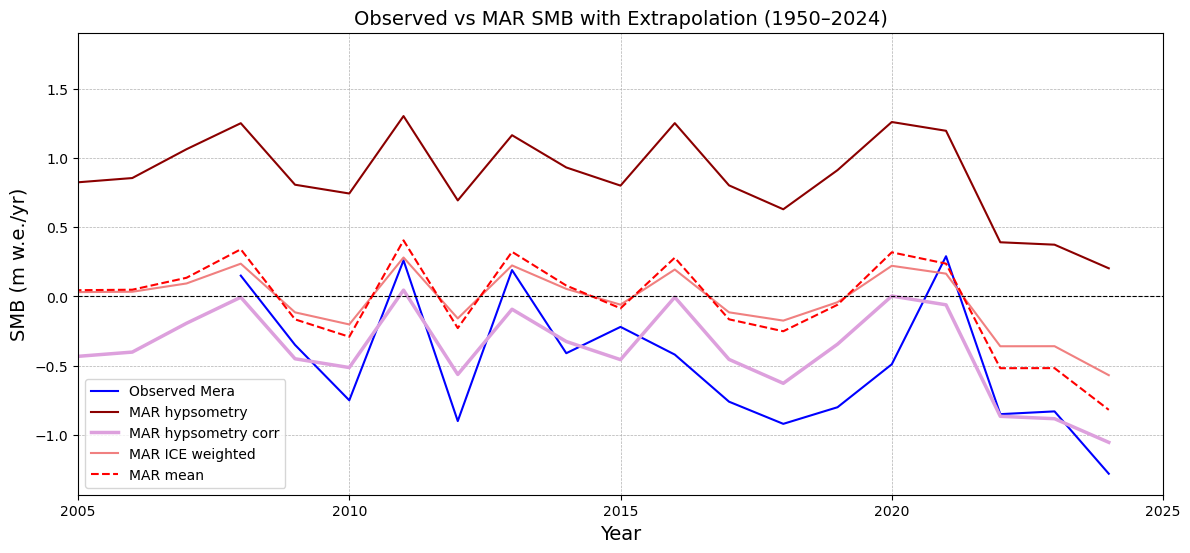

In [100]:
############ Plot ##############
plt.figure(figsize=(14,6))

mar_mean = np.array(SMB_list_khumbu)
mar_hypso = np.array(SMB_list_extra_hypso)
mar_hypso_corr = np.array(SMB_list_extra_hypso_corr)
mar_ICEweighted = np.array(SMB_list_extra_ICEweighted)
obs = np.array(Mera_MBgw[:n])

plt.plot(years[:n], obs, color="blue", label="Observed Mera")
plt.plot(years_full, mar_hypso, color="darkred", label="MAR hypsometry")
plt.plot(years_full, mar_hypso_corr, color="plum", linewidth=2.5, label="MAR hypsometry corr")
plt.plot(years_full, mar_ICEweighted, color="lightcoral", label="MAR ICE weighted") # MAR brut pondéré
plt.plot(years_full, mar_mean, color="red", linestyle="--", label="MAR mean") # MAR mean sur le khumbu

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.xlim(2005, 2025)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.title("Observed vs MAR SMB with Extrapolation (1950–2024)", fontsize=14)

plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')

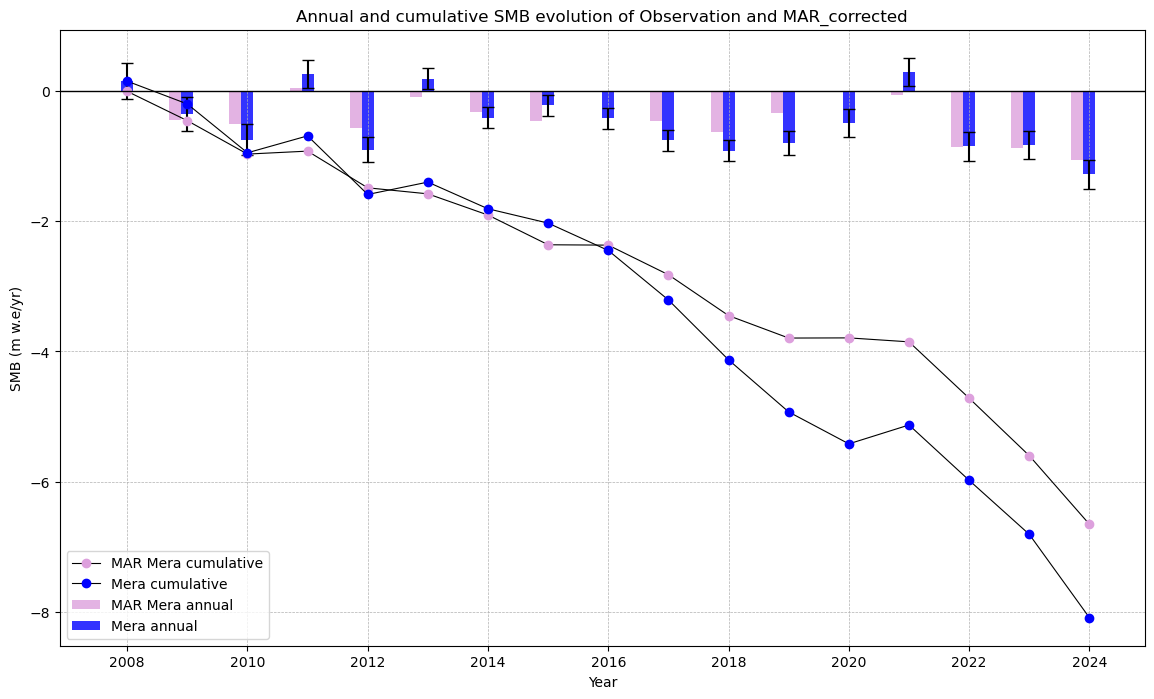

In [101]:
# Série temporelle Mera grid 
plt.figure(figsize=(14,8))

mar_hypso_corr = np.array(SMB_list_extra_hypso_corr)
obs = np.array(Mera_MBgw[:n])

mask_obs = years_full >= 2008
mar_corr = mar_hypso_corr[mask_obs]


Mera_MBgw_cum = np.cumsum(Mera_MBgw)
MAR_corr_cum = np.cumsum(mar_corr)

width = 0.20 # Largeur des barres annual
offsets = [-width, 0, width] # Décalage des barres annual

series = [("MAR Mera", mar_corr, None, "plum"),("Mera", Mera_MBgw, error_complet, "b")]#, ("Changri", Changri_MBgw_full, None, "lightskyblue")] # Création de la série contenant les observations et MAR

##### Annual ######
for offset, (name, values, err, color) in zip(offsets, series): # Zip permet de parcourir en parallèle offsets et series pour les associer ensemble
    plt.bar(np.array(years[:n]) + offset, values[:n], yerr=err[:n] if err is not None else None, width=width, color=color, alpha=0.8, capsize=4, ecolor='k', label=f"{name} annual") # yerr est une fonction matplotlib qui permet d'afficher les barres d'erreur (si pas de barre d'erreur on passe à la suite)

##### Cumulative ######
##### MAR ######
plt.plot(years, MAR_corr_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="plum", markeredgecolor="plum", label="MAR Mera cumulative") # Cumulative SMB
##### Mera ######
plt.plot(years[:n], Mera_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="b", markeredgecolor="b", label="Mera cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée
##### Changri #####
#plt.plot(years[:n], Changri_MBgw_cum[:n], color="k", linewidth=0.8, marker="o", markerfacecolor="lightskyblue", markeredgecolor="lightskyblue", label="Changri cumulative") # Plot jusqu'à ce que la plus petite liste soit vidée

plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative SMB evolution of Observation and MAR_corrected")
plt.legend()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.savefig("MAR_corr_timeseries.png")

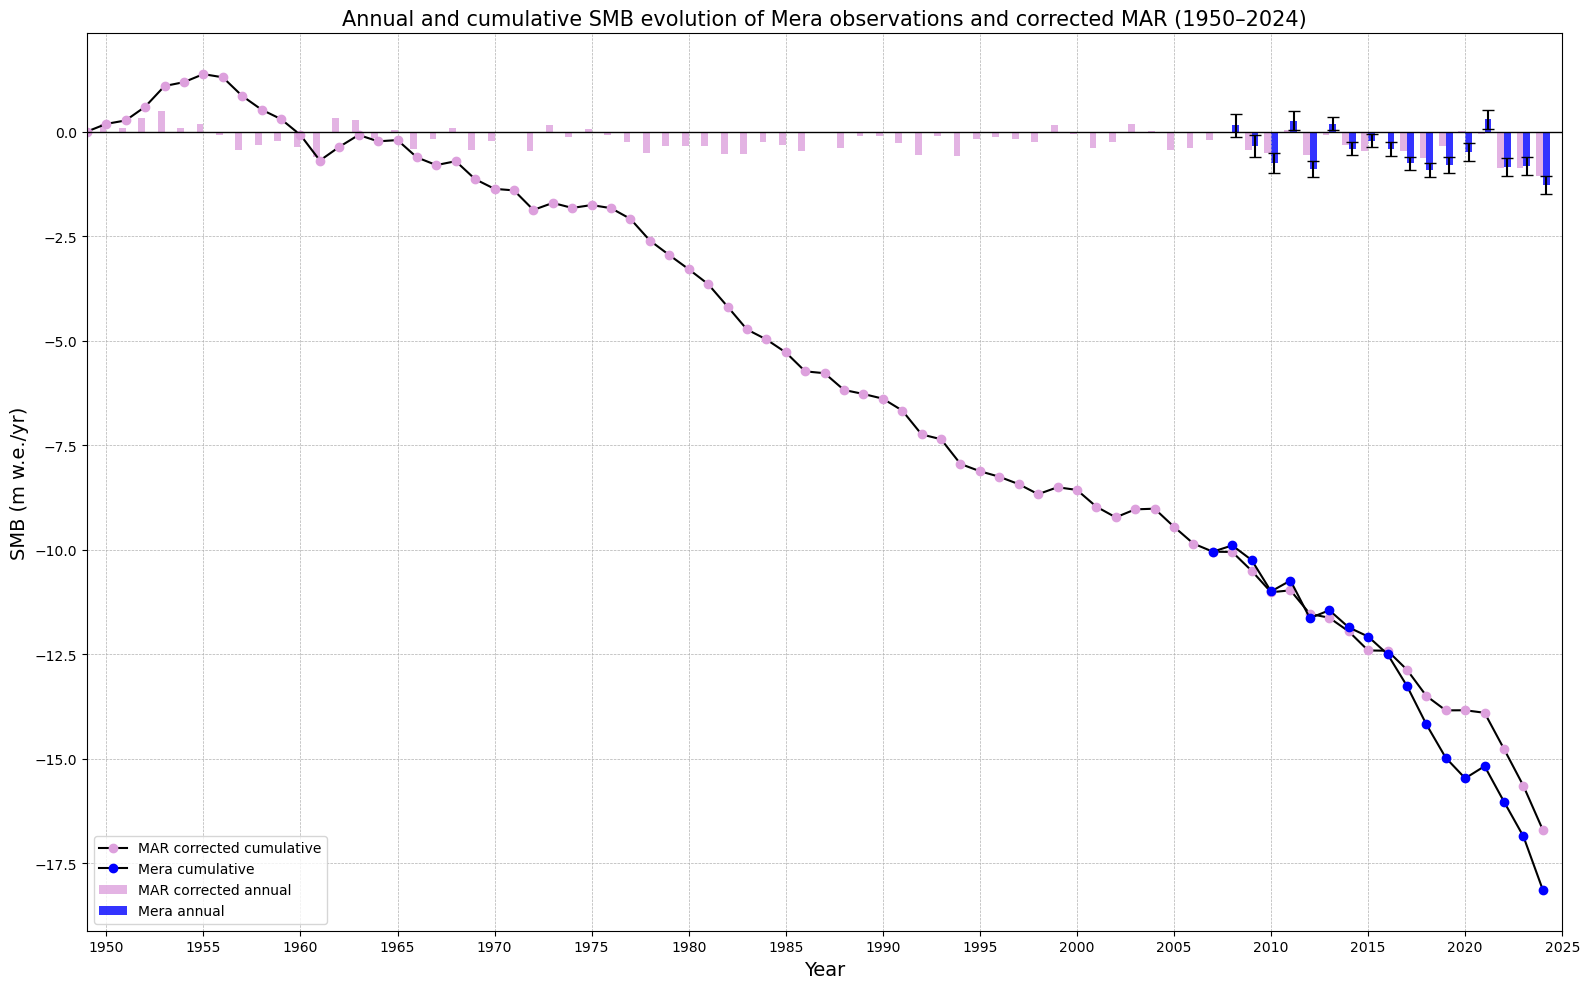

In [103]:
############ Série temporelle étendue 1950–2024 ################
plt.figure(figsize=(16,10))

years = np.array(years)
years_obs = years[:n]

########## Conversion en array ##########
years_full = np.array(years_full)

mar_corr_full = np.array(SMB_list_extra_hypso_corr) # MAR corrigé 1950–2024
mera_obs = np.array(Mera_MBgw[:n]) # Observations
mera_err = np.array(error_complet[:n])

########## Cumulative ##########
mar_corr_cum_full = np.cumsum(mar_corr_full)
mera_obs_cum = np.cumsum(mera_obs)

########## Ajouter un point initial à zéro ##########
mar_corr_cum_full = np.insert(mar_corr_cum_full, 0, 0) # Ajoute un zéro au début de la série cumulée MAR
years_full_cum = np.insert(years_full, 0, years_full[0]-1) # Ajoute une année fictive avant 1950

#### Feat des obs et mar_corr ####
obs_start = years[:n][0] # Première année des observations (année commune)
obs_extension = mar_corr_cum_full[np.where(years_full_cum == obs_start-1)[0][0]] # Valeur cumulée de MAR à la première date des observations

########## Ajouter le point initial des observations ##########
mera_obs_cum_shift = np.insert(mera_obs_cum + obs_extension, 0, obs_extension) # Décale les observations pour commencer à la valeur de MAR
years_obs_cum = np.insert(np.array(years[:n]), 0, obs_start-1) # Ajoute une année fictive avant les observations

########## Bar parameters ##########
width = 0.35 # Largeur des barres annual

######################## ANNUAL ###############################
##### MAR corrigé sur toute la période #####
plt.bar(years_full - width/2, mar_corr_full, width=width, color="plum", alpha=0.8, label="MAR corrected annual")

##### Mera #####
plt.bar(np.array(years[:n]) + width/2, mera_obs, yerr=mera_err, width=width, color="b", alpha=0.8, capsize=4, ecolor='k', label="Mera annual")

###################### CUMULATIVE #############################
##### MAR cumulative #####
plt.plot(years_full_cum, mar_corr_cum_full, color="k", linewidth=1.5, marker="o", markersize=6, markerfacecolor="plum", markeredgecolor="plum", label="MAR corrected cumulative")

##### Mera cumulative #####
plt.plot(years_obs_cum, mera_obs_cum_shift, color="k", linewidth=1.5, marker="o", markersize=6, markerfacecolor="b", markeredgecolor="b", label="Mera cumulative")

plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.title("Annual and cumulative SMB evolution of Mera observations and corrected MAR (1950–2024)", fontsize=15)

plt.xlim(1949, 2025)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5)) # Axe tous les 5 ans
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')
plt.tight_layout()

#plt.savefig("MAR_corrected_timeseries_1950_2024.png", dpi=300)

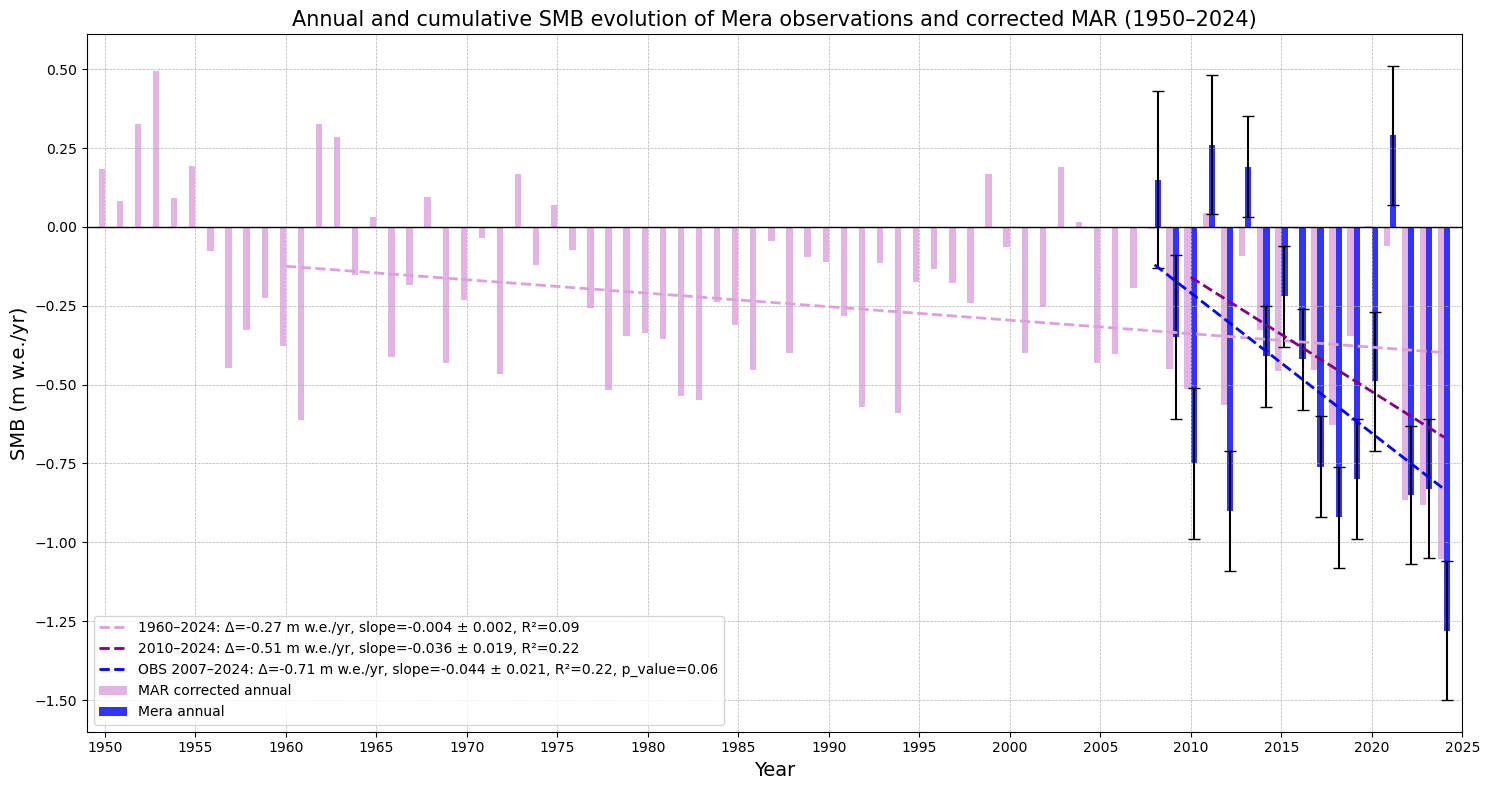

In [104]:
########### Tendance du SMB corrigé sur différentes périodes ################

######################## ANNUAL ###############################
plt.figure(figsize=(15,8))

years = np.array(years)
years_obs = years[:n]

##### MAR corrigé sur toute la période #####
plt.bar(years_full - width/2, mar_corr_full, width=width, color="plum", alpha=0.8, label="MAR corrected annual")

##### Mera #####
plt.bar(np.array(years[:n]) + width/2, mera_obs, yerr=mera_err, width=width, color="b", alpha=0.8, capsize=4, ecolor='k', label="Mera annual")


######################## Tendances linéaires #######################
########## Période 1960–2024 ##########
mask_1960 = years_full >= 1960

years_1960 = years_full[mask_1960]
mar_1960 = mar_corr_full[mask_1960]

slope_1960, intercept_1960, r_value_1960, p_value_1960, std_err_1960 = stats.linregress(years_1960, mar_1960) # Régression linéaire sur la période

trend_1960 = slope_1960 * years_1960 + intercept_1960
Delta_SMB_1960 = slope_1960 * (years_1960[-1] - years_1960[0])
R2_1960 = r_value_1960**2

########## Période 2010–2024 ##########
mask_2010 = years_full >= 2010

years_2010 = years_full[mask_2010]
mar_2010 = mar_corr_full[mask_2010]

slope_2010, intercept_2010, r_value_2010, p_value_2010, std_err_2010 = stats.linregress(years_2010, mar_2010)

trend_2010 = slope_2010 * years_2010 + intercept_2010
Delta_SMB_2010 = slope_2010 * (years_2010[-1] - years_2010[0])
R2_2010 = r_value_2010**2

######## Trend OBS #############
slope_obs, intercept_obs, r_value_obs, p_value_obs, std_err_obs = stats.linregress(years[:n], mera_obs)

trend_obs = slope_obs * years_obs + intercept_obs
Delta_SMB_obs = slope_obs * (years[:n][-1] - years[:n][0])
R2_obs = r_value_obs**2

######################## Plot des tendances ########################
plt.plot(years_1960, trend_1960, color="plum", linewidth=2, linestyle="--", label=f"1960–2024: Δ={Delta_SMB_1960:.2f} m w.e./yr, slope={slope_1960:.3f} ± {std_err_1960:.3f}, R²={R2_1960:.2f}")
plt.plot(years_2010, trend_2010, color="purple", linewidth=2, linestyle="--", label=f"2010–2024: Δ={Delta_SMB_2010:.2f} m w.e./yr, slope={slope_2010:.3f} ± {std_err_2010:.3f}, R²={R2_2010:.2f}")
plt.plot(years_obs, trend_obs, color="blue", linewidth=2, linestyle="--", label=f"OBS 2007–2024: Δ={Delta_SMB_obs:.2f} m w.e./yr, slope={slope_obs:.3f} ± {std_err_obs:.3f}, R²={R2_obs:.2f}, p_value={p_value_obs:.2f}")

plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.title("Annual and cumulative SMB evolution of Mera observations and corrected MAR (1950–2024)", fontsize=15)

plt.xlim(1949, 2025)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5)) # Axe tous les 5 ans
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')
plt.tight_layout()

# Analyse du biais après correction

Mean bias: 0.1037577230774214 m w.e/yr
RMSE: 0.2902768743708599 m w.e/yr
Standard deviation: 0.2710996102843107


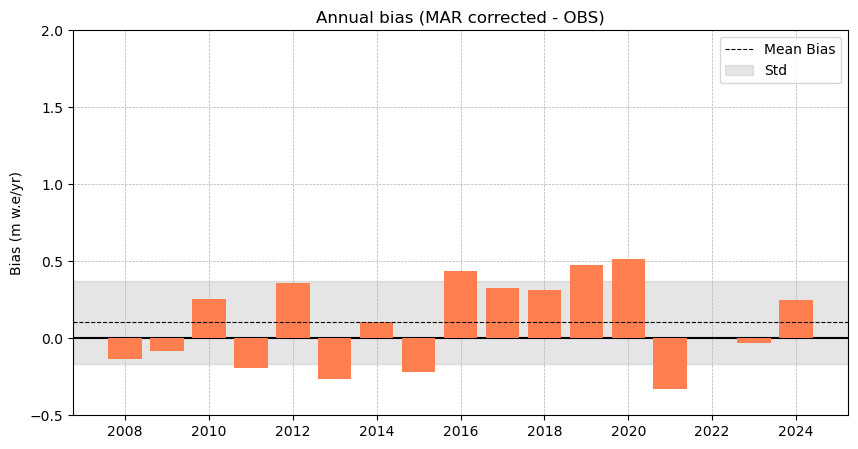

In [57]:
###### Quantification du biais annuel et moyen entre le modèle et les obs, après la correction #######
plt.figure(figsize=(10,5))

mar_hypso_corr = np.array(SMB_list_extra_hypso_corr)
obs = np.array(Mera_MBgw[:n])

mask_obs = years_full >= 2008
mar_corr = mar_hypso_corr[mask_obs]

annual_bias = mar_corr - obs # Biais sur chaque année

mean_bias = np.mean(annual_bias) # Biais moyen sur toute la période
print("Mean bias:", mean_bias, 'm w.e/yr')

rmse = np.sqrt(np.mean((mar_corr - obs)**2))
print("RMSE:", rmse, 'm w.e/yr')

std = np.std(annual_bias)
print("Standard deviation:", std)

plt.bar(years[:n], annual_bias, color="coral", zorder=3)
plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.2, label="Std")
plt.axhline(0, color="k")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.title("Annual bias (MAR corrected - OBS)")
plt.legend()
plt.ylabel("Bias (m w.e/yr)")
plt.ylim(-0.5,2)
plt.grid(linestyle='--', linewidth=0.5, zorder=0)
plt.savefig("bias_corr.png")

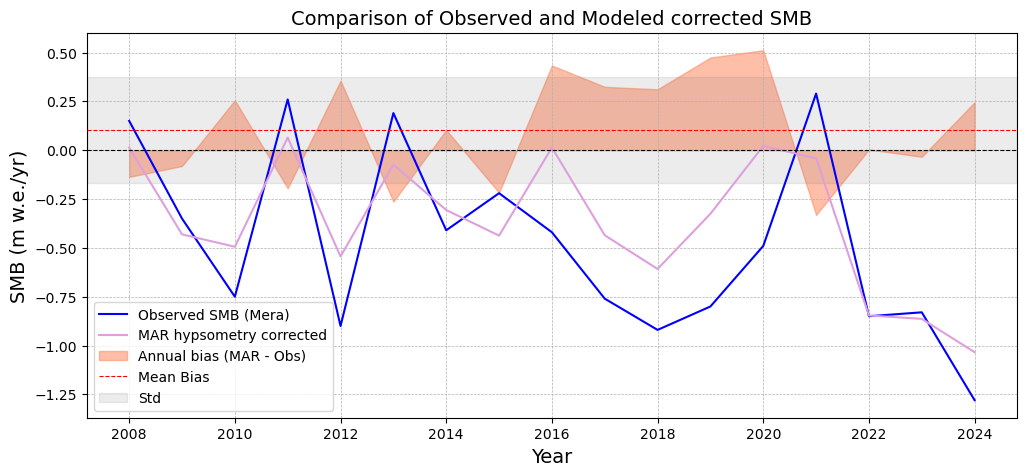

In [58]:
plt.figure(figsize=(12,5))

plt.plot(years[:n], obs, color="blue", label="Observed SMB (Mera)")
plt.plot(years[:n], mar_corr, color="plum", label="MAR hypsometry corrected")
plt.fill_between(years[:n], annual_bias, 0, color="coral", alpha=0.5, label="Annual bias (MAR - Obs)")
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.title("Comparison of Observed and Modeled corrected SMB", fontsize=14)
plt.axhline(mean_bias, color="r", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.15, label="Std")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')
plt.savefig("annual_bias_hypso.png")

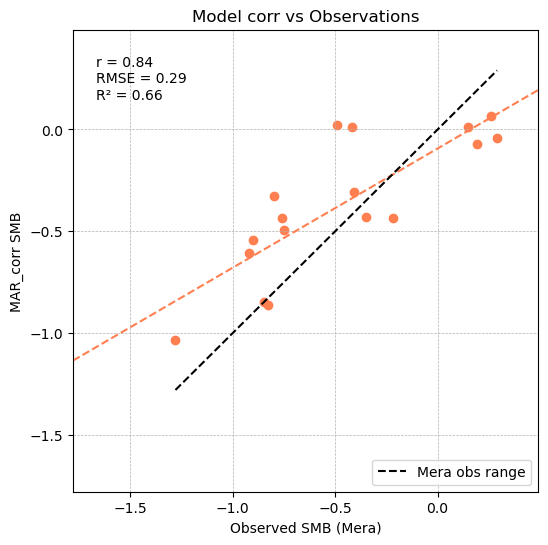

In [59]:
#### Régression linéaire Obs et Modèle corrigé ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, mar_corr)

plt.figure(figsize=(6,6))
plt.scatter(obs, mar_corr, color="coral")
lims = [min(obs.min()-0.5, mar_corr.min()-0.5), max(obs.max()+0.2, mar_corr.max()+0.2)]
plt.xlim(lims)
plt.ylim(lims)
coef = np.polyfit(obs, mar_corr, 1)
x = np.linspace(*lims, 100)
plt.plot(x, coef[0]*x + coef[1], color="coral", linestyle='--')

plt.plot([obs.min(), obs.max()], [obs.min(), obs.max()], 'k--', label="Mera obs range")
plt.xlabel("Observed SMB (Mera)")
plt.ylabel("MAR_corr SMB")

plt.text(0.05, 0.85, f"r = {corr:.2f}\nRMSE = {rmse:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # Affiche le RMSE et la corrélation sur le graph

plt.title("Model corr vs Observations")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.savefig("model_vs_obs_hypso.png")

Slope: -0.4145225216715037
Correlation (r): -0.7038488374579523
R²: 0.49540318599091104
p_value: 0.0016144964472453711


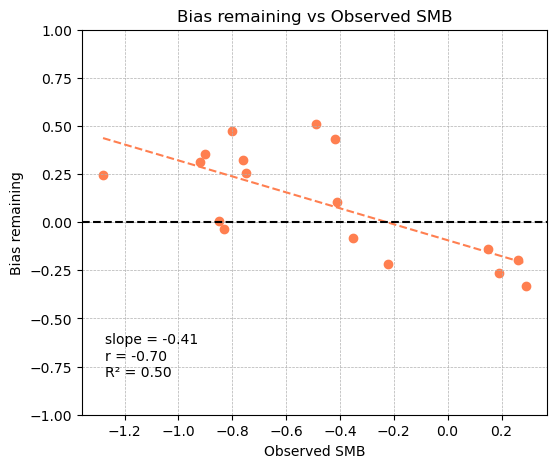

In [60]:
#### Régression linéaire du biais restant selon les obs ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, annual_bias)

# Toutes les valeurs associée à la régression linéaire
print("Slope:", slope)
print("Correlation (r):", r_value)
print("R²:", r_value**2)
print("p_value:", p_value)

plt.figure(figsize=(6,5))

plt.scatter(obs, annual_bias, color="coral")
x = np.linspace(obs.min(), obs.max(), 100)
plt.plot(x, slope*x + intercept, color="coral", linestyle='--')

plt.axhline(0, color='k', linestyle='--')
plt.ylim(-1,1)
plt.xlabel("Observed SMB")
plt.ylabel("Bias remaining")
plt.title("Bias remaining vs Observed SMB")

plt.text(0.05, 0.1, f"slope = {slope:.2f}\nr = {r_value:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # affichage valeurs sur le plot
plt.grid(linestyle='--', linewidth=0.5)
plt.savefig("bias_remaining_vs_observed_SMB.png")

Slope: -0.13069852211182603
Correlation (r): -0.15969217188094315
R²: 0.02550158976005269
p_value: 0.540388864210263


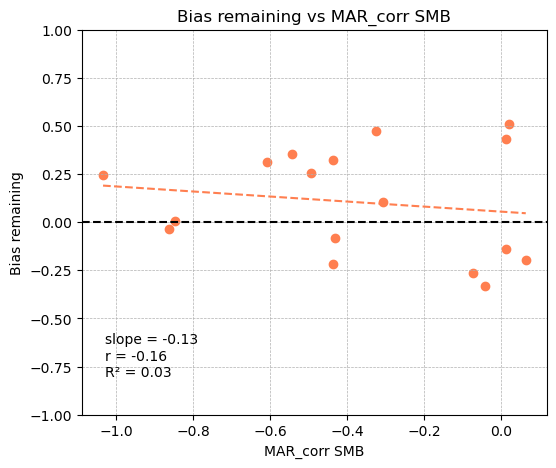

In [61]:
#### Régression linéaire du biais restant selon MAR corrigé ####
slope, intercept, r_value, p_value, std_err = stats.linregress(mar_corr, annual_bias)

# Toutes les valeurs associée à la régression linéaire
print("Slope:", slope)
print("Correlation (r):", r_value)
print("R²:", r_value**2)
print("p_value:", p_value)

plt.figure(figsize=(6,5))

plt.scatter(mar_corr, annual_bias, color="coral")
x = np.linspace(mar_corr.min(), mar_corr.max(), 100)
plt.plot(x, slope*x + intercept, color="coral", linestyle='--')

plt.axhline(0, color='k', linestyle='--')
plt.ylim(-1,1)
plt.xlabel("MAR_corr SMB")
plt.ylabel("Bias remaining")
plt.title("Bias remaining vs MAR_corr SMB")

plt.text(0.05, 0.1, f"slope = {slope:.2f}\nr = {r_value:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # affichage valeurs sur le plot
plt.grid(linestyle='--', linewidth=0.5)
plt.savefig("bias_remaining_vs_MAR_SMB_corr.png")

# Calibration 2007-2017

In [ ]:
########### Reconstruction propre (avec NaN) ###########
years = years[:nyy]   # timeline complète


years_calib = years[:10]
print(years_calib)
ncalib = len(years_calib)
print(ncalib)

MAR_by_alt = {}
OBS_by_alt = {}

alts_valid = []
bias_mean_valid = []

# Initialisation : toutes les altitudes possibles
all_alts = alt_center_global

# Initialisation avec NaN
for alt in all_alts:
    MAR_by_alt[alt] = np.full(len(years_calib), np.nan)
    OBS_by_alt[alt] = np.full(len(years_calib), np.nan)

########### Remplissage ###########
for j in range(ncalib):
    
    alt_mar = SMB_MAR_mean_alt_all[j]["alt"]
    mean_mar = SMB_MAR_mean_alt_all[j]["mean"]

    alt_obs = SMB_OBS_mean_alt_all[j]["alt"]
    mean_obs = SMB_OBS_mean_alt_all[j]["mean"]

    for i, alt in enumerate(alt_mar):
        MAR_by_alt[alt][j] = mean_mar[i]

    for i, alt in enumerate(alt_obs):
        OBS_by_alt[alt][j] = mean_obs[i]

########### Plot ###########
for alt in all_alts:

    mar_series = MAR_by_alt[alt]
    obs_series = OBS_by_alt[alt]
    valid = ~np.isnan(mar_series) & ~np.isnan(obs_series)     # On garde seulement les points où les deux existent

    if np.sum(valid) < 2:
        continue  # pas assez de points pour un plot
        
    years_plot = np.array(years_calib)

    annual_bias = mar_series - obs_series
    valid_bias = ~np.isnan(annual_bias)

    mean_bias = np.mean(annual_bias[valid_bias])
    std = np.std(annual_bias[valid_bias])
    rmse = np.sqrt(np.mean((annual_bias[valid_bias])**2))

    alts_valid.append(alt)
    bias_mean_valid.append(mean_bias)
    
    print('Alt:', alt)    
    print('Mean bias for alt:', mean_bias)
    print("RMSE:", rmse, 'm w.e/yr') 
    print()

    std = np.std(annual_bias)

    plt.figure(figsize=(10,4))

    plt.plot(years_plot, obs_series, color="blue", label="Observed SMB")
    plt.plot(years_plot, mar_series, color="darkred", label="MAR SMB")

    plt.fill_between(years_plot, annual_bias, 0, color="coral", alpha=0.5, label="Annual bias")

    plt.title(f"Altitude band: {int(alt)} m")

    plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, label='Mean Bias')
    plt.axhline(rmse, color="r", linestyle='--', linewidth=0.8, label='RMSE')
    plt.axhline(0, color='k', linestyle='--', linewidth=0.8)

    plt.grid(linestyle='--', linewidth=0.5)
    plt.legend()

    plt.savefig(f"annual_bias_alt_{int(alt)}.png")

In [ ]:
############ Interpolation ##########
alt_100m = np.arange(np.min(alts_valid), np.max(alts_valid)+300, 100) # On définit les bandes de 100m d'alt, et force avec +300 à atteindre 6500m
print(alt_100m)

bias_interp = np.interp(alt_100m, alts_valid, bias_mean_valid) # Interpolation sur des bandes de 100m

##### Plot ######
plt.figure(figsize=(6,8))

plt.scatter(bias_mean_valid, alts_valid, label="250 m bands", color="k")
plt.plot(bias_interp, alt_100m, label="100 m interpolated", color="red")
#print(bias_interp)

plt.ylabel("Altitude (m)")
plt.xlabel("Mean bias")
plt.xlim(0,3)
plt.legend()
plt.grid()

In [ ]:
### Khumbu domain

Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,5*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list_khumbu, SMB_hypso_corr = [], []

####### Grid on last subplot ######
ax = axes[nyy]
ds_SH_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne le SMB sur les grilles données
ds_ICE_khumbu = ds_ICE.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))
ds_lat_khumbu = ds_lat.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright))

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[30], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


####### Subplot filling ###### 
for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

    ###### MAR_data loading and sorting  ######
    if j > 0:
        SMB_concat = xr.concat([SMB_year[j-1], SMB_year[j]], dim="TIME") # On garde en mémoire l'année précédente, car chevauchement de 2 années pour les date des obs
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    
    if j == 0:
        SMB_day_khumbu = SMB_year[j].sel(TIME=slice(date_ref[j], date_obs[j])).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)

    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten()
    SH_MAR_khumbu = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_khumbu != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_khumbu = SMB_MAR_khumbu[mask_zero]
    SH_MAR_khumbu = SH_MAR_khumbu[mask_zero]

    # Cette ligne créer bien une liste de valeur de biais associés à chaque point de grille
    bias_points = np.interp(SH_MAR_khumbu, alt_100m, bias_interp) # Interpolation du biais pour chaque point de grille en fct de leur altitude
    
    SMB_MAR_khumbu_corr = SMB_MAR_khumbu - bias_points # Correction du SMB de chaque points de grille

    ############ Hypsometry ###############
    df_mar = pd.DataFrame({"SMB": SMB_MAR_khumbu_corr, "Elevation": SH_MAR_khumbu}) # Création d'un data frame pour les points de MAR

    df_mar["elev_bin"] = (df_mar["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band = df_mar.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge = pd.merge(df_mar_band, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge["SMB_weighted"] = df_merge["SMB"]*df_merge["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_weighted_corr = df_merge["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_hypso_corr.append(SMB_weighted_corr)
    #########################################
    
    # Prepare les données pour les plot en série temporelle (ici on retire les valeurs de SMB=0)
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    SMB_list_khumbu.append(SMB_regional)
    
    #ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="r", label="MAR") # Affiche les points de MAR correspondant à la date des obs
    ax.scatter(SMB_MAR_khumbu_corr, SH_MAR_khumbu, color="blue", alpha=0.5, label="MAR corrected") # Points de MAR corrigés en altitude
    
    ###### Plot OBSERVATIONS ######
    ###### Accumulation
    ax.plot(SMB_accu_m[j], SH_accu_m[j], linestyle="", marker="^", color='k', label='Mera (accu.)') # Mera accu
    ax.plot(SMB_accu_m[j], reg_accu_m[j].intercept + reg_accu_m[j].slope * SMB_accu_m[j], 'k') # Mera accu regression lineaire

    ###### Ablation
    ax.plot(SMB_ablation_m[j], SH_ablation_m[j], linestyle="", marker="o", color='k', label='Mera (ablation)') # Mera ablation
    ax.plot(SMB_ablation_m[j], reg_ablation_m[j].intercept + reg_ablation_m[j].slope * SMB_ablation_m[j], color='k') # Mera ablation regression
    ax.plot(SMB_ablation_n[j], SH_ablation_n[j], linestyle="", marker="s", color='gray', label='Naulek (ablation)') # Naulek ablation
    ax.plot(SMB_ablation_n[j], reg_ablation_n[j].intercept + reg_ablation_n[j].slope * SMB_ablation_n[j], 'gray') # Naulek ablation regression

    ##### Changri Nup
    ax.plot(SMB_chan[j], SH_chan[j], linestyle="", marker="P", color='silver', label='Changri Nup') # Changri Nup
    
    if reg_chan[j] is not None: # Si on était à une année sans données de chagri on n'affiche pas sa régression linéaire
        ax.plot(SMB_chan[j], reg_chan[j].intercept + reg_chan[j].slope * SMB_chan[j], 'silver') # Changri Nup regression lineaire
    
    ###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-7, 3)
    ax.set_ylim(4200, 6600) # Restriction du domaine 
    ax.grid(linestyle = '--', linewidth = 0.5)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
plt.tight_layout()
#plt.savefig("khumbu_ice0_new.png")

print(date_ref[j], date_obs[j])
print(SMB_day_khumbu.TIME.min().values, SMB_day_khumbu.TIME.max().values) # Vérification de la période prise en compte par MAR
#print(SMB_list_khumbu)

In [ ]:
######### MAR data on the periode 2000-2024 #############
years_full = np.arange(1950, 2025) # Liste des années sous le format yy

variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

SMB_extra = []


############### MAR data loading ##############
for year in years_full:
    file = f"{variable}_daysum_MARv3.14_ER5_spin2_GRq_{year}.nc"
    
    ds_SMB_extra = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMB_extra = ds_SMB_extra[:,k:-k,k:-k]
    
    ds_ICE_mask = ds_ICE_mask.assign_coords(Y=ds_SMB_extra.Y, X=ds_SMB_extra.X) # Force le ICE_mask a être sur la même grille que le SMB
    ds_SMB_extra = ds_SMB_extra.where(ds_ICE_mask) # On fait directement un tri sur les données. Seuls les points de grille avec de la glace >= ice_level seront reconnus
    
    SMB_extra.append(ds_SMB_extra)


############# Khumbu domain ###############
Ydown, Yup, Xleft, Xright = iY, iY+9, iX-7, iX+5 # Choix du maillage en fonction de la position iY et iX de la grille du Mera

SMB_list_khumbu, SMB_list_extra_hypso, SMB_list_extra_hypso_corr, SMB_list_extra_ICEweighted = [], [], [], []

years_obs = {year: (date_ref[i], date_obs[i]) for i, year in enumerate(years[:n])} # Créer un dictionnaire où on attribue à chaque année où les obs sont présentes, les dates de mesure determinée


############# MAR data processing ##################
for j in range(len(years_full)):
    year = years_full[j] # année réelle

    ########## Années avec obs #########
    if year in years_obs: # Condition permettant de choisir la même période que les obs pour les années conjointes
        start_obs, end_obs = years_obs[year]
        
        if j > 0:
            SMB_concat = xr.concat([SMB_extra[j-1], SMB_extra[j]], dim="TIME")
        else:
            SMB_concat = SMB_extra[j]
            
        SMB_day_khumbu = SMB_concat.sel(TIME=slice(start_obs, end_obs)).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    #################################################

        
    ######### Année hydrologique (without obs) ##############
    else:
        if j > 0: # 1 Dec (year-1) → 30 Nov (year)
            dec_past = SMB_extra[j-1].sel(TIME=slice(f"{year-1}-12-01", f"{year-1}-12-31"))

            jan_nov = SMB_extra[j].sel(TIME=slice(f"{year}-01-01", f"{year}-11-30"))

            SMB_day_khumbu = xr.concat([dec_past, jan_nov], dim="TIME").isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))

        else: # année incomplète (pas d'année précédente)
            SMB_day_khumbu = SMB_extra[j].sel(TIME=slice(f"{year}-01-01", f"{year}-11-30")).isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright))
    #################################################

    
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté des valeurs journalière sur la période, et rapporte les millimètres en mètres
    SMB_MAR_extra = SMB_sum_khumbu.values.flatten()
    SH_MAR_extra = ds_SH.isel(y=slice(Ydown, Yup), x=slice(Xleft, Xright)).values.flatten() # Altitude des grilles de MAR

    mask_zero = SMB_MAR_extra != 0 # Masque les valeurs=0 qui ont pu être générés par le ice_level
    SMB_MAR_extra = SMB_MAR_extra[mask_zero]
    SH_MAR_extra = SH_MAR_extra[mask_zero]

    # Cette ligne créer bien une liste de valeur de biais associés à chaque point de grille
    bias_points_extra = np.interp(SH_MAR_extra, alt_100m, bias_interp) # Interpolation du biais pour chaque point de grille en fct de leur altitude
    
    SMB_MAR_extra_corr = SMB_MAR_extra - bias_points_extra # Correction du SMB de chaque points de grille

    ############ Hypsometry corrigé ###############
    df_mar_corr = pd.DataFrame({"SMB": SMB_MAR_extra_corr, "Elevation": SH_MAR_extra}) # Création d'un data frame pour les points de MAR

    df_mar_corr["elev_bin"] = (df_mar_corr["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band_corr = df_mar_corr.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge_corr = pd.merge(df_mar_band_corr, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge_corr["SMB_weighted"] = df_merge_corr["SMB"]*df_merge_corr["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_extra_weighted_corr = df_merge_corr["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_list_extra_hypso_corr.append(SMB_extra_weighted_corr)
    #########################################
    
    ############ Hypsometry NON corrigée ###############
    df_mar = pd.DataFrame({"SMB": SMB_MAR_extra, "Elevation": SH_MAR_extra}) # Création d'un data frame pour les points de MAR

    df_mar["elev_bin"] = (df_mar["Elevation"] // 100) * 100 # Création des bandes de 100m d'altitude pour les points MAR
    df_mar_band = df_mar.groupby("elev_bin")["SMB"].mean().reset_index() # Moyenne sur chacune de ces bandes et attribution du bon indice

    hypso = df_100m[["elev_bin", "Area_%"]] # Rappel de la fonction df_100m défini auparavant lors de la définition de l'hypso
    
    df_merge = pd.merge(df_mar_band, hypso, on="elev_bin", how="inner") # Combine MAR et Hypso ensemble pour les plots ensuite
    df_merge["SMB_weighted"] = df_merge["SMB"]*df_merge["Area_%"]/100 # Pondère le SMB par la répartition en altitude du glacier en %
    
    SMB_extra_weighted = df_merge["SMB_weighted"].sum() # On somme pour calculer pour la région
    SMB_list_extra_hypso.append(SMB_extra_weighted)
    #########################################

    
    ########## Moyenne sur le domaine ############
    SMB_regional = SMB_sum_khumbu.where(SMB_sum_khumbu != 0).mean(dim=["Y","X"]).values # Fais la moyenne des SMB de chaque point de grille du khumbu pour chaque année
    SMB_list_khumbu.append(SMB_regional)
    #########################################

    
    ######## Moyenne pondérée par ICE % ############
    ICE_frac = ds_ICE_mask.isel(Y=slice(Ydown, Yup), X=slice(Xleft, Xright)) # Fraction de glace sur le domaine défini (ici khumbu)

    SMB_regional_ICEweighted = ((SMB_sum_khumbu * ICE_frac).sum(dim=["Y","X"]) / ICE_frac.sum(dim=["Y","X"])).values # Moyenne pondérée à la fraction de glace par point de grille
    # Pour chaque point de grille on lui donne le poids de sa fraction de glace occupé en % --> On somme sur tout le domaine et on normalise les poids
    SMB_list_extra_ICEweighted.append(SMB_regional_ICEweighted)
    #########################################


############ Plot ##############
plt.figure(figsize=(18,8))

mar_mean = np.array(SMB_list_khumbu)
mar_hypso = np.array(SMB_list_extra_hypso)
mar_hypso_corr = np.array(SMB_list_extra_hypso_corr)
mar_ICEweighted = np.array(SMB_list_extra_ICEweighted)
obs = np.array(Mera_MBgw[:n])

plt.plot(years_calib, obs[:10], color="blue", zorder=2, label="Calibration period (OBS)")
plt.plot(years[:n], obs, color="blue", linestyle="--" ,zorder=1,label="Observed Mera")
plt.plot(years_full, mar_hypso, color="darkred", label="MAR hypsometry")
plt.plot(years_full, mar_hypso_corr, color="plum", label="MAR hypsometry corr")
plt.plot(years_full, mar_ICEweighted, color="lightcoral", label="MAR ICE weighted") # MAR brut pondéré
#plt.plot(years_full, mar_mean, color="red", linestyle="--", label="MAR mean") # MAR mean sur le khumbu

plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year", fontsize=14)
plt.ylabel("SMB (m w.e./yr)", fontsize=14)
plt.xlim(1950, 2025)
plt.xlim(-2, 2)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.title("Observed vs MAR SMB with Extrapolation (1950–2024)", fontsize=14)

plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower left')

plt.savefig("SMB_1950_calibration.png", dpi=300)

In [ ]:
###### Quantification du biais annuel et moyen entre le modèle et les obs, après la correction #######
plt.figure(figsize=(10,5))

mar_hypso_corr = np.array(SMB_list_extra_hypso_corr)
obs = np.array(Mera_MBgw[:n])

mask_obs = years_full >= 2008
mar_corr = mar_hypso_corr[mask_obs]

annual_bias = mar_corr - obs # Biais sur chaque année

mean_bias = np.mean(annual_bias) # Biais moyen sur toute la période
print("Mean bias:", mean_bias, 'm w.e/yr')

rmse = np.sqrt(np.mean((mar_corr - obs)**2))
print("RMSE:", rmse, 'm w.e/yr')

std = np.std(annual_bias)
print("Standard deviation:", std)

plt.bar(years[:n], annual_bias, color="coral", zorder=3)
plt.axhline(mean_bias, color="k", linestyle='--', linewidth=0.8, zorder=3, label='Mean Bias')
plt.axhspan(mean_bias - std, mean_bias + std, color="gray", alpha=0.2, label="Std")
plt.axhline(0, color="k")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.title("Annual bias (MAR corrected - OBS)")
plt.legend()
plt.ylabel("Bias (m w.e/yr)")
plt.ylim(-0.5,2)
plt.grid(linestyle='--', linewidth=0.5, zorder=0)
plt.savefig("bias_corr.png")

In [ ]:
#### Régression linéaire Obs et Modèle corrigé ####
slope, intercept, r_value, p_value, std_err = stats.linregress(obs, mar_corr)

plt.figure(figsize=(6,6))
plt.scatter(obs, mar_corr, color="coral")
lims = [min(obs.min()-0.5, mar_corr.min()-0.5), max(obs.max()+0.2, mar_corr.max()+0.2)]
plt.xlim(lims)
plt.ylim(lims)
coef = np.polyfit(obs, mar_corr, 1)
x = np.linspace(*lims, 100)
plt.plot(x, coef[0]*x + coef[1], color="coral", linestyle='--')

plt.plot([obs.min(), obs.max()], [obs.min(), obs.max()], 'k--', label="Mera obs range")
plt.xlabel("Observed SMB (Mera)")
plt.ylabel("MAR_corr SMB")

plt.text(0.05, 0.85, f"r = {corr:.2f}\nRMSE = {rmse:.2f}\nR² = {r_value**2:.2f}", transform=plt.gca().transAxes) # Affiche le RMSE et la corrélation sur le graph

plt.title("Model corr vs Observations")
plt.grid(linestyle='--', linewidth=0.5)
plt.legend(loc='lower right')
plt.savefig("model_vs_obs_hypso.png")